# 05 -- One site, in depth

One site is taken apart: which days its magnetics are usable, where in time each electric line is worth
using, whether its two lines share a centre electrode, what its 10 Hz record adds at the short end, and
whether a magnetic channel is worth borrowing from a neighbour. Each answer is built as a form -- one pass
over the same site with one thing changed -- and every form lands in the same run folder as a product
carrying the header a workbook 03 product carries. Section 10 then composes the answers: one frame and, per
impedance row, which hours that row is estimated on and at which rate, assembled into one product.

The rule this workbook is written around: a selection of hours or days is never delivered without its
controls. Each selection carries

1. a random selection of the same size, drawn without replacement from the same scored pool under a seed
   written into the product's header;
2. a contiguous selection of the same duration -- windows of 2, 4, 6 and 24 h tiled from the first whole hour,
   the top windows by mean score until the kept duration matches the selection's to within one window. One
   Aurora window at the deepest decimation level is 65,536 s, so scattered hours cannot reach the long periods
   and only a contiguous comparison at the same cost decides a long-period claim;
3. the selecting statistic scored kept against dropped; the random control is expected not to separate;
4. the product itself scored against its controls on the 10-1000 s bar, on smoothness and on agreement with
   the baseline at 100-1000 s.

The control is scored on the product that would be delivered, not only on the statistic that chose the hours.
A selection whose product does not beat its random control has narrowed nothing but its error bars, and is
not promoted.

Selecting on the target's own E-H coherence uses the target's own response and favours the hours where the
linear model already fits: for a dead electrode that is the truth, for a merely noisy one it can bias the
estimate towards the quiet hours. The thresholds therefore sit well below live -- 0.5, where a live line
reads above 0.85 -- and the component mask asks for a sustained run rather than a single low hour.

Nine checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported as FAIL and is
not revised afterwards. The recipe's window check is scored only where `survey.yaml` records a window for the
site; elsewhere it prints the window it found as a reading and writes no verdict.

The site the parameter cell opens on is AusLAMP Queensland Phase 1's Q53N: its two electric lines read an
Ex-Ey coherence of 0.95-0.99 on every day of the record while its magnetometer passes the DC test against
IGRF, so the shared-centre test of section 6 has something to find and the magnetics every other section
rests on are not themselves in doubt. It has neighbours 89 and 110 km away on two sides, which is what the
fleet test, the clock test and the borrowed channel of section 8 need.

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase1"  # any folder under surveys/: queensland_phase2 | queensland_phase3 | victoria
SITE = "Q53N"                 # one site; Q53N carries a shared centre and sound magnetics (see below)
RUN = "site"                  # the forms' run name; the folder is <work_root>/<SITE>/<RUN>_<stamp>
STAMP = None                  # None = the newest <RUN>_* folder if there is one, else a new stamp
BASELINE_KIND = "remote"      # the reference every form is built on: remote | stack | obs | stack_obs
RATES = [1, 10]               # [1] is the 1 Hz lane alone; 10 adds the short end of section 7
COMPONENTS = ["xy", "yx"]     # the components the masks, the windows and the hours are selected for
REDO = False                  # True remakes a form whose EDI is already in the run folder
WRITE_DECISIONS = False       # decisions are Ben's: True writes the proposed cells into decisions.csv
WORK_ROOT = None              # None = survey.yaml work_root; every product and figure lands under it


In [2]:
# ---- the method parameters: a change here changes what a form is built on ----
K_NEAREST = 2                 # the neighbours the daily magnetics test reads a day against
FLEET_NEAR_KM = 150           # the distance the fleet test reads its own pairs and its control pairs over
NEG_STRETCH = None            # None = the shifted pair alone | ("2025-10-05", "2025-10-06") a stretch of junk
DAY_THR = 0.5                 # a day is kept where its line's observatory multiple coherence reaches this
COH_BAND = (20, 200)          # the component mask's band, in s
COH_MIN = 0.5                 # ... and the running median below which an hour is masked (a live line > 0.85)
SMOOTH_H = 6                  # the running median's length, in hours
MIN_HOLE_H = 6                # a masked run shorter than this is given back
HOURS_BAND = (2, 50)          # the best-hours selecting band, in s
HOURS_FRACTION = 0.25         # the share of the candidate hours the selection keeps
CONTIG_HOURS = [2, 4, 6, 24]  # the contiguous controls, tiled from the first whole hour, in hours a window
SEED = 20260916               # the named seed every random control is drawn under
CENTRE_DAYS = 3               # the days of highest Ex-Ey coherence the residual test is read over
REPLACE_CHANNEL = None        # None = from the DC flags and the candidates table | "Hx" | "Hy"
LENDER = None                 # None = the nearest candidate that is not in the reference | a site name
BAR_MARGIN = 0.20             # a delivered selection must beat its control on the bar by this fraction
BAR_BAND = (10, 1000)         # the band every bar in the forms table is read over, in s
AGREE_BAND = (100, 1000)      # the band agreement with the baseline is read over, in s
DECADES = [(5, 10), (10, 100), (100, 1000), (1000, 10000)]   # the decades the tables report, in s
SHORT_BANDS = [(0.4, 0.65), (0.65, 1.4), (1.4, 4), (4, 32), (32, 1000)]  # the 10 Hz bands, in s


In [3]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "3")

import json
import shutil
import time
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

from loguru import logger as _loguru
_loguru.remove()

from auslamp_proc import agreement as AG, look as LK, products as PR, splice as SP, survey as SV
from auslamp_proc.process import KIND_WORD, references as REF
from auslamp_proc.process import aurora_run as AR
from auslamp_proc.process.edi import TEN_HZ_CAVEAT
from auslamp_proc.process.transients import MIN_SEGMENT_S as TR_MIN_SEGMENT_S
from auslamp_proc.site import centre as CE, deliver as DL, forms as FM, masks as MK
from auslamp_proc.site import recipe as RC, replace as RP
from auslamp_proc.figures import site_forms as FF
from auslamp_proc.raw import cache as CACHE

pd.set_option("display.width", 235)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 400)

T0 = time.time()
sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])
SITES = list(sv.sites.site)
SITE_DIR = WORK / SITE
PARAMS = "kaiser20_75"
LINE = {"xy": "Ex", "yx": "Ey"}
COMP_H = {"xy": "Hy", "yx": "Hx"}
WRITTEN = []
FORM_ROWS = []
_tfs = {}


def run_dir():
    """The run folder: the newest <RUN>_* where STAMP is None and one exists, else <RUN>_<stamp>.

    A form already in the folder is reported as `exists` and not remade, so the workbook can be re-run at a
    second rate without repeating the first.
    """
    if STAMP:
        return SITE_DIR / ("%s_%s" % (RUN, STAMP))
    old = sorted(SITE_DIR.glob("%s_*" % RUN))
    return old[-1] if old else SITE_DIR / ("%s_%s" % (RUN, datetime.now(timezone.utc).strftime("%Y%m%d_%H%M")))


OUT = run_dir()
OUT.mkdir(parents=True, exist_ok=True)


def form(name, **kw):
    """One form, recorded in FORM_ROWS. Every keyword is auslamp_proc.site.forms.run_form's."""
    kw.setdefault("kind", BASELINE_KIND)
    kw.setdefault("rate", 1)
    kw.setdefault("params", PARAMS)
    kw.setdefault("redo", REDO)
    row = FM.run_form(sv, SITE, name, OUT, **kw)
    FORM_ROWS.append(row)
    return row


def read(path):
    """One transfer function, cached: a page, a table and a verdict ask for the same file."""
    path = str(path)
    if path not in _tfs:
        _tfs[path] = PR.read_tf(path)
    return _tfs[path]


def rows_by_form():
    return {r["form"]: r for r in FORM_ROWS}


def made_product(name):
    """The product of one form where it was made and is on disk, else None."""
    r = rows_by_form().get(name, {})
    if r.get("status") in ("made", "exists") and Path(str(r.get("product") or "")).exists():
        return r
    return None


def baseline_path():
    """Workbook 03's product of the chosen kind at 1 Hz, copied into this run folder as the `whole` form.

    The baseline is not re-estimated: it is the file workbook 04 read, under the name the forms table uses,
    so every form is read against the product the earlier workbooks left.
    """
    led = PR.ledger(WORK)
    rows = led[(led.site == SITE) & (led.kind == BASELINE_KIND) & (led.rate_hz == 1.0)]
    if not len(rows):
        return None, "runs.csv names no %s product of %s at 1 Hz" % (BASELINE_KIND, SITE)
    r = rows.sort_values("stamp").iloc[-1]
    src = PR.product_path(WORK, SITE, r.run, r.stamp, r.kind, r.rate_hz, r.params)
    if not src.exists():
        return None, "%s is not on disk" % src
    dst = OUT / FM.product_name(SITE, "whole", BASELINE_KIND, 1, PARAMS)
    if not dst.exists():
        shutil.copyfile(src, dst)
    return dst, "copied from %s" % src.parent.name


BASE, BASE_WHY = baseline_path()
FORM_ROWS.append(dict(site=SITE, form="whole", kind=BASELINE_KIND, rate_hz=1.0, params=PARAMS,
                      product=str(BASE) if BASE else "", controls="", criterion="the baseline itself",
                      seed=None, status=("exists" if BASE else "FAILED"),
                      error=("" if BASE else BASE_WHY), days=None, n_runs=None, seconds=None))

ELINES = CE.read_elines(sv, SITE)
DC = pd.read_csv(SITE_DIR / "dc.csv") if (SITE_DIR / "dc.csv").exists() else pd.DataFrame()

print("survey       %s" % sv.cfg["name"])
print("site         %s -- %s" % (SITE, sv.site(SITE).notes or "no note in sites.csv"))
print("work root    %s" % WORK)
print("run folder   %s" % OUT)
print("baseline     %s (%s)" % (Path(BASE).name if BASE else "NONE", BASE_WHY))
print("rates        %s Hz; components %s" % (", ".join(str(r) for r in RATES), ", ".join(COMPONENTS)))
print("seed         %d, used by every random control in this workbook" % SEED)


survey       queensland_phase1
site         Q53N -- SD 5455; sensor 1119; N-G 1.9 kohm / 23.0 mV
work root    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1
run folder   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\site_20260917_0400
baseline     Q53N_whole_remote_1hz_kaiser20_75.edi (copied from first_20260916_1054)
rates        1, 10 Hz; components xy, yx
seed         20260916, used by every random control in this workbook


## 1. The site as workbooks 02 to 04 left it

The record figure, the magnetometer DC test and the per-day state of the two electric lines are workbook 02's;
the products and their agreement are workbook 03's and 04's. Nothing here is recomputed. What the three
tables say is what selects the methods below: a magnetometer that fails the DC test sends the work to section
8, a line that dies mid-record sends it to section 4, and two lines carrying one voltage send it to section
6.

the magnetometer against IGRF (workbook 02)
     Bx     By       Bz       H       F  igrf_X  igrf_Y   igrf_Z  igrf_H  igrf_F  igrf_D  Bx_over_X  Bz_over_Z  H_over_Higrf  F_over_Figrf  angle_deg  tilt_deg  flags verdict site  days
29735.9 -134.3 -41443.8 29736.2 51008.2 29199.9  5174.6 -42404.5 29654.9 51745.1   10.05     1.0184     0.9773        1.0027        0.9858      -0.26      0.69    NaN    PASS Q53N 61.03

the two electric lines by day (workbook 02)
site  days_scored  Ex_sound  Ex_weak  Ex_common  Ex_dead  Ey_sound  Ey_weak  Ey_common  Ey_dead  both_sound_days
Q53N           61         0       53          8        0         0       55          6        0                0

Ex-Ey coherence over the record: median 0.963, maximum 0.988 over 61 scored day(s)


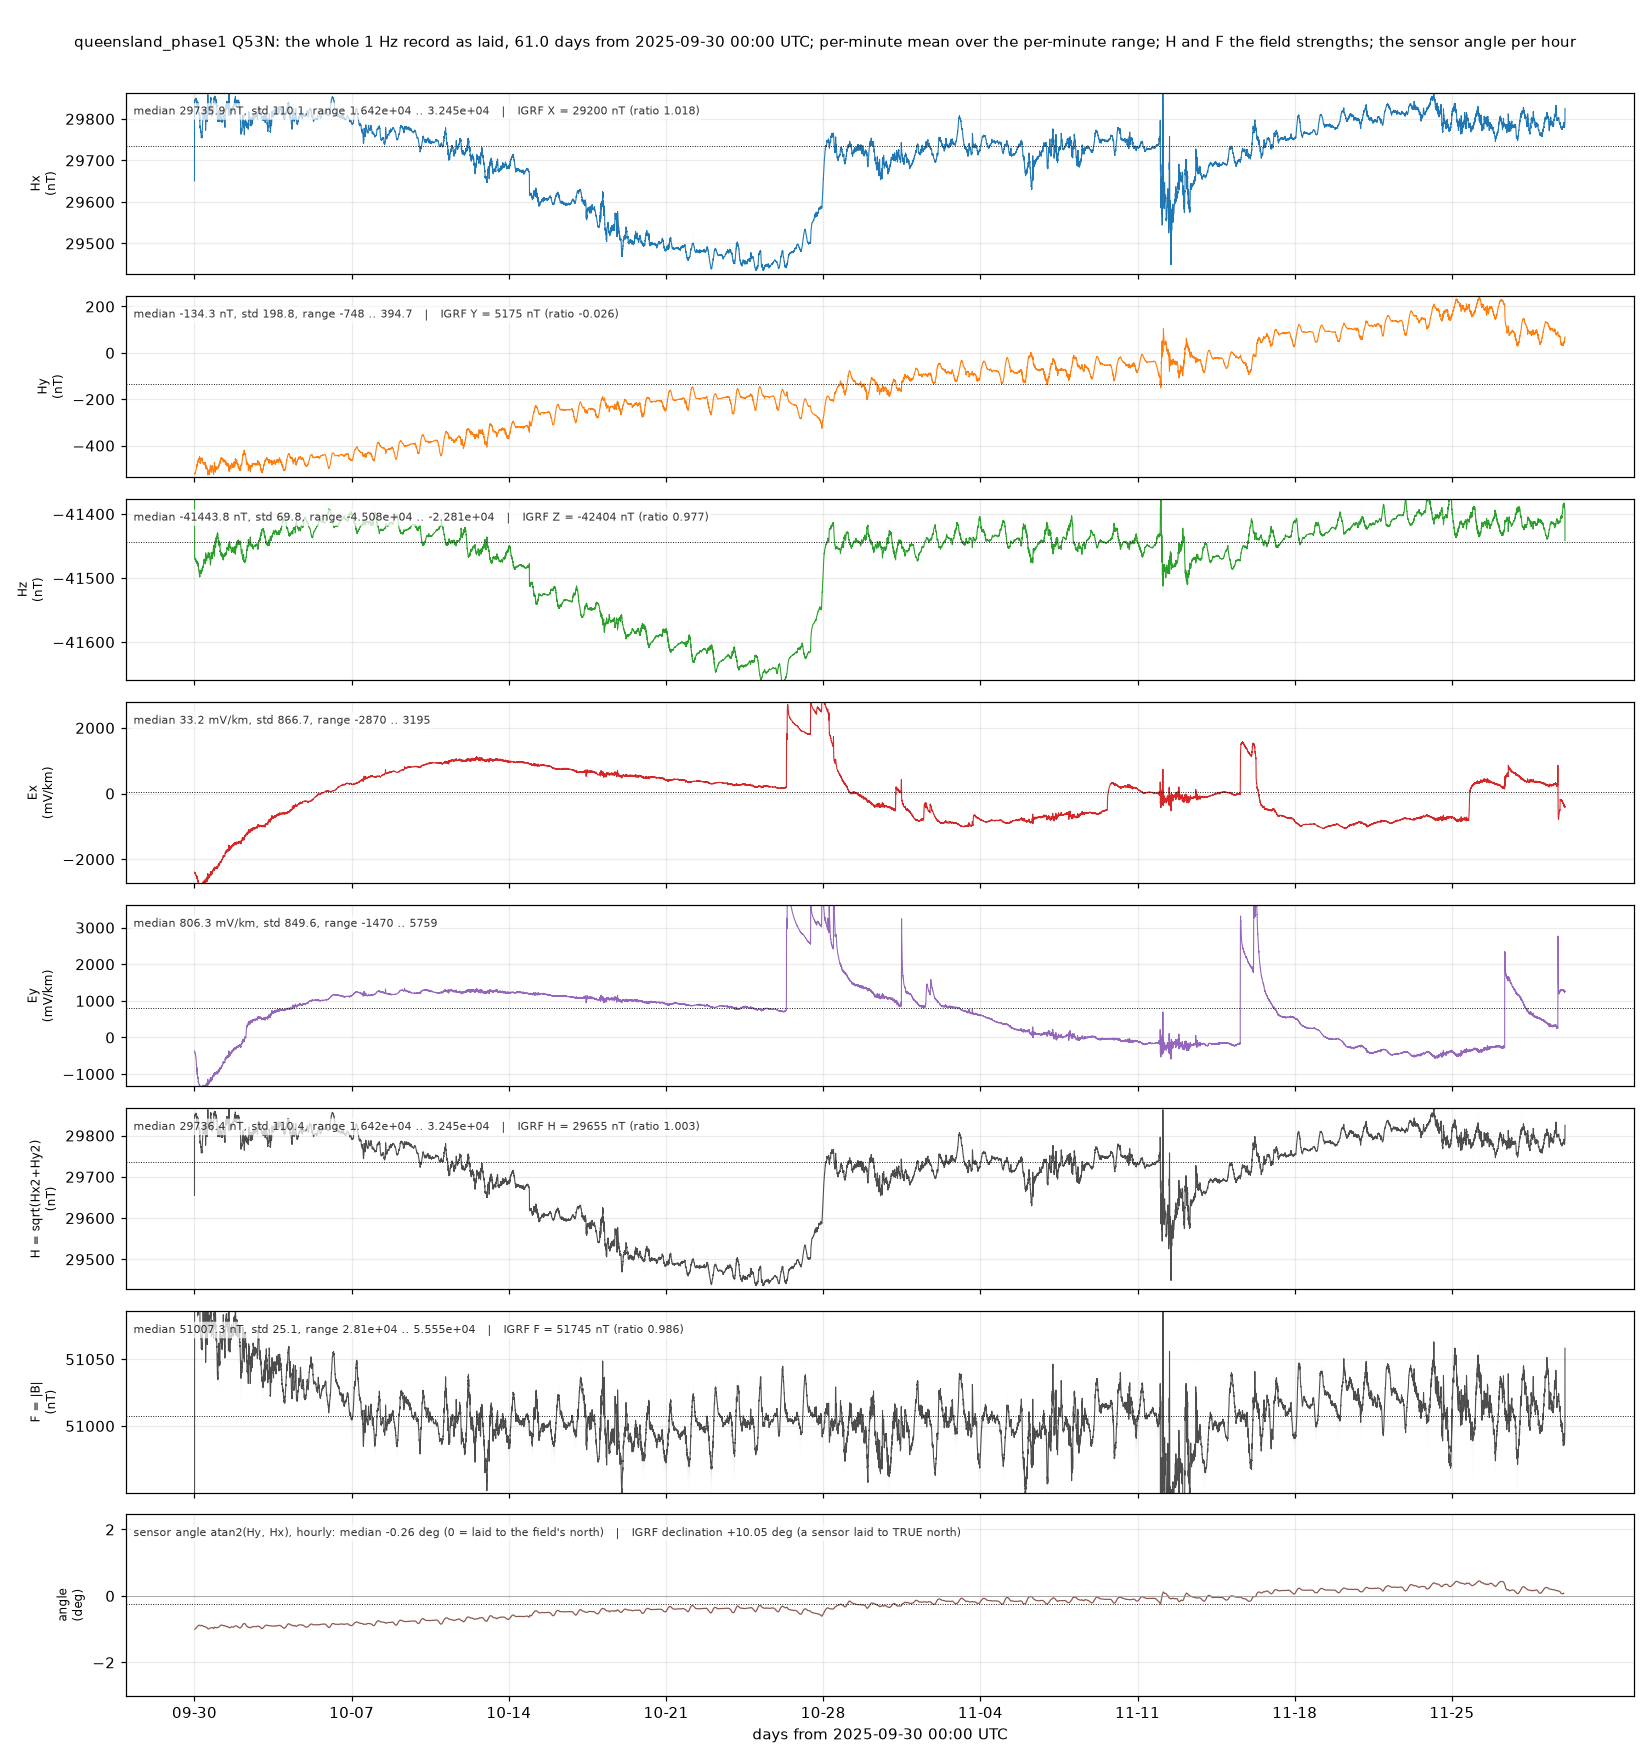

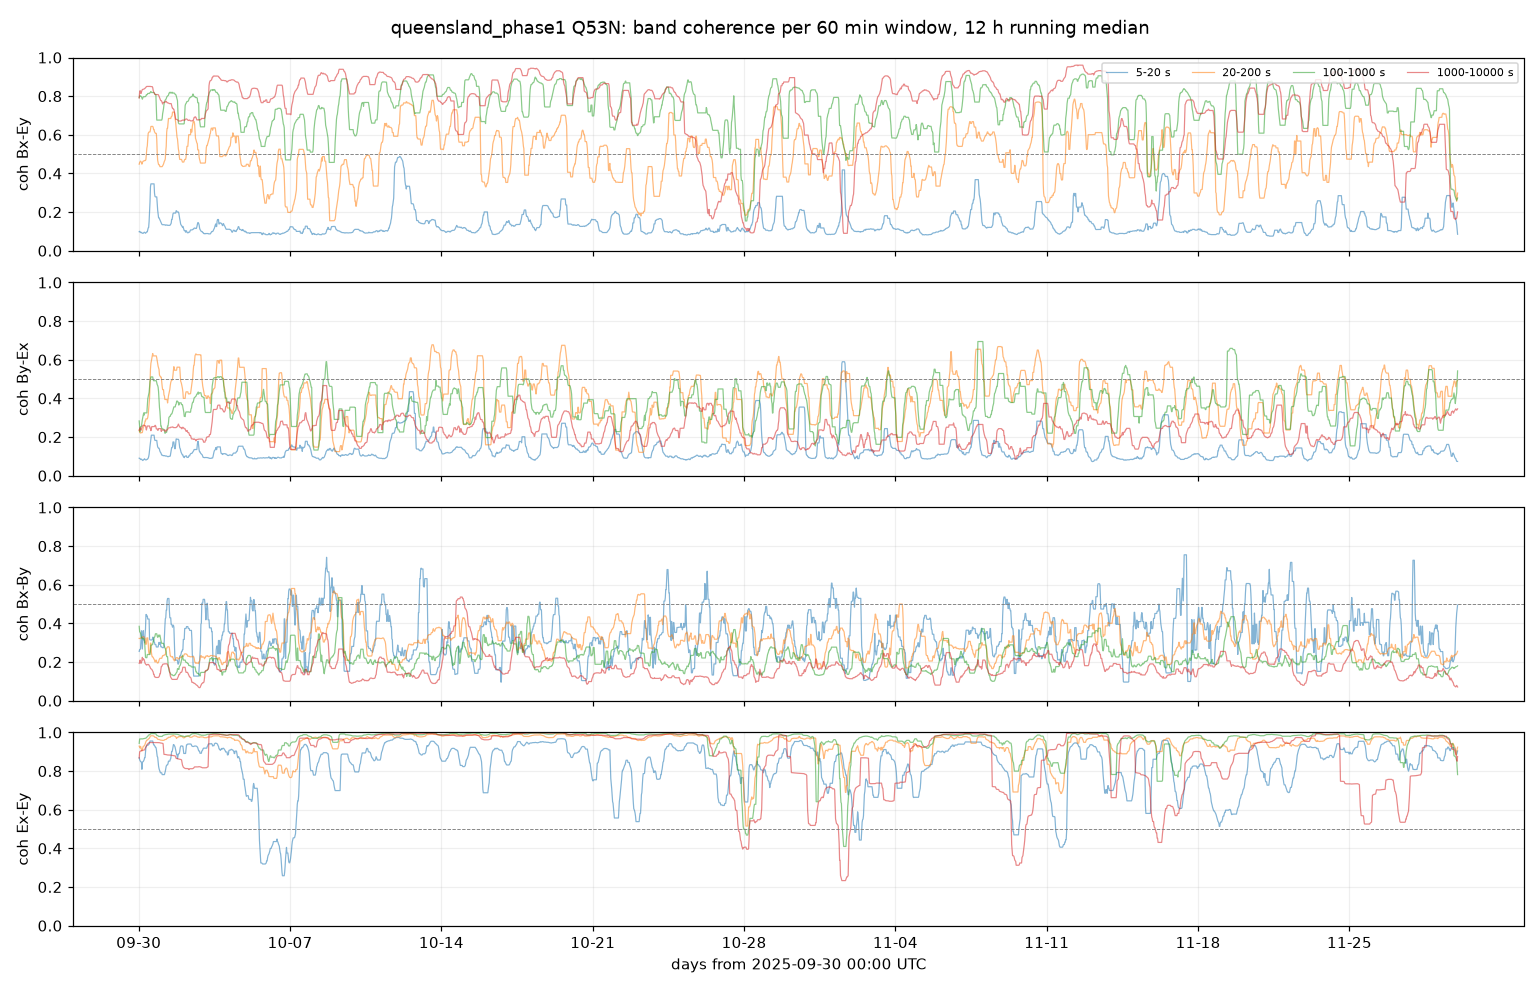

In [4]:
print("the magnetometer against IGRF (workbook 02)")
print(DC.to_string(index=False) if len(DC) else "no dc.csv: run workbook 02 over this site")
print()
keep_cols = ("site", "days_scored", "Ex_sound", "Ex_weak", "Ex_common", "Ex_dead",
             "Ey_sound", "Ey_weak", "Ey_common", "Ey_dead", "both_sound_days")
summary = pd.DataFrame([{k: v for k, v in LK.eline_summary(ELINES, SITE).items() if k in keep_cols}])
print("the two electric lines by day (workbook 02)")
print(summary.to_string(index=False))
print()
print("Ex-Ey coherence over the record: median %.3f, maximum %.3f over %d scored day(s)"
      % (float(np.nanmedian(ELINES.coh_Ex_Ey)), float(np.nanmax(ELINES.coh_Ex_Ey)),
         int(ELINES.coh_Ex_Ey.notna().sum())))
for name in ("01_record.png", "02_coherence_bands.png"):
    p = SITE_DIR / name
    if p.exists():
        display(Image(filename=str(p)))


### What this workbook will try, and why

The methods are keyed to the three tables above: a common-mode signature on the two lines calls for the
shared-centre test of section 6, a magnetic flag or a channel reading low against its neighbours calls for
the replacement of section 8, and a line that dies mid-record calls for the window of section 4. The
selections of sections 3 and 5 apply wherever a line is alive but noisy.

In [5]:
common = float(np.nanmedian(ELINES.coh_Ex_Ey)) if len(ELINES) else np.nan
# DC["flags"], not DC.flags: a DataFrame carries a `flags` attribute of its own and attribute access
# reaches that object rather than the column
flags = str(DC["flags"].iloc[0]) if len(DC) and "flags" in DC.columns else ""
dead = {c: int((ELINES["%s_state" % LINE[c]] == "dead").sum()) if len(ELINES) else 0 for c in COMPONENTS}
plan = [
    dict(section="2 the magnetics by day", applies=True, why="every later test rests on Hx and Hy"),
    dict(section="3 the quality map and the day masks", applies=True,
         why="where in time each line follows the field"),
    dict(section="4 windows", applies=bool(len(ELINES)),
         why="a line dead on %s of %d day(s)" % ("/".join(str(dead[c]) for c in COMPONENTS), len(ELINES))),
    dict(section="5 best hours", applies=True, why="a line alive but noisy"),
    dict(section="6 the shared centre", applies=bool(np.isfinite(common) and common >= 0.5),
         why="median Ex-Ey coherence %.2f" % common),
    dict(section="7 the 10 Hz forms", applies=10 in RATES,
         why="the short end the 1 Hz cache cannot reach"),
    dict(section="8 replacement magnetics", applies=True, why="DC flags: %s" % (flags or "none")),
]
print(pd.DataFrame(plan).to_string(index=False))


                            section  applies                                       why
             2 the magnetics by day     True       every later test rests on Hx and Hy
3 the quality map and the day masks     True where in time each line follows the field
                          4 windows     True           a line dead on 0/0 of 61 day(s)
                       5 best hours     True                    a line alive but noisy
                6 the shared centre     True               median Ex-Ey coherence 0.96
                  7 the 10 Hz forms     True the short end the 1 Hz cache cannot reach
            8 replacement magnetics     True                             DC flags: nan


## 2. The magnetics by day

Three tests, each with its control.

The daily test reads each UTC day's total field against IGRF and the fluctuation of Hx and Hz -- the standard
deviation after a 3,000 s high-pass -- against the median of the K_NEAREST sites recording that day. A day is
sound where the field is within 5 per cent of IGRF and both fluctuations sit within a factor 3 of the
neighbours'. Without a neighbour that day only the field is judged and the row says so.

The fleet test takes one stretch and scores the 100-1000 s Hx-Hx and Hy-Hy coherence of every pair of the
site and the sites covering it. Its positive limb reads the site's median against the sites within
FLEET_NEAR_KM against the control pairs at the same distances: a site coherent with the fleet the way its
neighbours are with each other is a site whose magnetics can be used. A site incoherent with every other
site -- a median Hx coherence under 0.3 -- is named and dropped from the control, because a dead sensor or a
clock hours out is not a control.

Its negative limb is a shifted pair: the same stretch and the same estimator on the site's Hx against each
neighbour's Hx taken 12 h later (and Hy likewise), the median over the pairs, which must read under 0.3. A
coherent pair and a shifted one differ by the whole of what the test measures, and the shifted pair exists at
every site; a stretch of junk magnetics, the control the method was first written with, does not exist at a
sound site (NEG_STRETCH accepts one where there is).

The clock test reads the lag of the peak cross-correlation of the despiked Hx against a reference site over a
+-12 h search, the peak refined to a fraction of a sample with a parabola through its two neighbours. The
series correlated is the 5-20 s band-passed record, not the 3,000 s high-passed one the coherence tests use:
a high-pass leaves the daily variation in, and a half-day sinusoid correlated against a neighbour peaks at the
edge of a +-12 h search as readily as at zero (at Q17 that gave a lag of hours where the clock is right to
0.4 s). The search stays at +-12 h so an hour-scale offset is still found.

A day is counted only where the field test holds and three guards pass: the peak correlation reaches 0.5, the
peak stands at least 1.5 times the median correlation over that day's other lags, and the peak is not within
5 per cent of the search edge. Fewer than 5 counted days leaves the clock UNJUDGED and no median is reported.

**This check fails if the shifted-pair control reads a 100-1000 s coherence of 0.3 or more on either
horizontal channel or could not be scored, if the site's own median falls below 0.8 of the control pairs' on
either channel, if fewer than 5 days could be timed, or if the clock lag's median exceeds 10 s.**

In [6]:
dm = MK.daily_magnetics_test(sv, SITE, K_NEAREST, SITES)
print("neighbours: %s" % ", ".join(dm.attrs.get("neighbours", [])) or "none overlapping")
print(dm.round(3).to_string(index=False))
judged = dm[dm.judged]
print()
print("%d of %d day(s) sound, %d judged against a neighbour"
      % (int(dm.sound.sum()), len(dm), int(dm.judged.sum())))


neighbours: Q52N (89 km), Q64N (110 km)
       day  F_ratio  hx_std   hz_std  n_neighbours  nb_F_ratio  nb_hx_std  nb_hz_std  sound  judged                                      reason
2025-09-30    0.987 726.171 1009.049             2       0.994      3.540      1.568  False    True Hx 726.2 against 3.5, Hz 1009.0 against 1.6
2025-10-01    0.987   2.531    1.141             2       0.994      2.727      1.611   True    True                                            
2025-10-02    0.987   2.320    1.007             2       0.994      2.472      1.466   True    True                                            
2025-10-03    0.986   1.826    0.712             2       0.994     22.733     39.327  False    True    Hx 1.8 against 22.7, Hz 0.7 against 39.3
2025-10-04    0.986   1.582    0.621             2       0.994      1.714      0.980   True    True                                            
2025-10-05    0.986   0.568    0.293             2       0.994      1.504      1.098  False    T

The daily test as three strips, one row per day: the field against IGRF with its 5 per cent
band, and the Hx and Hz fluctuation ratios against the neighbours' median with the factor-3 band. A day
outside any band is red; a day with no neighbour is grey and judged on the field alone. What to look for is
a run of red days at one end of the record -- the transit hours, or a sensor that moved -- rather than red
days scattered through it, which is a neighbour problem and not the site's.

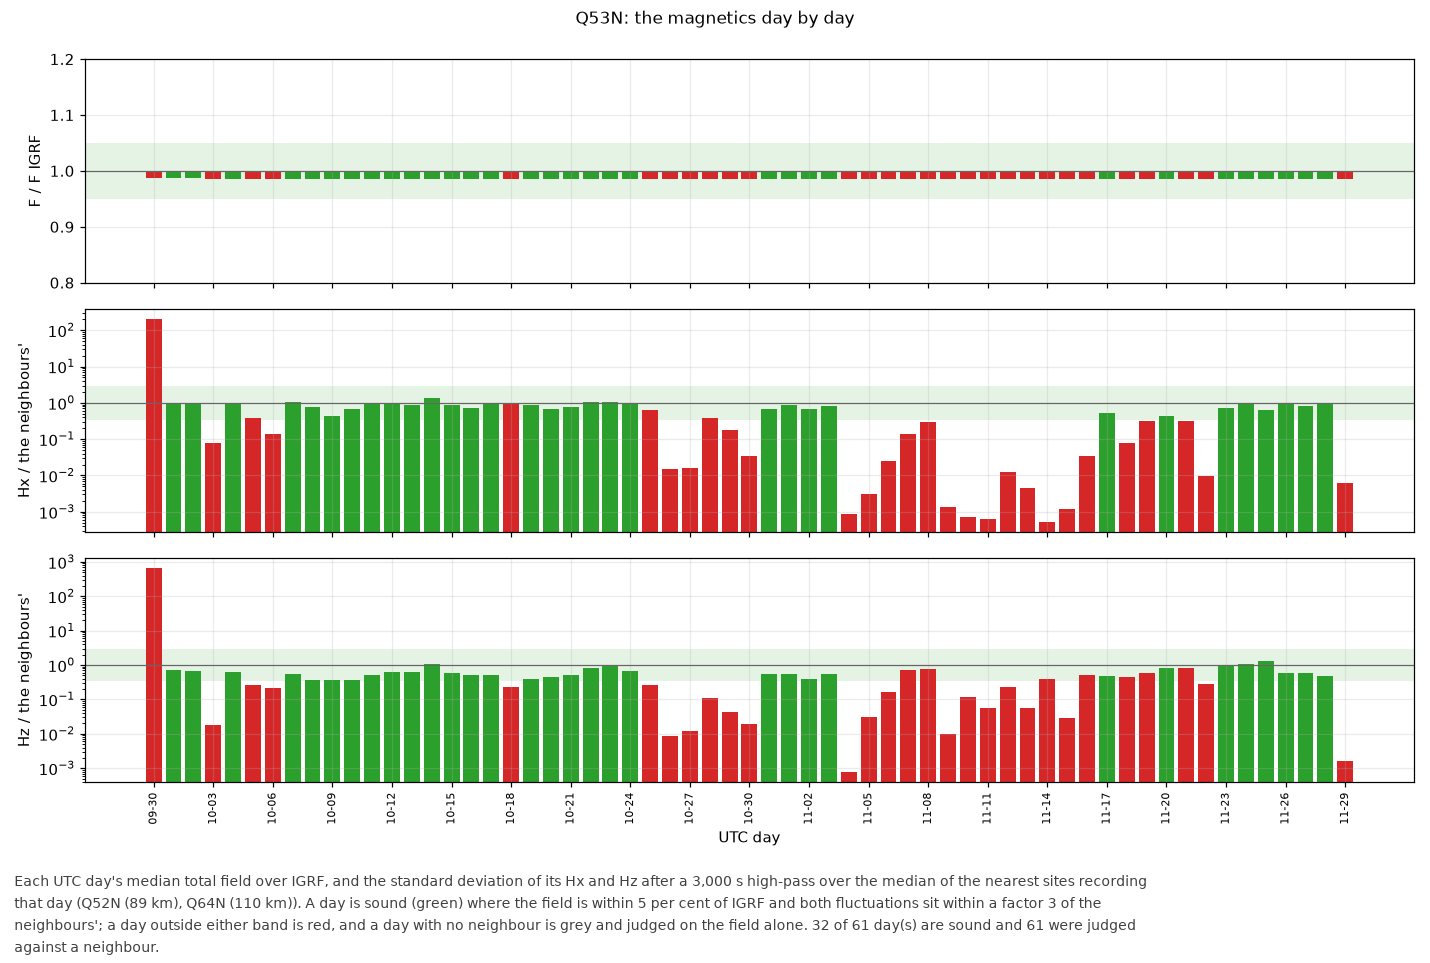

In [7]:
fig = FF.daily_magnetics(dm, SITE, OUT / "06_daily_magnetics.png",
                        neighbours=dm.attrs.get("neighbours", []))
WRITTEN.append(OUT / "06_daily_magnetics.png")
display(Image(filename=str(OUT / "06_daily_magnetics.png")))


In [8]:
# the stretch the fleet test reads: the first two sound days. NEG_STRETCH stays available for a stretch
# of junk magnetics, and the shifted pair is the control the criterion is written on
t0_rec, n_rec = MK.span(sv, SITE, 1)
day_start = {r.day: int(pd.Timestamp(r.day, tz="UTC").timestamp()) for r in dm.itertuples()}
sound = [r.day for r in dm.itertuples() if r.sound and r.judged]
# the sound day nearest the middle of the record, not the first: the first sound day sits beside the transit
# hours, and the shifted control needs the neighbours' records to reach 12 h either side of the stretch
MIDDLE = sound[len(sound) // 2] if sound else None
FLEET_STRETCH = ((day_start[MIDDLE], day_start[MIDDLE] + 2 * 86400) if MIDDLE
                 else (t0_rec + 86400, t0_rec + 3 * 86400))
print("fleet stretch  %s .. %s" % (pd.Timestamp(FLEET_STRETCH[0], unit="s"),
                                   pd.Timestamp(FLEET_STRETCH[1], unit="s")))
print("shifted control: the same stretch of each neighbour taken %g h later" % (MK.SHIFT_CONTROL_S / 3600))
NEG = (tuple(int(pd.Timestamp(x, tz="UTC").timestamp()) for x in NEG_STRETCH) if NEG_STRETCH else None)
print("NEG_STRETCH    %s" % (NEG_STRETCH or "none: no stretch of junk magnetics was named"))
ft = MK.fleet_test(sv, SITE, FLEET_STRETCH[0], FLEET_STRETCH[1], negative=NEG,
                   near_km=FLEET_NEAR_KM, sites=SITES)
print(ft["table"].round(3).to_string(index=False) if len(ft["table"]) else "no pair scored")
print()
print("%s: Hx %.2f Hy %.2f over %d pair(s) | control pairs Hx %.2f Hy %.2f over %d pair(s)%s"
      % (SITE, ft["site_hx"], ft["site_hy"], ft["n_pairs_site"], ft["control_hx"], ft["control_hy"],
         ft["n_pairs_control"],
         ("; dropped from the control as incoherent with the fleet: " + " ".join(ft["junk"]))
         if ft["junk"] else ""))
if len(ft.get("shifted_table", [])):
    print()
    print("the shifted pair, %g h, one row per neighbour" % (MK.SHIFT_CONTROL_S / 3600))
    print(ft["shifted_table"].round(3).to_string(index=False))
print("shifted control: Hx %.2f Hy %.2f over %d pair(s), and it must read under %.1f"
      % (ft["shifted_hx"], ft["shifted_hy"], ft["n_shifted"], MK.NEGATIVE_MAX))
if NEG_STRETCH:
    print("NEG_STRETCH:     Hx %.2f Hy %.2f (a reading beside the shifted control)"
          % (ft["negative_hx"], ft["negative_hy"]))


fleet stretch  2025-10-21 00:00:00 .. 2025-10-23 00:00:00
shifted control: the same stretch of each neighbour taken 12 h later
NEG_STRETCH    none: no stretch of junk magnetics was named


     a      b      km    Hx    Hy
  Q53N   Q52N  88.836 0.961 0.869
  Q64N    Q63  89.446 0.891 0.954
Q76ALT    Q75  97.371 0.005 0.316
  Q64N    Q65  98.677 0.027 0.117
  Q64N Q76ALT 102.643 0.912 0.967
   Q51   Q62N 106.536 0.648 0.701
  Q52N    Q51 107.027 0.696 0.661
  Q52N    Q63 109.520 0.962 0.900
  Q53N   Q64N 110.241 0.879 0.914
   Q63    Q75 115.427 0.005 0.311
   Q63   Q62N 121.397 0.901 0.958
   Q63 Q76ALT 136.641 0.978 0.986
  Q53N    Q63 138.057 0.938 0.929
   Q65 Q76ALT 143.240 0.032 0.125
  Q52N   Q64N 144.846 0.909 0.901
  Q64N    Q75 149.872 0.006 0.319
  Q53N    Q65 150.571 0.033 0.104
   Q63    Q51 152.058 0.680 0.702
  Q62N    Q75 160.220 0.005 0.308
  Q52N   Q62N 161.846 0.888 0.909
   Q63    Q65 188.114 0.037 0.076
  Q53N    Q51 195.786 0.679 0.683
  Q64N   Q62N 210.819 0.840 0.957
  Q53N Q76ALT 212.823 0.959 0.940
  Q52N    Q65 221.429 0.030 0.140
  Q52N    Q75 224.635 0.006 0.283
  Q64N    Q51 226.307 0.609 0.703
   Q65    Q75 227.032 0.006 0.039
  Q52N Q76ALT 

One bar per pair of the fleet table, the site's own pairs first and the control pairs behind,
with the shifted pair of each neighbour drawn beside it. What to look for is the shifted bars sitting on the
floor while the unshifted ones stand: that gap is what the test measures, and a site whose own bars
sit down with the shifted ones is not measuring the field the fleet measures.

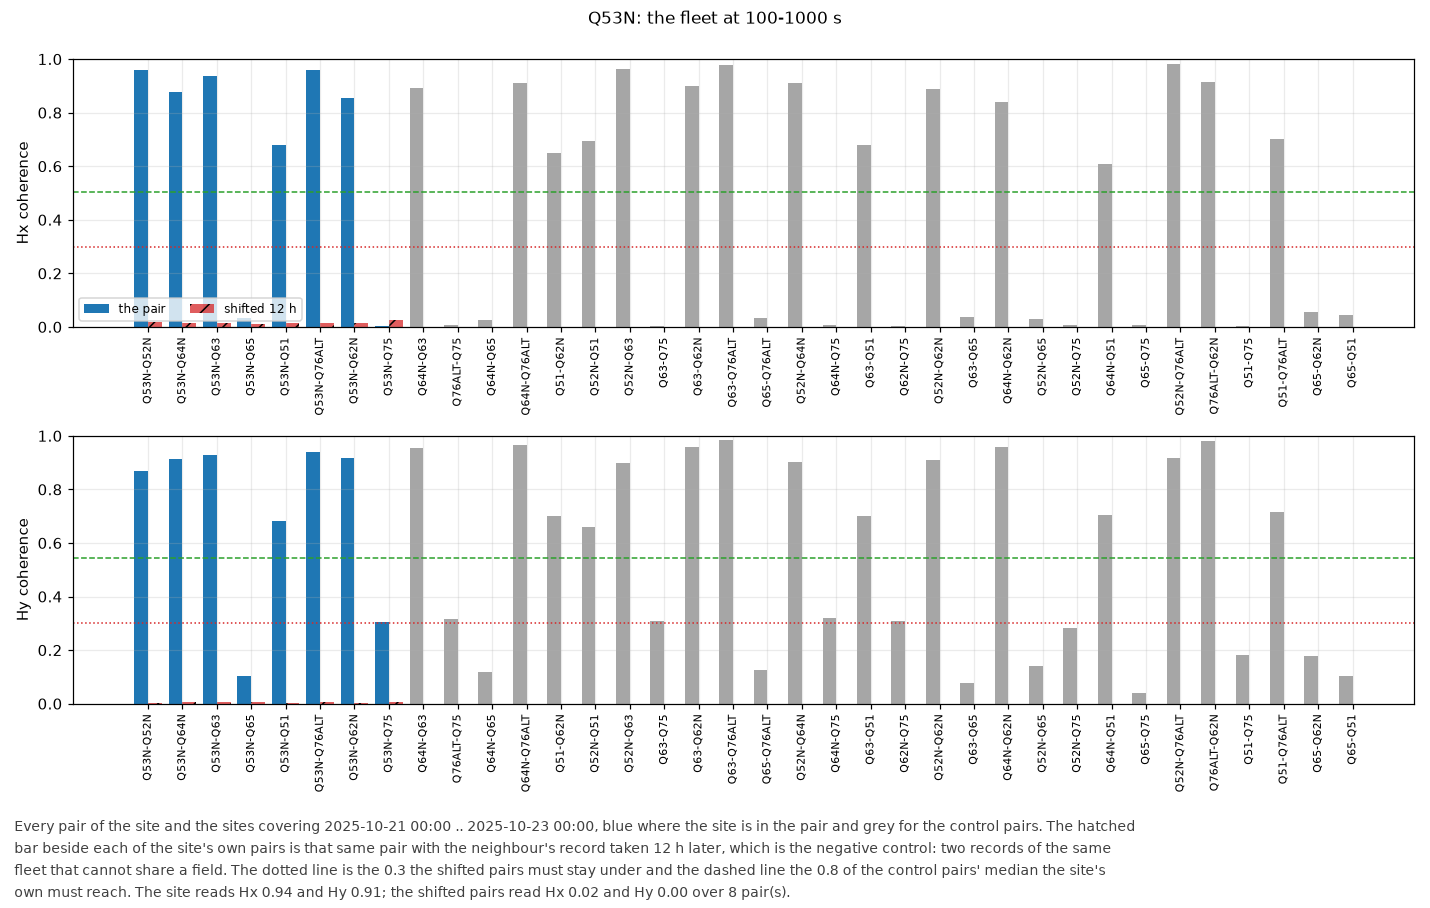

In [9]:
fig = FF.fleet_bars(ft, SITE, OUT / "07_fleet.png", near_km=FLEET_NEAR_KM,
                    floor=MK.NEGATIVE_MAX)
WRITTEN.append(OUT / "07_fleet.png")
display(Image(filename=str(OUT / "07_fleet.png")))


the clock against Q52N (89 km) on the 5-20 s band, searched to +-12 h
       day    lag_s  peak_r  peak_over_floor  r_at_zero  edge  F_ratio  counted                                                     reason
2025-10-01     0.07   0.844           118.38      0.844 False    0.987     True                                                           
2025-10-02     0.01   0.647            82.13      0.647 False    0.987     True                                                           
2025-10-03    -0.03   0.480            73.30      0.480 False    0.986    False                                             peak under 0.5
2025-10-04    -0.01   0.415            53.64      0.415 False    0.986    False                                             peak under 0.5
2025-10-05     0.21   0.073             8.93      0.073 False    0.986    False                                             peak under 0.5
2025-10-06 30089.43   0.051             6.74      0.032 False    0.986    False                 

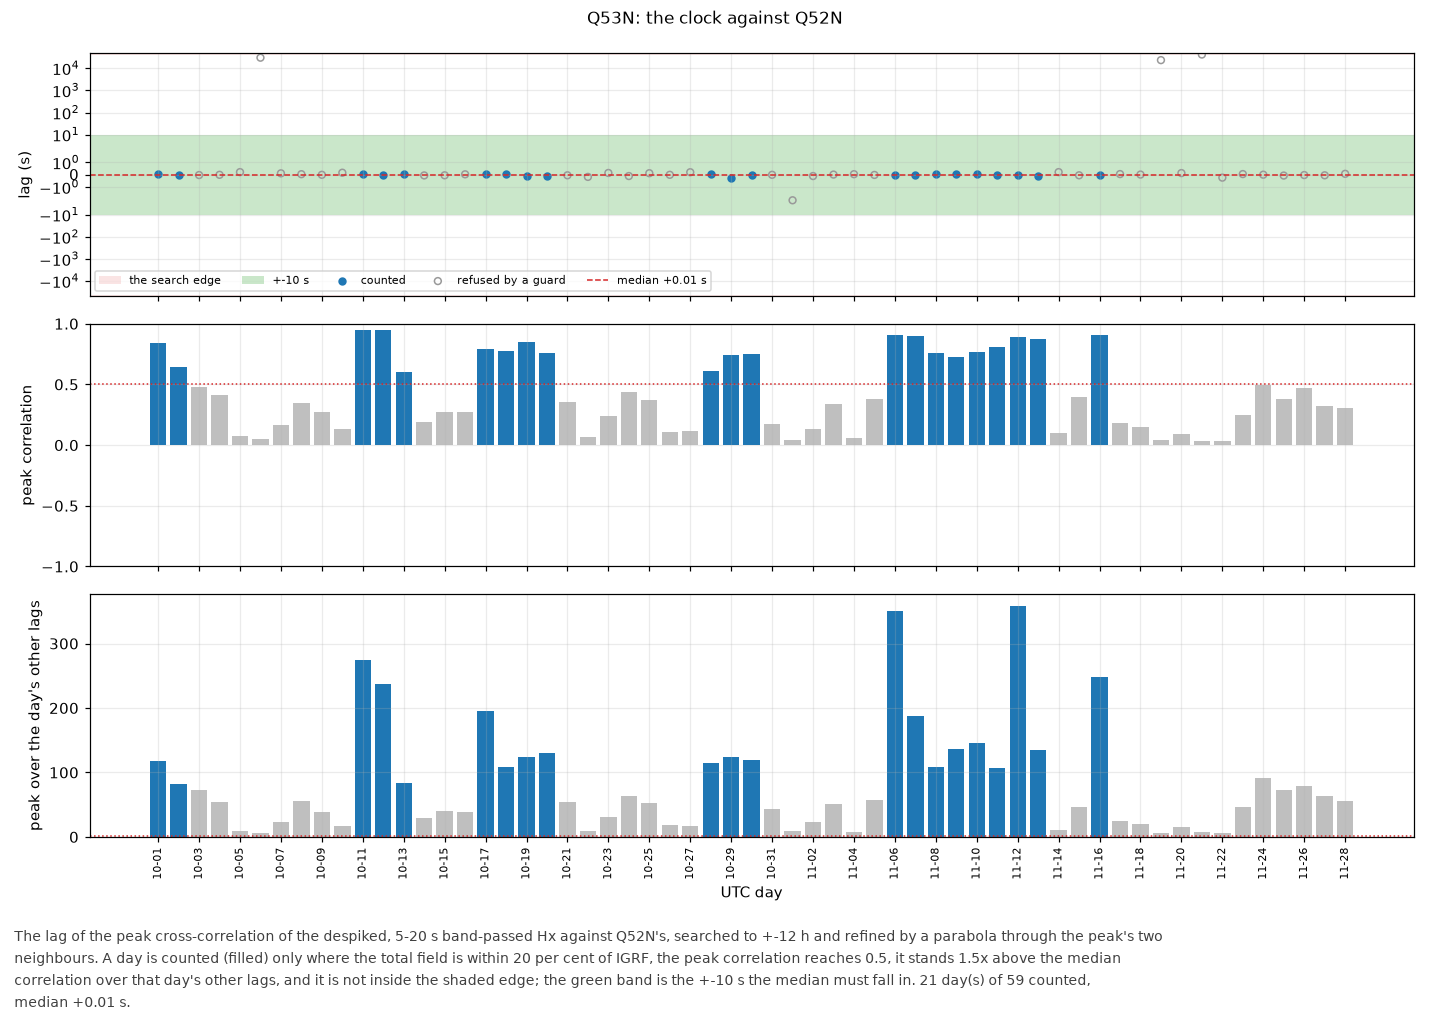

In [10]:
ck = MK.clock_test(sv, SITE, sites=SITES)
print("the clock against %s (%.0f km) on the %g-%g s band, searched to +-%g h"
      % (ck["ref"], ck.get("km", np.nan), MK.CLOCK_BAND_S[0], MK.CLOCK_BAND_S[1],
         MK.CLOCK_MAXLAG_S / 3600))
if len(ck["table"]):
    print(ck["table"].round(3).to_string(index=False))
print("%d day(s) counted of %d; %s"
      % (ck["n_days"], len(ck["table"]),
         ("median lag %+.2f s" % ck["median_lag_s"]) if ck["judged"]
         else "UNJUDGED, and no median is reported: %s" % ck["reason"]))
fig = FF.clock_lags(ck, SITE, OUT / "08_clock.png", pass_s=MK.CLOCK_PASS_S,
                    edge_fraction=MK.CLOCK_EDGE_FRACTION, peak_ratio=MK.CLOCK_PEAK_RATIO,
                    maxlag_s=MK.CLOCK_MAXLAG_S)
WRITTEN.append(OUT / "08_clock.png")
display(Image(filename=str(OUT / "08_clock.png")))


In [11]:
fail = []
if not ft.get("shifted_judged"):
    fail.append("the shifted-pair control was not scored (no neighbour's record reaches %g h either side of "
                "the stretch), so the fleet test was not shown able to fail" % (MK.SHIFT_CONTROL_S / 3600))
elif max(ft["shifted_hx"], ft["shifted_hy"]) >= MK.NEGATIVE_MAX:
    fail.append("the shifted-pair control reads Hx %.2f Hy %.2f over %d pair(s), at or above %.1f"
                % (ft["shifted_hx"], ft["shifted_hy"], ft["n_shifted"], MK.NEGATIVE_MAX))
if not ft.get("positive_ok"):
    fail.append("the site reads Hx %.2f Hy %.2f against the control pairs' %.2f and %.2f, below %.1f of them"
                % (ft["site_hx"], ft["site_hy"], ft["control_hx"], ft["control_hy"],
                   MK.FLEET_CONTROL_FRACTION))
if not ck["judged"]:
    fail.append("UNJUDGED on the clock against %s: %s" % (ck["ref"], ck["reason"]))
elif abs(ck["median_lag_s"]) > MK.CLOCK_PASS_S:
    fail.append("the clock lag's median is %+.2f s over %d day(s), beyond %.0f s"
                % (ck["median_lag_s"], ck["n_days"], MK.CLOCK_PASS_S))
if fail:
    print("VERDICT: FAIL -- %s; for the record the shifted-pair control reads Hx %.2f Hy %.2f over %d "
          "pair(s) and the clock counted %d day(s) of %d on the %g-%g s band"
          % ("; ".join(fail), ft["shifted_hx"], ft["shifted_hy"], ft["n_shifted"], ck["n_days"],
             len(ck["table"]), MK.CLOCK_BAND_S[0], MK.CLOCK_BAND_S[1]))
else:
    print("VERDICT: PASS -- the shifted-pair control reads Hx %.2f Hy %.2f over %d pair(s), both under "
          "%.1f, where the same pairs unshifted read Hx %.2f Hy %.2f; over the sound stretch the site reads "
          "Hx %.2f Hy %.2f against the control pairs' %.2f and %.2f, above %.1f of them; the clock lag's "
          "median is %+.2f s over %d counted day(s) on the 5-20 s band, within %.0f s%s"
          % (ft["shifted_hx"], ft["shifted_hy"], ft["n_shifted"], MK.NEGATIVE_MAX, ft["site_hx"],
             ft["site_hy"], ft["site_hx"], ft["site_hy"], ft["control_hx"], ft["control_hy"],
             MK.FLEET_CONTROL_FRACTION, ck["median_lag_s"], ck["n_days"], MK.CLOCK_PASS_S,
             ("; NEG_STRETCH reads Hx %.2f Hy %.2f as a reading beside it"
              % (ft["negative_hx"], ft["negative_hy"])) if NEG_STRETCH else ""))


VERDICT: PASS -- the shifted-pair control reads Hx 0.02 Hy 0.00 over 8 pair(s), both under 0.3, where the same pairs unshifted read Hx 0.94 Hy 0.91; over the sound stretch the site reads Hx 0.94 Hy 0.91 against the control pairs' 0.91 and 0.93, above 0.8 of them; the clock lag's median is +0.01 s over 21 counted day(s) on the 5-20 s band, within 10 s


## 3. The quality map and the day masks

The quality map is where in time each electric line follows the magnetic field. Three scales, each with the
statistic the scale can carry: the hourly 4-50 s coherence of each line with the H it couples to, the daily
50-1000 s multiple coherence of each line with the local pair and with the observatory pair, and one
1000-10000 s number on the whole record decimated to 0.1 Hz. The multiple coherence is bias-corrected --
g2c = (g2 - p/nu) / (1 - p/nu) with p = 2 predictors and nu = 0.82 times the number of segments -- because an
estimate from few segments saturates at 1 or sits on the bias floor, which is what an uncorrected hourly
estimate over 50-1000 s reads at every site.

What the number is, and what it is not. It is the fraction of the electric line's power the magnetic field
explains, so it measures local electric noise. A low value does not mean the component cannot be measured: a
remote reference beats the noise the target and the reference do not share, which is why the sites with a
noisy shared centre sit at the bottom of this table and still deliver products. Nor does a high value mean
the row is right: a site whose second line repeats the first has the highest coherence in a survey and an
unusable yx row, which is a geometry fault that coherence with the magnetic field cannot see.

The day mask keeps the whole days whose observatory multiple coherence reaches DAY_THR; those columns carry
no local magnetic noise, which is why the mask is taken on them. Its control keeps the same number of days
drawn without replacement from the same pool of scored days under the seed printed below.

**This check fails if any mask lacks its control, if a control differs in size from its selection, if a mask
keeps too few days to be scored at all, or if a promoted mask does not beat its control on the 10-1000 s bar
by at least 20 per cent.** A mask that does not beat its control is not promoted and is printed as such;
that is a finding about the record, not a failure of the check. The check is on whether every selection has a
control of the right size, whether anything was scored at all, and whether the promotions agree with the bar
they are made on.

the quality map in 33 s: 1464 hour(s), 61 day(s), observatory CTA
site  hours  days observatory  Ex_hourly_med  Ex_hourly_over_0p5  Ey_hourly_med  Ey_hourly_over_0p5  Ex_local_med  Ex_local_days_over_0p5  Ey_local_med  Ey_local_days_over_0p5  Ex_obs_med  Ex_obs_days_over_0p5  Ey_obs_med  Ey_obs_days_over_0p5  Ex_vlong  Ey_vlong
Q53N   1464    61         CTA          0.145               0.068          0.126               0.111         0.911                   0.885         0.891                   0.852       0.893                 0.885       0.895                 0.852     0.328     0.074


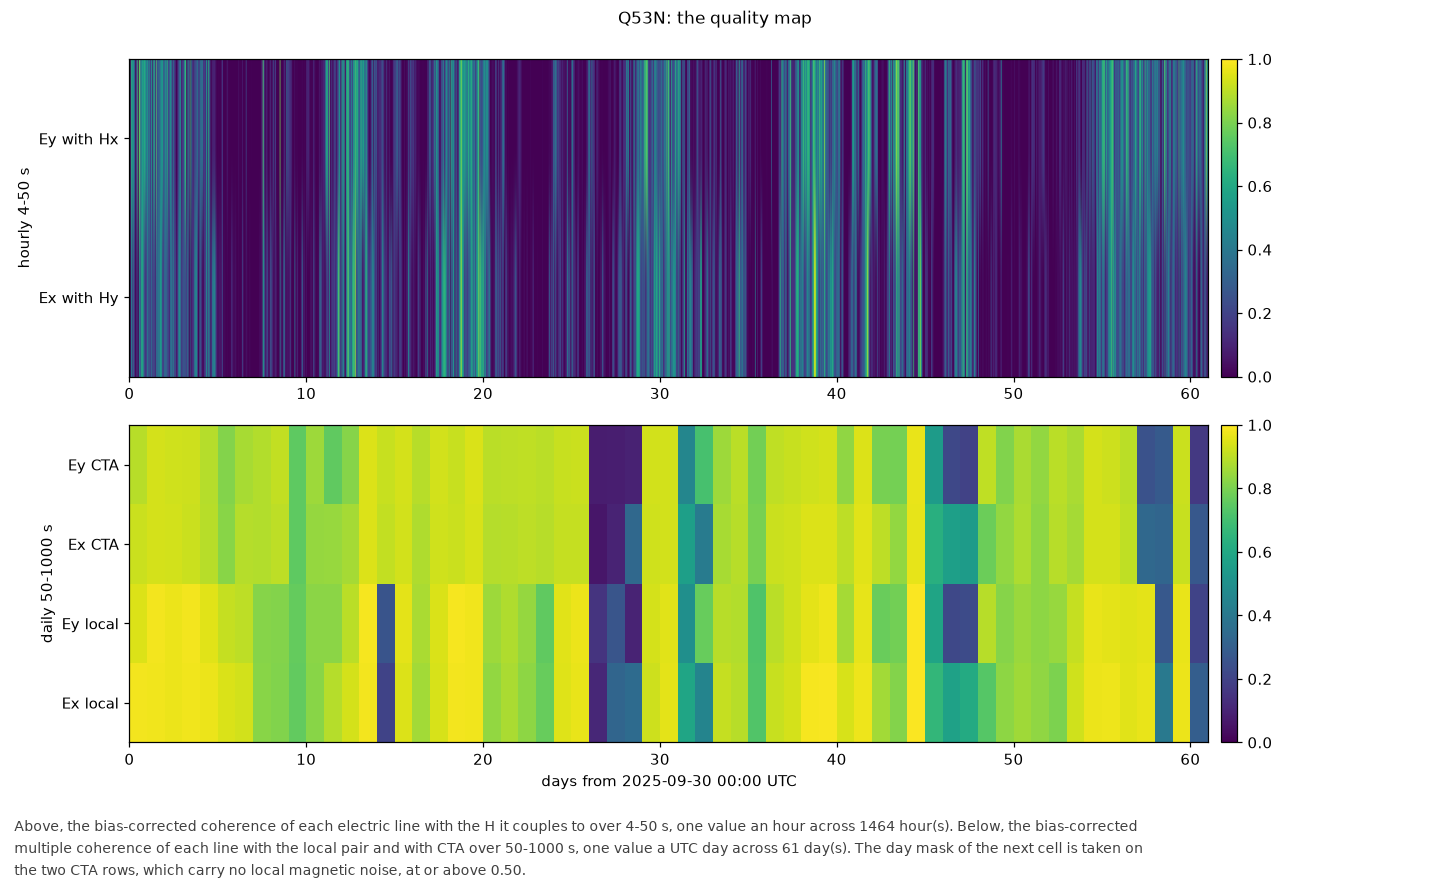

In [12]:
t = time.time()
QM = MK.quality_map(sv, SITE)
print("the quality map in %.0f s: %d hour(s), %d day(s), observatory %s"
      % (time.time() - t, QM["hours"], QM["n_days"], QM["observatory"]))
print(pd.DataFrame([MK.quality_row(QM)]).round(3).to_string(index=False))
fig = FF.quality_images(QM, SITE, OUT / "09_quality_map.png", thr=DAY_THR)
WRITTEN.append(OUT / "09_quality_map.png")
display(Image(filename=str(OUT / "09_quality_map.png")))


In [13]:
DAY_MASKS, rows = {}, []
for comp in COMPONENTS:
    keep, ctrl, info = MK.day_mask(QM, comp, DAY_THR, SEED)
    DAY_MASKS[comp] = (keep, ctrl, info)
    rows.append({k: v for k, v in info.items() if k not in ("kept_days", "control_days")})
print("the day mask per component, on the %s columns, threshold %.2f, seed %d"
      % (QM["observatory"], DAY_THR, SEED))
print(pd.DataFrame(rows).round(3).to_string(index=False))
for comp in COMPONENTS:
    print("   %s kept    %s" % (comp, DAY_MASKS[comp][2]["kept_days"][:110]))
    print("   %s control %s" % (comp, DAY_MASKS[comp][2]["control_days"][:110]))


the day mask per component, on the CTA columns, threshold 0.50, seed 20260916
component      column  threshold     seed  days_scored  days_total  days_kept  days_control  median_kept  median_dropped                                            pool  enough
       xy observatory        0.5 20260916           61          61         54            54        0.899           0.328 the days the map scored, the selection included    True
       yx observatory        0.5 20260916           61          61         52            52        0.900           0.196 the days the map scored, the selection included    True
   xy kept    2025-09-30 2025-10-01 2025-10-02 2025-10-03 2025-10-04 2025-10-05 2025-10-06 2025-10-07 2025-10-08 2025-10-09 
   xy control 2025-09-30 2025-10-01 2025-10-02 2025-10-03 2025-10-04 2025-10-05 2025-10-06 2025-10-07 2025-10-08 2025-10-09 
   yx kept    2025-09-30 2025-10-01 2025-10-02 2025-10-03 2025-10-04 2025-10-05 2025-10-06 2025-10-07 2025-10-08 2025-10-09 
   yx control 20

The record with the masks drawn on it: the kept days of each component as a solid span in its own
colour, the random control of the same size hatched. What to look for is whether the kept days sit together
at one end of the record -- in which case the mask is a window in disguise and the contiguous comparison of
section 5 is the one to read -- or scattered through it, and whether the control's days look any different to
the eye than the selection's.

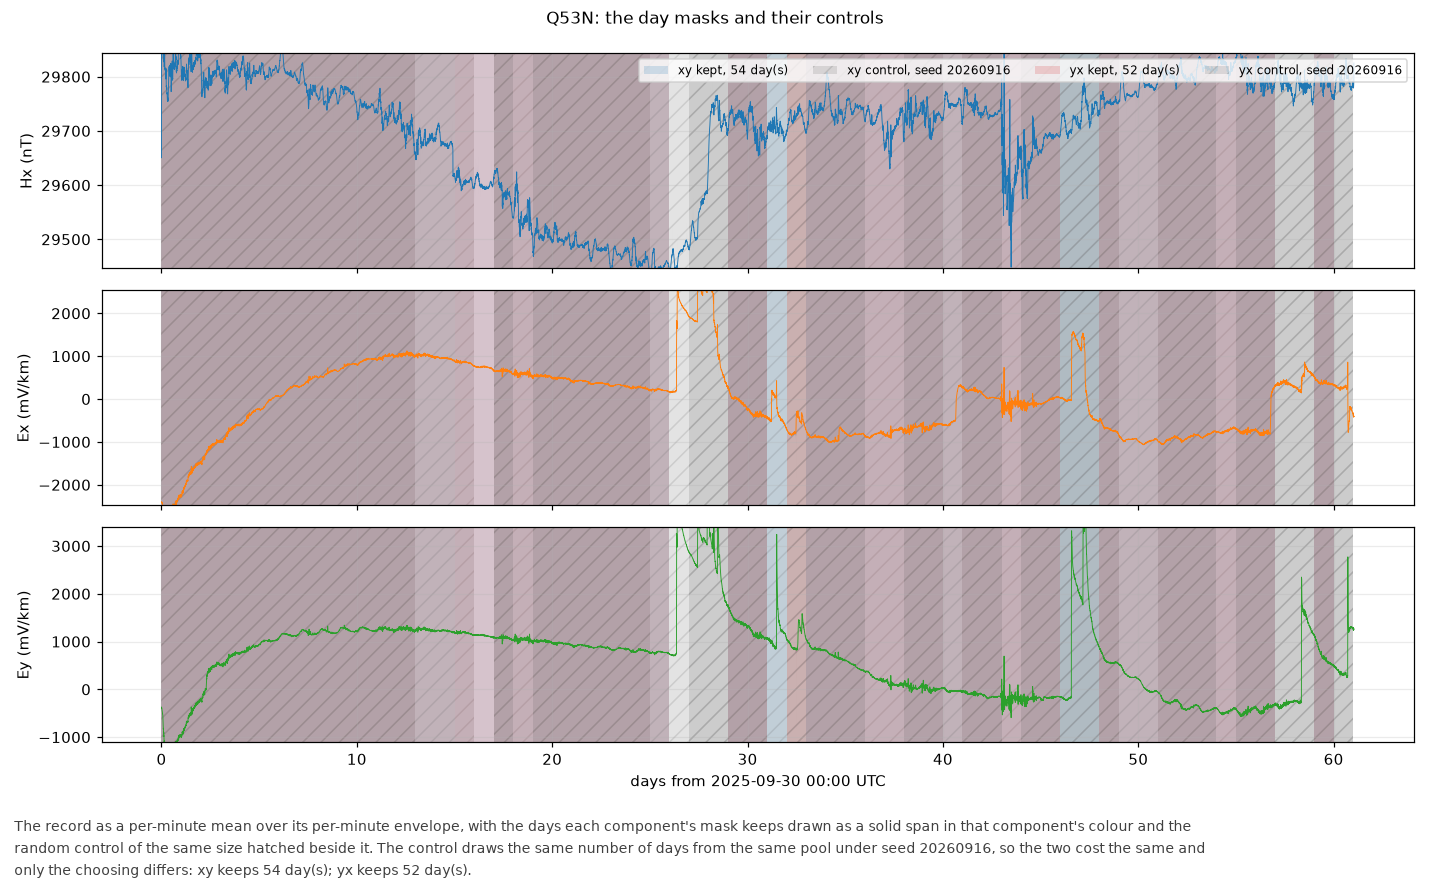

In [14]:
_t0m, _arrm, _metam = CACHE.load(SITE, WORK, 1)
spans = []
for comp in COMPONENTS:
    keep, ctrl, info = DAY_MASKS[comp]
    spans.append(("%s kept, %d day(s)" % (comp, info["days_kept"]), FF.SPAN_COLOUR[comp], None,
                  FF.mask_spans(keep, _t0m)))
    spans.append(("%s control, seed %d" % (comp, SEED), "0.4", "//", FF.mask_spans(ctrl, _t0m)))
fig = FF.record_spans(_t0m, _arrm, OUT / "10_day_masks.png", site=SITE, spans=spans,
                      title="%s: the day masks and their controls" % SITE,
                      caption="The record as a per-minute mean over its per-minute envelope, with the days "
                              "each component's mask keeps drawn as a solid span in that component's colour "
                              "and the random control of the same size hatched beside it. The control draws "
                              "the same number of days from the same pool under seed %d, so the two cost the "
                              "same and only the choosing differs: %s."
                              % (SEED, "; ".join("%s keeps %d day(s)" % (c, DAY_MASKS[c][2]["days_kept"])
                                                 for c in COMPONENTS)))
WRITTEN.append(OUT / "10_day_masks.png")
display(Image(filename=str(OUT / "10_day_masks.png")))
del _arrm


In [15]:
THIN = {}
for comp in COMPONENTS:
    keep, ctrl, info = DAY_MASKS[comp]
    if not info["enough"]:
        # a mask keeping fewer than three days starves the long bands, so no pass is run on it: the pair is
        # UNJUDGED rather than made and then read
        THIN[comp] = info["days_kept"]
        print("   %s: the mask keeps %d day(s) of the %d scored, below the %d-day floor; no product is made"
              % (comp, info["days_kept"], info["days_scored"], MK.DAY_MIN_KEPT))
        continue
    form("daymask_%s" % comp, keep_extra=keep, seed=SEED,
         keep_name="%d whole day(s) at or above %.2f on the %s multiple coherence"
                   % (info["days_kept"], DAY_THR, QM["observatory"]),
         controls=["daymask_%s_control" % comp],
         criterion="beats its random control on the %g-%g s bar by %.0f %%"
                   % (BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN))
    form("daymask_%s_control" % comp, keep_extra=ctrl, seed=SEED,
         keep_name="%d day(s) drawn at random from the same pool, seed %d" % (info["days_control"], SEED))
if not THIN:
    print("   every component's mask clears the %d-day floor" % MK.DAY_MIN_KEPT)


   every component's mask clears the 3-day floor


In [16]:
rows, bad, unjudged = [], [], []
for comp in COMPONENTS:
    info = DAY_MASKS[comp][2]
    if info["days_kept"] != info["days_control"]:
        bad.append("%s: the control keeps %d day(s) and the selection %d"
                   % (comp, info["days_control"], info["days_kept"]))
    if comp in THIN:
        unjudged.append("%s: the mask keeps %d day(s) of the %d scored, below the %d-day floor, so no "
                        "product was made and the pair is not scored"
                        % (comp, THIN[comp], info["days_scored"], MK.DAY_MIN_KEPT))
        continue
    for name in ("daymask_%s" % comp, "daymask_%s_control" % comp):
        r = made_product(name)
        if r is None:
            bad.append("%s was not made (%s)" % (name, str(rows_by_form().get(name, {}).get("error"))[:90]))
            continue
        rd = DL.reading(read(r["product"]), read(BASE) if BASE else None,
                        bands=[tuple(b) for b in DECADES], bar_band=tuple(BAR_BAND),
                        agree_band=tuple(AGREE_BAND))
        rows.append(dict(form=name, days=r.get("days"), runs=r.get("n_runs"), bar=rd.get("bar"),
                         bar_xy=rd.get("bar_xy"), bar_yx=rd.get("bar_yx"),
                         jumps_xy=rd.get("jumps_per_decade_xy"), jumps_yx=rd.get("jumps_per_decade_yx"),
                         rho_ratio_xy=rd.get("rho_ratio_xy"), rho_ratio_yx=rd.get("rho_ratio_yx")))
print(pd.DataFrame(rows).round(4).to_string(index=False) if rows else "no product to read")
beaten = []
for comp in COMPONENTS:
    a = next((r for r in rows if r["form"] == "daymask_%s" % comp), None)
    b = next((r for r in rows if r["form"] == "daymask_%s_control" % comp), None)
    if a and b:
        beaten.append((comp, DL.beats(a["bar"], b["bar"], BAR_MARGIN), a["bar"], b["bar"]))
print()
for comp, ok, x, y in beaten:
    print("   %s: bar %.4f against the control's %.4f -- %s"
          % (comp, x, y, "promoted" if ok else "NOT promoted: efficiency, not a different answer"))
promoted = [c for c, ok, _x, _y in beaten if ok]
inconsistent = [c for c, ok, x, y in beaten if ok and not DL.beats(x, y, BAR_MARGIN)]
if bad:
    print("VERDICT: FAIL -- %s" % "; ".join(bad))
elif inconsistent:
    print("VERDICT: FAIL -- %s promoted without beating its control on the %g-%g s bar by %.0f %%"
          % (", ".join(inconsistent), BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN))
elif unjudged:
    print("VERDICT: UNJUDGED -- %s%s" % ("; ".join(unjudged),
          ("; the pair(s) that were scored read " + "; ".join("%s %.4f against %.4f" % (c, x, y)
                                                              for c, ok, x, y in beaten)) if beaten else ""))
elif not beaten:
    print("VERDICT: UNJUDGED -- no mask and control pair was scored")
else:
    print("VERDICT: PASS -- every mask carries a control of the same day count drawn from the same pool "
          "under seed %d, every one of the %d pair(s) was scored on the %g-%g s bar (%s), and the %d "
          "promoted mask(s) (%s) each beat their control by at least %.0f %%"
          % (SEED, len(beaten), BAR_BAND[0], BAR_BAND[1],
             "; ".join("%s %.4f against %.4f" % (c, x, y) for c, ok, x, y in beaten),
             len(promoted), ", ".join(promoted) or "none", 100 * BAR_MARGIN))


              form   days  runs    bar  bar_xy  bar_yx  jumps_xy  jumps_yx  rho_ratio_xy  rho_ratio_yx
        daymask_xy 51.731    76 0.0010  0.0014  0.0010     1.388     0.694        1.0001        0.9989
daymask_xy_control 48.676    81 0.0010  0.0015  0.0010     1.157     0.463        0.9989        1.0017
        daymask_yx 49.738    77 0.0010  0.0014  0.0010     1.157     0.463        1.0009        0.9981
daymask_yx_control 46.912    75 0.0012  0.0016  0.0012     0.925     0.463        1.0010        0.9984

   xy: bar 0.0010 against the control's 0.0010 -- NOT promoted: efficiency, not a different answer
   yx: bar 0.0010 against the control's 0.0012 -- NOT promoted: efficiency, not a different answer
VERDICT: PASS -- every mask carries a control of the same day count drawn from the same pool under seed 20260916, every one of the 2 pair(s) was scored on the 10-1000 s bar (xy 0.0010 against 0.0010; yx 0.0010 against 0.0012), and the 0 promoted mask(s) (none) each beat their control b

The whole-record product, each mask's product and each control's product on one set of panels.
What to look for is whether the three curves lie on each other: where they do, the mask changed nothing but
the error bars, which is the reading the verdict above prints as efficiency rather than a different
answer.

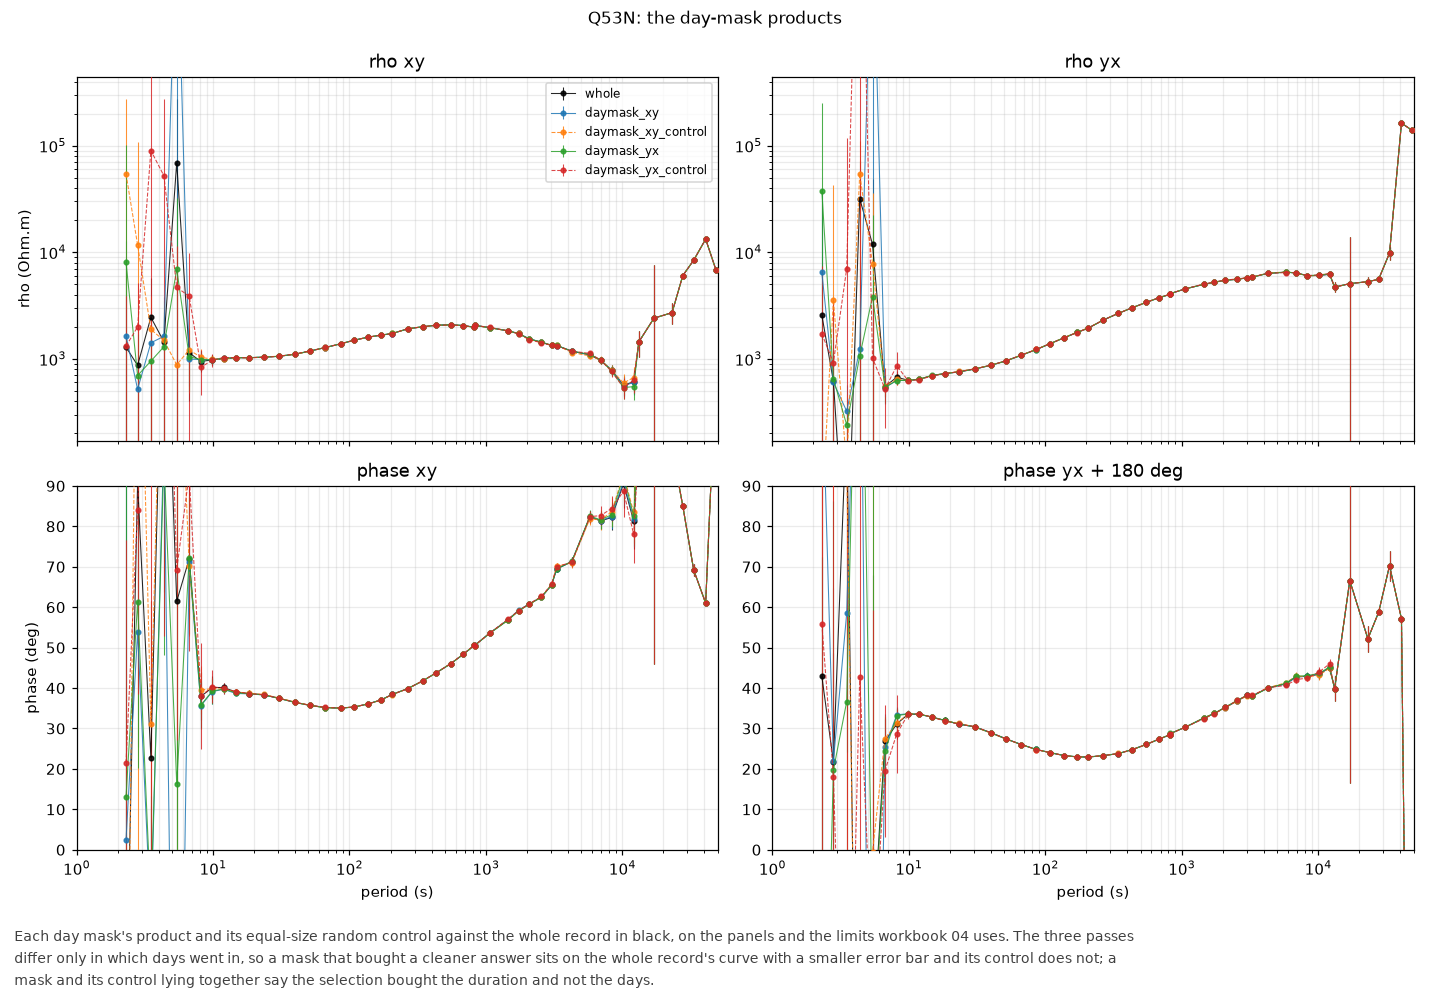

In [17]:
curves = [("whole", read(BASE), "k", "-")] if BASE else []
for k, comp in enumerate(COMPONENTS):
    for name, ls in (("daymask_%s" % comp, "-"), ("daymask_%s_control" % comp, "--")):
        r = made_product(name)
        if r:
            curves.append((name, read(r["product"]), "C%d" % (2 * k + (0 if ls == "-" else 1)), ls))
if len(curves) > 1:
    fig = FF.form_panels(curves, SITE, OUT / "11_daymask_products.png",
                         title="%s: the day-mask products" % SITE,
                         caption="Each day mask's product and its equal-size random control against the "
                                 "whole record in black, on the panels and the limits workbook 04 uses. The "
                                 "three passes differ only in which days went in, so a mask that bought a "
                                 "cleaner answer sits on the whole record's curve with a smaller error bar "
                                 "and its control does not; a mask and its control lying together say the "
                                 "selection bought the duration and not the days.",
                         period_range=(1, 50000))
    WRITTEN.append(OUT / "11_daymask_products.png")
    display(Image(filename=str(OUT / "11_daymask_products.png")))
else:
    print("no mask product was made, so there is nothing to draw against the whole record")


## 4. Windows

A line that dies mid-record is not a reason to throw the record away. The rule is the whole record for the
healthy row and for the tipper, the window for the other row, and both windows in the provenance. The window
proposed here is the longest run of sound days of that line in the elines table; where no run of sound days
reaches the floor in survey.yaml the weak days are admitted and the row says so, so the window is a proposal
and not a finding. A window already in decisions.csv is used instead.

The windowed pass slices everything to the window, H included: the point of a window is that this component's
estimate sees only the days its electrode was alive, and an estimator handed a longer H than E would be
given NaN over the rest. The merge then replaces exactly that component's two impedance rows in a copy of the
whole-record product; the station block, the position, the tipper and every other row carry across untouched.

The control is a random block of the same length placed elsewhere in the record under the seed printed below.
A window that buys nothing beyond its length is one a block of the same length placed anywhere would buy.

**This check fails if the merge changes any row other than the windowed component's two, if a window lacks
its equal-length random block, or if a promoted window does not beat that block on the 10-1000 s bar by at
least 20 per cent.** As in section 3, a window that does not beat its block is not promoted, which is a
finding about the site and not a failure of the check.

In [18]:
WINDOWS, WIN_ROWS = {}, []
cell = str(sv.decision(SITE).get("windows", "")).strip()
from_decisions = {}
if cell and cell.lower() not in ("decide", "nan", "none", ""):
    try:
        from_decisions = json.loads(cell)
    except Exception as exc:
        print("decisions.csv windows does not parse as JSON (%s); the proposal below is used" % exc)
for comp in COMPONENTS:
    d = from_decisions.get(comp) or {}
    if d.get("t_start"):
        w = dict(component=comp, t_start=int(pd.Timestamp(d["t_start"], tz="UTC").timestamp()),
                 t_end=int(pd.Timestamp(d["t_end"], tz="UTC").timestamp()), days=d.get("days"),
                 n_days=d.get("days"), reason="decisions.csv: %s" % d.get("reason", ""), states="")
    else:
        w = MK.window_from_days(ELINES, comp, min_days=FM.min_window_days(sv))
    seed = SEED + (0 if comp == "xy" else 1)
    if w["t_start"]:
        a, b = MK.random_block(t0_rec, n_rec, int(w["t_end"] - w["t_start"]), seed,
                               exclude=(w["t_start"] - t0_rec, w["t_end"] - t0_rec))
        w["control"] = (t0_rec + a, t0_rec + b)
    else:
        w["control"] = None
    w["seed"] = seed
    WINDOWS[comp] = w
    WIN_ROWS.append(dict(component=comp, line=LINE[comp], t_start=w["t_start"], t_end=w["t_end"],
                         days=w["days"], n_days=w["n_days"], seed=seed,
                         control_start=(w["control"][0] if w["control"] else None),
                         reason=w["reason"][:120]))
print(pd.DataFrame(WIN_ROWS).to_string(index=False))
for comp in COMPONENTS:
    w = WINDOWS[comp]
    if w["t_start"]:
        print("   %s window %s .. %s (%.2f d); control block %s .. %s, the same length, seed %d"
              % (comp, pd.Timestamp(w["t_start"], unit="s"), pd.Timestamp(w["t_end"], unit="s"), w["days"],
                 pd.Timestamp(w["control"][0], unit="s"), pd.Timestamp(w["control"][1], unit="s"), w["seed"]))


component line    t_start      t_end  days  n_days     seed  control_start                                                                                                                   reason
       xy   Ex 1761177600 1762214400  12.0      12 20260916     1762694020 the longest run of sound+weak days of Ex: 12 day(s), 2025-10-23 to 2025-11-04; no run of sound days reaches the 0.50 d f
       yx   Ey 1760486400 1763337600  33.0      33 20260917     1760384537 the longest run of sound+weak days of Ey: 33 day(s), 2025-10-15 to 2025-11-17; no run of sound days reaches the 0.50 d f
   xy window 2025-10-23 00:00:00 .. 2025-11-04 00:00:00 (12.00 d); control block 2025-11-09 13:13:40 .. 2025-11-21 13:13:40, the same length, seed 20260916
   yx window 2025-10-15 00:00:00 .. 2025-11-17 00:00:00 (33.00 d); control block 2025-10-13 19:42:17 .. 2025-11-15 19:42:17, the same length, seed 20260917


In [19]:
for comp in COMPONENTS:
    w = WINDOWS[comp]
    if not w["t_start"]:
        print("   %s: no window proposed (%s)" % (comp, w["reason"]))
        continue
    form("window_%s" % comp, window=(w["t_start"], w["t_end"]), seed=w["seed"],
         keep_name="the %s window, %.2f d" % (comp, w["days"]),
         controls=["window_%s_control" % comp],
         criterion="beats an equal-length random block on the %g-%g s bar by %.0f %%"
                   % (BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN),
         extra_lines=["window_reason=%s" % w["reason"]])
    form("window_%s_control" % comp, window=w["control"], seed=w["seed"],
         keep_name="a random block of the same length elsewhere in the record, seed %d" % w["seed"])


The record with each component's window as a solid span and its equal-length random block
hatched. What to look for is the window sitting where that line's days are alive and the block landing
somewhere the line is neither obviously better nor worse: the two cost the same, so the difference between
their products is what the window bought.

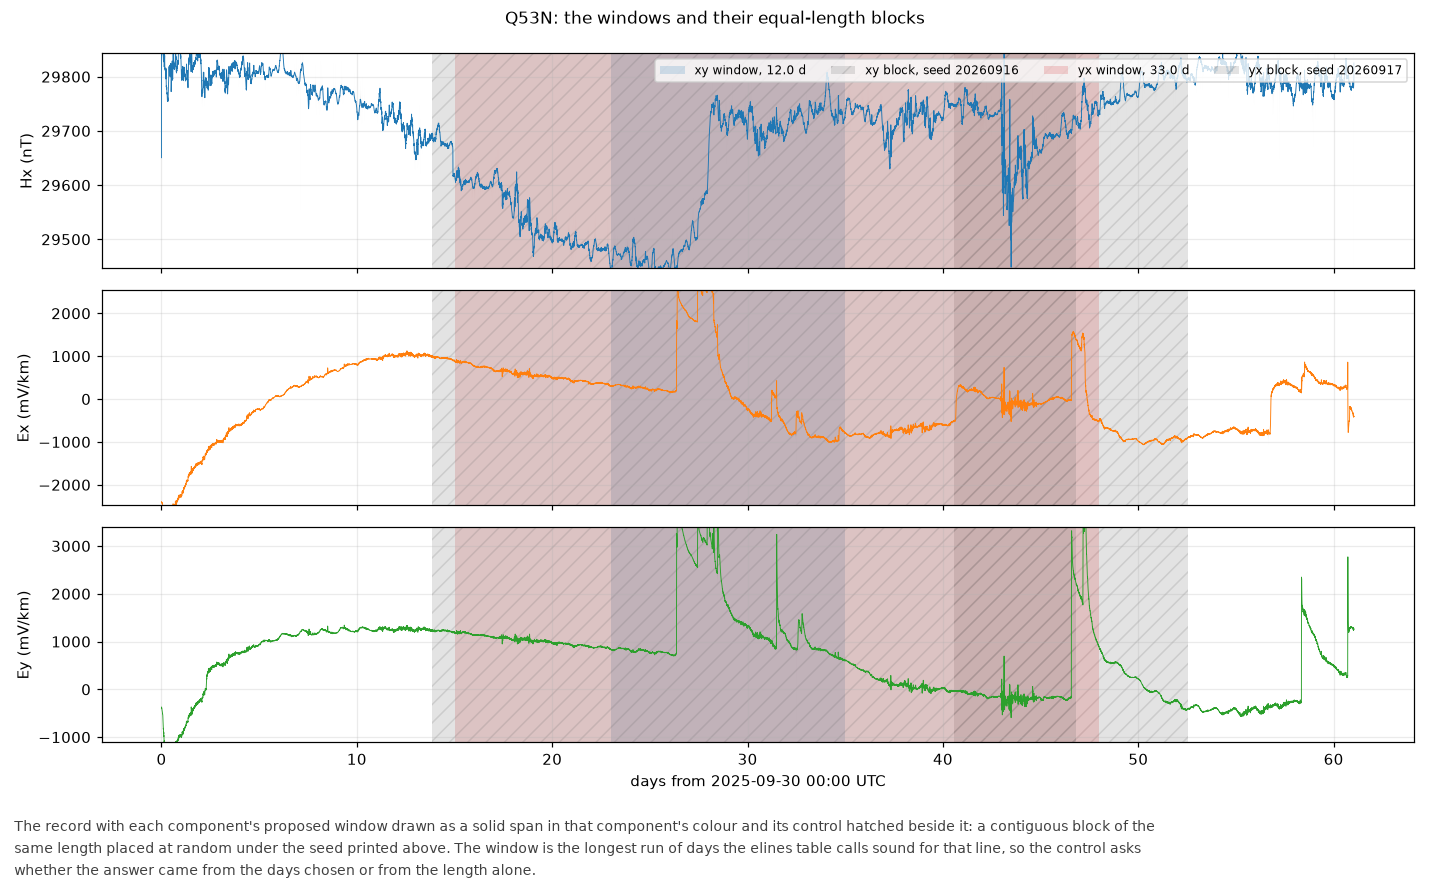

In [20]:
_t0w, _arrw, _metaw = CACHE.load(SITE, WORK, 1)
spans = []
for comp in COMPONENTS:
    w = WINDOWS[comp]
    if not w["t_start"]:
        continue
    spans.append(("%s window, %.1f d" % (comp, w["days"]), FF.SPAN_COLOUR[comp], None,
                  [(w["t_start"], w["t_end"])]))
    spans.append(("%s block, seed %d" % (comp, w["seed"]), "0.4", "//", [w["control"]]))
fig = FF.record_spans(_t0w, _arrw, OUT / "12_windows_record.png", site=SITE, spans=spans,
                      title="%s: the windows and their equal-length blocks" % SITE,
                      caption="The record with each component's proposed window drawn as a solid span in "
                              "that component's colour and its control hatched beside it: a contiguous "
                              "block of the same length placed at random under the seed printed above. The "
                              "window is the longest run of days the elines table calls sound for that line, "
                              "so the control asks whether the answer came from the days chosen or from the "
                              "length alone.")
WRITTEN.append(OUT / "12_windows_record.png")
display(Image(filename=str(OUT / "12_windows_record.png")))
del _arrw


In [21]:
MERGES = []
for comp in COMPONENTS:
    r = made_product("window_%s" % comp)
    if r is None or not BASE:
        continue
    out = OUT / FM.product_name(SITE, "merged_%s" % comp, BASELINE_KIND, 1, PARAMS)
    got = FM.merge_component(BASE, r["product"], comp, out_edi=out, verbose=False)
    MERGES.append(got)
    print("   %s: %s; rows changed %s (expected %s); every other row unchanged: %s"
          % (comp, got["how"], ", ".join(got["rows_changed"]) or "none", ", ".join(got["rows_expected"]),
             got["untouched_unchanged"]))
    FORM_ROWS.append(dict(site=SITE, form="merged_%s" % comp, kind=BASELINE_KIND, rate_hz=1.0,
                          params=PARAMS, product=str(out), controls="", seed=None, status="made",
                          criterion="the whole record for the healthy row and the tipper, the %s window for "
                                    "the other" % comp, error="", days=None, n_runs=None, seconds=None))
if not MERGES:
    print("   no windowed product was made, so nothing was merged")


   xy: grids differ (48 against 41 periods): the windowed xy was interpolated in log period onto the whole-record grid and the 7 period(s) outside the window's grid carry no xy; rows changed xx, xy (expected xx, xy); every other row unchanged: True
   yx: grids differ (48 against 41 periods): the windowed yx was interpolated in log period onto the whole-record grid and the 7 period(s) outside the window's grid carry no yx; rows changed yx, yy (expected yx, yy); every other row unchanged: True


In [22]:
rows, bad = [], []
for comp in COMPONENTS:
    w = WINDOWS[comp]
    if not w["t_start"]:
        bad.append("%s: no window was proposed (%s)" % (comp, w["reason"][:80]))
        continue
    for name in ("window_%s" % comp, "window_%s_control" % comp):
        r = made_product(name)
        if r is None:
            bad.append("%s was not made (%s)" % (name, str(rows_by_form().get(name, {}).get("error"))[:90]))
            continue
        rd = DL.reading(read(r["product"]), read(BASE) if BASE else None,
                        bands=[tuple(b) for b in DECADES], bar_band=tuple(BAR_BAND),
                        agree_band=tuple(AGREE_BAND))
        rows.append(dict(form=name, days=r.get("days"), bar=rd.get("bar"), bar_xy=rd.get("bar_xy"),
                         bar_yx=rd.get("bar_yx"), rho_ratio_xy=rd.get("rho_ratio_xy"),
                         rho_ratio_yx=rd.get("rho_ratio_yx"), phase_xy=rd.get("phase_diff_xy"),
                         per_decade=rd.get("per_decade", "")[:60]))
print(pd.DataFrame(rows).round(4).to_string(index=False) if rows else "no windowed product to read")
beaten = []
for comp in COMPONENTS:
    a = next((r for r in rows if r["form"] == "window_%s" % comp), None)
    b = next((r for r in rows if r["form"] == "window_%s_control" % comp), None)
    if a and b:
        beaten.append((comp, DL.beats(a["bar"], b["bar"], BAR_MARGIN), a["bar"], b["bar"]))
print()
for m in MERGES:
    print("   merge %s: rows changed %s; every other row unchanged %s"
          % (m["component"], ",".join(m["rows_changed"]) or "none", m["untouched_unchanged"]))
if bad:
    print("VERDICT: FAIL -- %s" % "; ".join(bad))
elif not MERGES:
    print("VERDICT: UNJUDGED -- no window was merged, so the merge was not scored")
elif not all(m["ok"] for m in MERGES):
    print("VERDICT: FAIL -- a merge changed a row other than its component's two: %s"
          % "; ".join("%s changed %s" % (m["component"], ",".join(m["rows_changed"]))
                      for m in MERGES if not m["ok"]))
elif not beaten:
    print("VERDICT: UNJUDGED -- no window and control pair was scored")
else:
    promoted = [c for c, ok, _x, _y in beaten if ok]
    inconsistent = [c for c, ok, x, y in beaten if ok and not DL.beats(x, y, BAR_MARGIN)]
    if inconsistent:
        print("VERDICT: FAIL -- %s promoted without beating its random block on the %g-%g s bar by %.0f %%"
              % (", ".join(inconsistent), BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN))
    else:
        print("VERDICT: PASS -- every merge changed exactly its component's two rows (%s) and left the rest "
              "untouched, every window carries an equal-length random block, and the %d promoted window(s) "
              "(%s) beat their block on the %g-%g s bar by at least %.0f %%: %s"
              % ("; ".join("%s -> %s" % (m["component"], ",".join(m["rows_changed"])) for m in MERGES),
                 len(promoted), ", ".join(promoted) or "none", BAR_BAND[0], BAR_BAND[1],
                 100 * BAR_MARGIN,
                 "; ".join("%s %.4f against %.4f%s" % (c, x, y, "" if ok else ", not promoted")
                           for c, ok, x, y in beaten)))


             form   days    bar  bar_xy  bar_yx  rho_ratio_xy  rho_ratio_yx  phase_xy                                                   per_decade
        window_xy 11.771 0.0037  0.0047  0.0037        0.9975        1.0435   -0.0616 5-10 s xy 0.87 +61.4 deg; 5-10 s yx 0.91 +11.6 deg; 10-100 s
window_xy_control 11.576 0.0025  0.0032  0.0025        0.9804        1.0027   -0.1150 5-10 s xy 0.90 -2.3 deg; 5-10 s yx 0.98 +1.2 deg; 10-100 s x
        window_yx 32.292 0.0014  0.0019  0.0014        0.9977        1.0097    0.0125 5-10 s xy 1.04 -3.2 deg; 5-10 s yx 0.97 +1.2 deg; 10-100 s x
window_yx_control 32.292 0.0014  0.0018  0.0014        1.0021        1.0103    0.0544 5-10 s xy 1.02 -1.2 deg; 5-10 s yx 0.97 +1.2 deg; 10-100 s x

   merge xy: rows changed xx,xy; every other row unchanged True
   merge yx: rows changed yx,yy; every other row unchanged True
VERDICT: PASS -- every merge changed exactly its component's two rows (xy -> xx,xy; yx -> yx,yy) and left the rest untouched, every wind

The windowed product, its random block and the merged file against the whole record. What to
look for is the merged curve following the whole record on the row the window did not touch and the windowed
curve on the row it did: that is the merge rule drawn, and a departure on the untouched row is the failure
the check above scores.

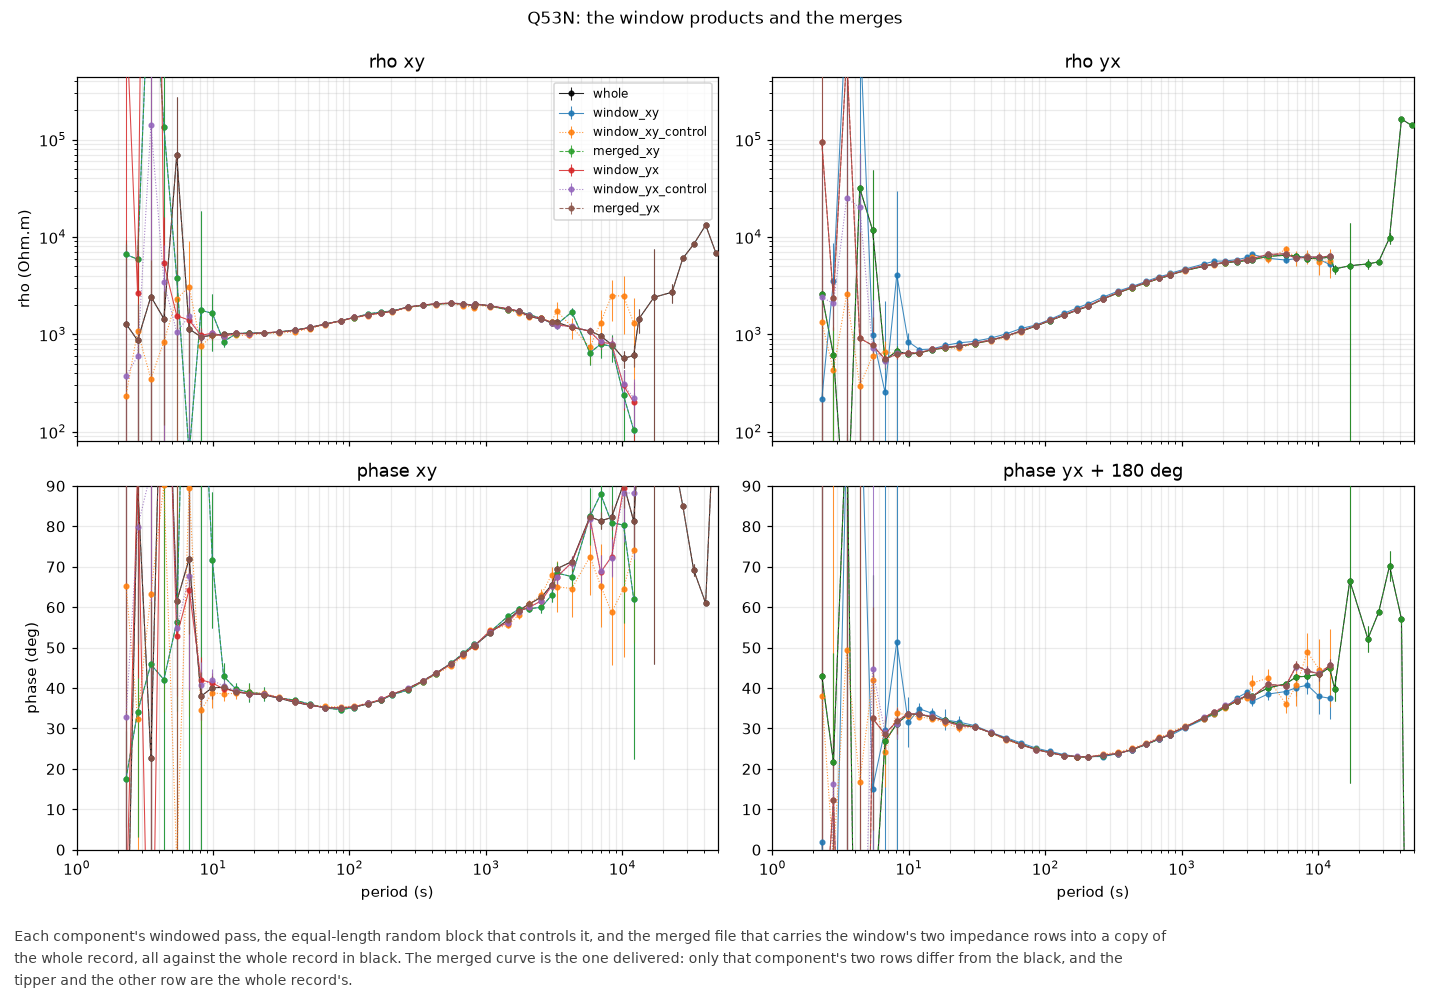

In [23]:
curves = [("whole", read(BASE), "k", "-")] if BASE else []
styles = {"window": ("-", 0), "control": (":", 1), "merged": ("--", 2)}
for k, comp in enumerate(COMPONENTS):
    for name, key in (("window_%s" % comp, "window"), ("window_%s_control" % comp, "control"),
                      ("merged_%s" % comp, "merged")):
        r = made_product(name)
        if r:
            ls, off = styles[key]
            curves.append((name, read(r["product"]), "C%d" % (3 * k + off), ls))
if len(curves) > 1:
    fig = FF.form_panels(curves, SITE, OUT / "13_window_products.png",
                         title="%s: the window products and the merges" % SITE,
                         caption="Each component's windowed pass, the equal-length random block that "
                                 "controls it, and the merged file that carries the window's two impedance "
                                 "rows into a copy of the whole record, all against the whole record in "
                                 "black. The merged curve is the one delivered: only that component's two "
                                 "rows differ from the black, and the tipper and the other row are the "
                                 "whole record's.", period_range=(1, 50000))
    WRITTEN.append(OUT / "13_window_products.png")
    display(Image(filename=str(OUT / "13_window_products.png")))
else:
    print("no windowed product was made, so there is nothing to draw against the whole record")


## 5. Best hours

The hours of the record are scored by the coherence of the component's pair over HOURS_BAND on
non-overlapping one-hour windows, and the best HOURS_FRACTION of the candidate windows is kept. The candidate
pool is the hours whose day the elines table calls sound; where that leaves fewer than 24 candidates the weak
days are admitted and the selection says so.

Two controls are scored beside it. The random control keeps the same number of windows drawn without
replacement from the same pool under SEED and is expected not to separate kept from dropped; if it does, the
statistic is not measuring what the selection claims. The contiguous controls tile windows of CONTIG_HOURS
hours from the first whole hour, score each by the mean of its hours and take the top ones until the kept
duration matches the selection's to within one window; one Aurora window at the deepest decimation level is
65,536 s, so a scattered selection cannot reach the long periods and only a contiguous comparison at the same
cost decides a long-period claim. The products of all three are read against the baseline.

**This check fails if the ranked selection does not separate kept from dropped on the selecting statistic, if
the random control separates by more than a fifth of the ranked selection's separation, or if a contiguous
control's duration misses the selection's by more than one window.** A random split of a scored pool
separates by a small amount half the time, so the random control's limb is read as a share of the ranked
selection's own separation and not as a sign test, which would be a coin toss and not a criterion.

In [24]:
HOURS = {}
for comp in COMPONENTS:
    t = time.time()
    HOURS[comp] = MK.best_hours(sv, SITE, comp, ELINES, band=tuple(HOURS_BAND), fraction=HOURS_FRACTION,
                                seed=SEED, contig_hours=tuple(CONTIG_HOURS))
    b = HOURS[comp]
    print("%s in %.0f s: %d candidate window(s) (%s), %d kept above %.3f, %.2f d; random %.2f d"
          % (comp, time.time() - t, b["n_candidates"], b["admitted"], b["n_selected"], b["threshold"],
             b["days_kept"], b["days_random"]))
rows = []
for comp in COMPONENTS:
    b = HOURS[comp]
    rows.append(dict(component=comp, set="ranked", n_windows=b["n_selected"], days=b["days_kept"],
                     median_kept=b["median_kept"], median_dropped=b["median_dropped"],
                     separates=b["separates"], matches=True))
    rows.append(dict(component=comp, set="random", n_windows=b["n_selected"], days=b["days_random"],
                     median_kept=b["random_median_kept"], median_dropped=b["random_median_dropped"],
                     separates=b["random_separates"], matches=True,
                     gap_share_of_ranked=b["random_gap_fraction"]))
    for h, c in sorted(b["contiguous"].items()):
        rows.append(dict(component=comp, set="contiguous %d h" % h, n_windows=c["n_windows"],
                         days=round(c["hours"] / 24.0, 3), median_kept=c["kept"],
                         median_dropped=c["dropped"], separates=c["discriminates"], matches=c["matches"]))
HOURS_TABLE = pd.DataFrame(rows)
print(HOURS_TABLE.round(4).to_string(index=False))


xy in 3 s: 1272 candidate window(s) (weak days admitted (fewer than 24 candidates on sound)), 318 kept above 0.077, 13.25 d; random 13.25 d


yx in 3 s: 1320 candidate window(s) (weak days admitted (fewer than 24 candidates on sound)), 330 kept above 0.097, 13.75 d; random 13.75 d
component             set  n_windows   days  median_kept  median_dropped  separates  matches  gap_share_of_ranked
       xy          ranked        318 13.250       0.1302          0.0452       True     True                  NaN
       xy          random        318 13.250       0.0526          0.0511      False     True               0.0172
       xy  contiguous 2 h        159 13.250       0.1770          0.0482       True     True                  NaN
       xy  contiguous 4 h         80 13.333       0.1728          0.0493       True     True                  NaN
       xy  contiguous 6 h         53 13.250       0.1712          0.0501       True     True                  NaN
       xy contiguous 24 h         13 13.000       0.1499          0.0578       True     True                  NaN
       yx          ranked        330 13.750       0.1587      

In [25]:
CONTIG_PICK, THIN_HOURS = {}, {}
for comp in COMPONENTS:
    b = HOURS[comp]
    if not b["n_selected"]:
        THIN_HOURS[comp] = b["n_candidates"]
        print("   %s: %d candidate window(s) and %d selected; no product is made"
              % (comp, b["n_candidates"], b["n_selected"]))
        continue
    ok = [(h, c) for h, c in sorted(b["contiguous"].items()) if c["matches"] and c["n_windows"]]
    if not ok:
        print("   %s: no contiguous set matches the selection's duration; none is run" % comp)
        continue
    h, c = min(ok, key=lambda hc: abs(hc[1]["hours"] - b["n_selected"]))
    CONTIG_PICK[comp] = h
    form("hours_%s" % comp, keep_extra=b["keep"], seed=SEED,
         keep_name="the best %.0f %% of %d candidate hour window(s) by %g-%g s coherence"
                   % (100 * HOURS_FRACTION, b["n_candidates"], HOURS_BAND[0], HOURS_BAND[1]),
         controls=["hours_%s_random" % comp, "hours_%s_contig%dh" % (comp, h)],
         criterion="beats its random and contiguous controls on the %g-%g s bar by %.0f %%"
                   % (BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN),
         extra_lines=["selection_statistic=%g-%g s coherence of %s with %s, one value an hour; kept median "
                      "%.3f against the dropped %.3f"
                      % (HOURS_BAND[0], HOURS_BAND[1], LINE[comp], COMP_H[comp], b["median_kept"],
                         b["median_dropped"])])
    form("hours_%s_random" % comp, keep_extra=b["random_keep"], seed=SEED,
         keep_name="%d window(s) drawn at random from the same pool, seed %d" % (b["n_selected"], SEED))
    form("hours_%s_contig%dh" % (comp, h), keep_extra=b["contiguous"][h]["keep"], seed=SEED,
         keep_name="the top %d contiguous %d h window(s), %d h against the selection's %d h"
                   % (b["contiguous"][h]["n_windows"], h, b["contiguous"][h]["hours"], b["n_selected"]))


The hour score through the record, with the three selections drawn as rows of spans above it:
the kept hours, the random hours of the same size, and the contiguous windows of the same duration. What to
look for is where the kept hours sit relative to the score -- they are its top by construction -- and how
differently the three rows cover the record, because their coverage is the only thing separating them.

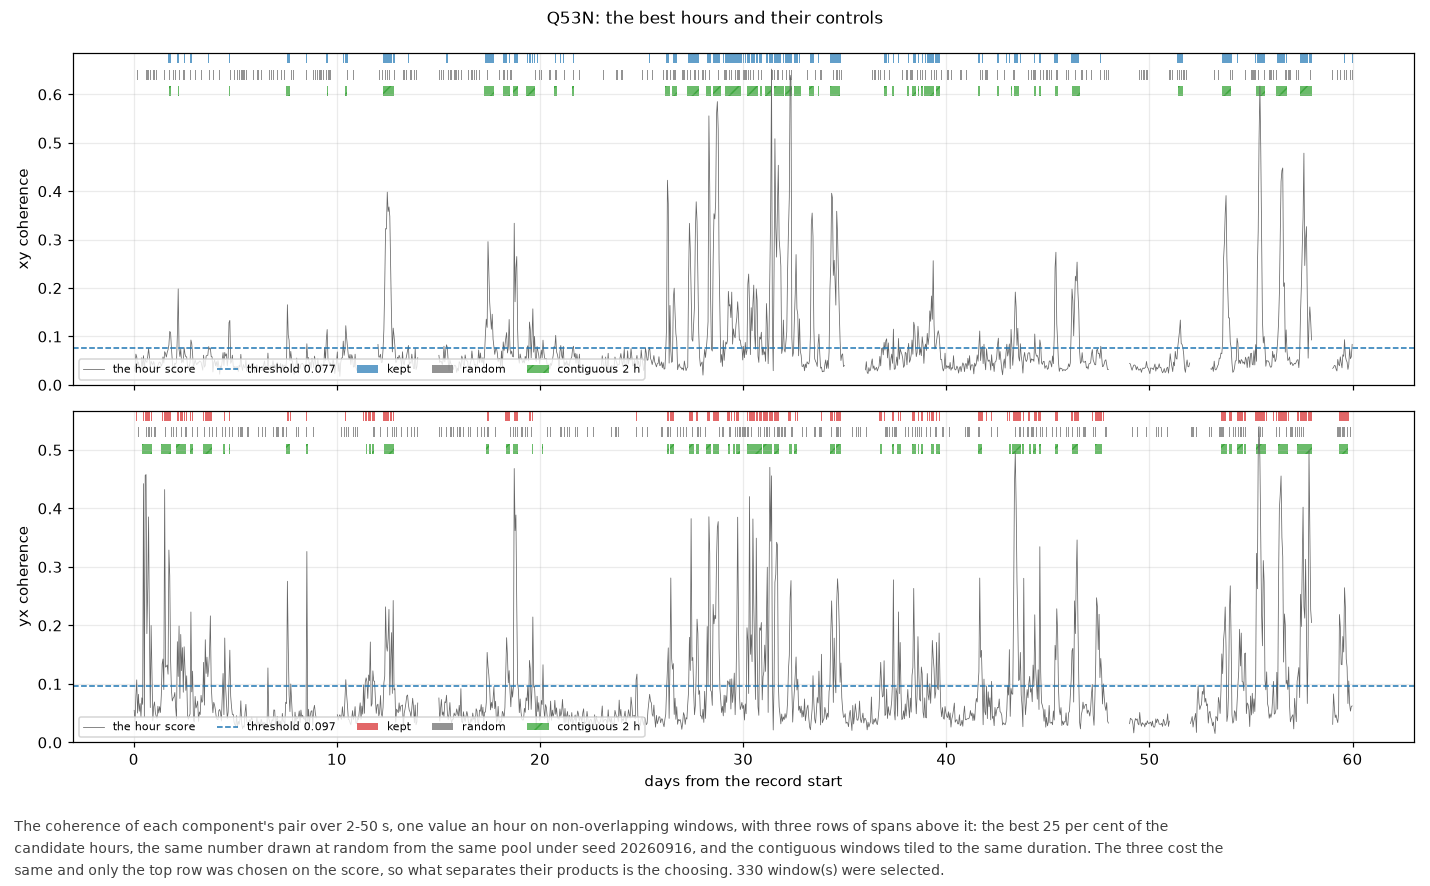

In [26]:
fig = FF.hour_scores(HOURS, SITE, OUT / "14_hour_scores.png", comps=COMPONENTS,
                     contig_pick=CONTIG_PICK)
WRITTEN.append(OUT / "14_hour_scores.png")
display(Image(filename=str(OUT / "14_hour_scores.png")))


In [27]:
rows, bad = [], []
for comp in COMPONENTS:
    b = HOURS[comp]
    if comp in THIN_HOURS:
        bad.append("%s: UNJUDGED -- %d candidate window(s), so nothing was selected and nothing was scored"
                   % (comp, THIN_HOURS[comp]))
        continue
    if not b["separates"]:
        bad.append("%s: the ranked selection's kept median %.3f is not above the dropped %.3f"
                   % (comp, b["median_kept"], b["median_dropped"]))
    if b["random_separates"]:
        bad.append("%s: the RANDOM control separates by %.4f, %.0f %% of the ranked selection's %.4f, above "
                   "the %.0f %% the criterion allows, so the statistic is not measuring the selection"
                   % (comp, b["random_gap"], 100 * b["random_gap_fraction"], b["gap"],
                      100 * b["random_gap_max"]))
    for h, c in sorted(b["contiguous"].items()):
        if not c["matches"]:
            bad.append("%s: the contiguous %d h set keeps %d h against the selection's %d h, more than one "
                       "window out" % (comp, h, c["hours"], b["n_selected"]))
    names = ["hours_%s" % comp, "hours_%s_random" % comp]
    if comp in CONTIG_PICK:
        names.append("hours_%s_contig%dh" % (comp, CONTIG_PICK[comp]))
    for name in names:
        r = made_product(name)
        if r is None:
            continue
        rd = DL.reading(read(r["product"]), read(BASE) if BASE else None,
                        bands=[tuple(x) for x in DECADES], bar_band=tuple(BAR_BAND),
                        agree_band=tuple(AGREE_BAND))
        rows.append(dict(form=name, days=r.get("days"), bar=rd.get("bar"), bar_xy=rd.get("bar_xy"),
                         bar_yx=rd.get("bar_yx"), rho_ratio_xy=rd.get("rho_ratio_xy"),
                         rho_ratio_yx=rd.get("rho_ratio_yx"), jumps_xy=rd.get("jumps_per_decade_xy")))
print(pd.DataFrame(rows).round(4).to_string(index=False) if rows else "no selection product to read")
print()
for comp in COMPONENTS:
    a = next((r for r in rows if r["form"] == "hours_%s" % comp), None)
    ctl = [r for r in rows if r["form"].startswith("hours_%s_" % comp)]
    if a and ctl:
        print("   %s: bar %.4f against %s -- %s"
              % (comp, a["bar"], ", ".join("%s %.4f" % (c["form"].split("_")[-1], c["bar"]) for c in ctl),
                 "promoted" if all(DL.beats(a["bar"], c["bar"], BAR_MARGIN) for c in ctl)
                 else "NOT promoted: efficiency, not a different answer"))
if bad:
    print("VERDICT: FAIL -- %s" % "; ".join(bad))
elif not len(HOURS_TABLE):
    print("VERDICT: UNJUDGED -- no component was scored")
else:
    print("VERDICT: PASS -- on every component the ranked selection separates kept from dropped (%s), the "
          "random control separates by at most a fifth of that (%s), and every contiguous set's duration "
          "matches the selection's to within one window"
          % ("; ".join("%s %.3f over %.3f" % (c, HOURS[c]["median_kept"], HOURS[c]["median_dropped"])
                       for c in COMPONENTS),
             "; ".join("%s %.4f against %.4f" % (c, HOURS[c]["random_gap"], HOURS[c]["gap"])
                       for c in COMPONENTS)))


             form   days    bar  bar_xy  bar_yx  rho_ratio_xy  rho_ratio_yx  jumps_xy
         hours_xy    NaN 0.0023  0.0033  0.0023        0.9909        1.0096     0.806
  hours_xy_random    NaN 0.0028  0.0049  0.0028        0.9938        0.9993     0.000
hours_xy_contig2h 12.266 0.0022  0.0032  0.0022        0.9991        1.0040     0.537
         hours_yx 12.092 0.0021  0.0034  0.0021        0.9977        1.0033     0.321
  hours_yx_random 12.715 0.0027  0.0042  0.0027        1.0051        1.0079     0.000
hours_yx_contig2h 12.065 0.0020  0.0031  0.0020        0.9974        1.0048     0.321

   xy: bar 0.0023 against random 0.0028, contig2h 0.0022 -- NOT promoted: efficiency, not a different answer
   yx: bar 0.0021 against random 0.0027, contig2h 0.0020 -- NOT promoted: efficiency, not a different answer
VERDICT: PASS -- on every component the ranked selection separates kept from dropped (xy 0.130 over 0.045; yx 0.159 over 0.047), the random control separates by at most a fifth of

The four products of each component on one set of panels: the whole record, the selection, its
random control and its contiguous control. What to look for is the long end, where a scattered selection
cannot reach and the contiguous one can: the deepest Aurora window is 65,536 s, so any claim above a few
thousand seconds belongs to the contiguous curve and not to the scattered one.

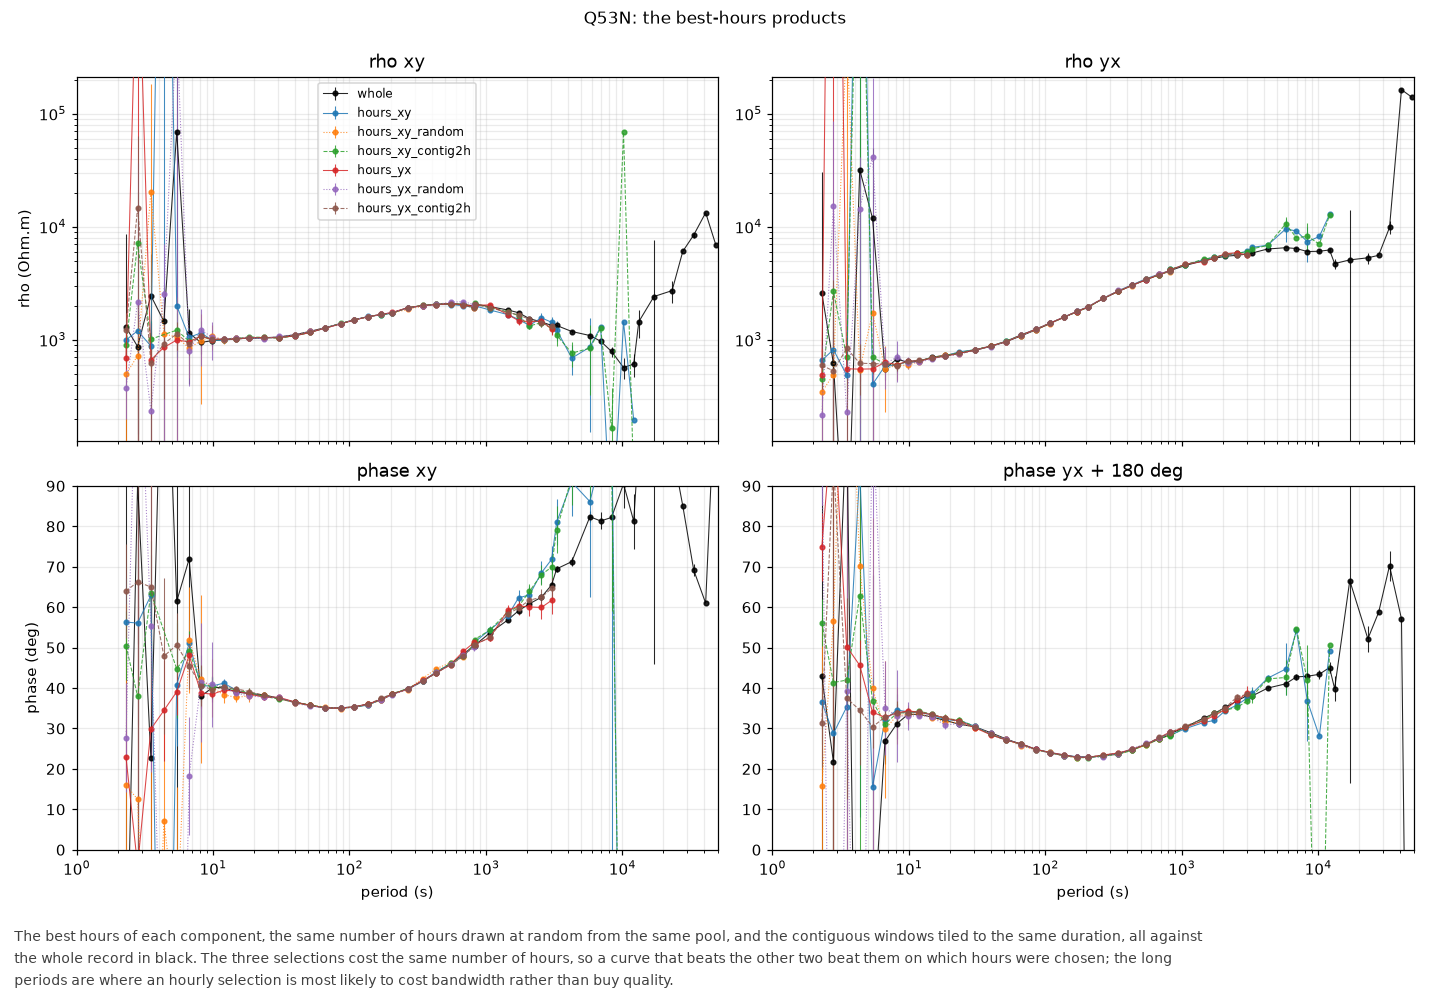

In [28]:
curves = [("whole", read(BASE), "k", "-")] if BASE else []
for k, comp in enumerate(COMPONENTS):
    names = ["hours_%s" % comp, "hours_%s_random" % comp]
    if comp in CONTIG_PICK:
        names.append("hours_%s_contig%dh" % (comp, CONTIG_PICK[comp]))
    for j, name in enumerate(names):
        r = made_product(name)
        if r:
            curves.append((name, read(r["product"]), "C%d" % (3 * k + j), ("-", ":", "--")[j]))
if len(curves) > 1:
    fig = FF.form_panels(curves, SITE, OUT / "15_hours_products.png",
                         title="%s: the best-hours products" % SITE,
                         caption="The best hours of each component, the same number of hours drawn at "
                                 "random from the same pool, and the contiguous windows tiled to the same "
                                 "duration, all against the whole record in black. The three selections "
                                 "cost the same number of hours, so a curve that beats the other two beat "
                                 "them on which hours were chosen; the long periods are where an hourly "
                                 "selection is most likely to cost bandwidth rather than buy quality.",
                         period_range=(1, 50000))
    WRITTEN.append(OUT / "15_hours_products.png")
    display(Image(filename=str(OUT / "15_hours_products.png")))
else:
    print("no selection product was made, so there is nothing to draw against the whole record")


## 6. The shared centre and the arm diagonal

The EDL L layout is three electrodes: a shared centre C, a north arm of length L_N and an east arm of length
L_E, so Ex = (V_N - V_C)/L_N and Ey = (V_E - V_C)/L_E. A noisy centre puts one voltage on both lines, and
because the two lines divide that voltage by different lengths it does not arrive as the same field on both.
With the lines physically signed and a centre voltage n the model reads

    Ex = Ex_true + c,   Ey = Ey_true + s c (L_N / L_E),   c = -n / L_N,

with s = +1 for arms north and east (or south and west) and -1 where one arm is reversed. The E signs in
decisions.csv predict s; an undecided sign is never filled by convention and leaves the site UNJUDGED on that
prediction.

The residual test removes the part of each line that (Hx, Hy) explains, per frequency bin, from the
cross-spectra at 20-200 s on the CENTRE_DAYS days of highest Ex-Ey coherence, and reads what is left: the
complex gain g = S_ry,rx / S_rx,rx of a real shared centre is s L_N / L_E, so the model holds where the
residual coherence is at least 0.9 and |g| divided by the expected L_N / L_E lies between 0.85 and 1.18. The
sign of the real part of the gain is still the observed s. The clean diagonal is the one whose multiple
coherence with (Hx, Hy) is the higher.

The expected gain is L_N / L_E, not 1. With equal arms (Victoria's 50 m) the ratio is 1 and the two forms
coincide; with unequal arms they do not: Q58N, with arms of 9.0 m and 11.9 m, reads a gain of 0.76 at a
residual coherence of 1.00, and 9.0/11.9 = 0.756, so its two lines share one voltage. The arm lengths come
from sites.csv dipole_n_m and dipole_e_m; an `assume:` cell is used and named, and a site with no lengths on
file is UNJUDGED on this criterion.

The control is built, not found. The site's own Ex is paired with the nearest sound site's Ey, both read
against the site's own (Hx, Hy) over the same days, and the residual test is run on that pair: two electrodes
tens of kilometres apart have no common voltage, so the model must not hold there. A control site whose own
Ex-Ey coherence stays under 0.35 on every day need not exist -- a one-dimensional earth correlates the two
lines through the source field alone, and no site of AusLAMP Queensland Phase 1 clears that ceiling -- so the
found site is kept as a reading beside the built pair.

Where the model holds, the remedy is the arm diagonal: the voltage between the two arm electrodes carries no
centre at any pair of lengths, because the centre cancels in the difference of the two arm potentials.

    V_N - V_E = L_N Ex - L_E Ey,   d = sqrt(L_N^2 + L_E^2),   Ex' = (L_N Ex - L_E Ey) / d,

which is the field along the unit vector (L_N, -L_E)/d in (north, east), that is at theta = atan2(-L_E, L_N)
from north, over the separation d of the two arm electrodes. The orthogonal row Ey' = (L_E Ex + L_N Ey)/d
carries the centre and is kept for the record. Equal arms give theta = -45 deg and the pair reduces to
(Ex - Ey)/sqrt 2 and (Ex + Ey)/sqrt 2 exactly. The pair is E in the frame turned by theta, so a pass on the
variant cache gives R(theta) Z, and turning the H columns as well completes Z' = (R Z) R^T and T' = T R^T at
that theta. The x' row is the clean one; the y' row is kept for the record. The turn is checked on the elements to 1e-6 relative, on the determinant to 1e-5
of the squared Frobenius norm -- the relative form is meaningless at a near-singular period -- and on the
Frobenius norm to 1e-6. The trace is not an invariant of a column-only turn and its ratio is printed as the
counter-example.

**This check fails if the built control holds the model, if it could not be built, if the variant cache does
not reproduce (L_N Ex - L_E Ey)/d of the signed source at every finite sample, if the turn-back changes an
invariant beyond its tolerance, or if a sign prediction disagrees with the observed sign where both
exist.**

In [29]:
ARMS = CE.arm_lengths(sv, SITE)
G_EXPECTED = CE.expected_gain(ARMS["L_N"], ARMS["L_E"])
THETA = CE.diagonal_angle(ARMS["L_N"], ARMS["L_E"])
print("the arms at %s: %s" % (SITE, ARMS["note"]))
print("   the model predicts |g| = L_N / L_E = %.3f, and the arm diagonal lies at %+.2f deg from north over "
      "a separation of %.2f m (equal arms would give 1.000 and -45.00 deg)"
      % (G_EXPECTED, THETA, CE.diagonal_length(ARMS["L_N"], ARMS["L_E"])))
if ARMS["assumed"]:
    print("   %s carries an assumed length, which the product's provenance carries with it"
          % ", ".join(ARMS["assumed"]))
print()
BUILT = CE.built_control(sv, SITE, days=CENTRE_DAYS, elines=ELINES, members=SITES)
print("the built control: %s -- %s" % (BUILT.get("site"), BUILT.get("reason")))
CTRL = CE.control_site(sv, SITE, SITES)
print("the found control site (a reading): %s -- %s" % (CTRL.get("site"), CTRL.get("reason")))
if "table" in CTRL:
    print(CTRL["table"].head(6).round(3).to_string(index=False))
print("it qualifies under the %.2f ceiling on every scored day: %s"
      % (CE.CONTROL_EX_EY_MAX, CTRL.get("qualifies")))
print()
CENTRE = {SITE: CE.residual_test(sv, SITE, CENTRE_DAYS, ELINES)}
if BUILT.get("judged"):
    CENTRE[BUILT["site"]] = BUILT
if CTRL.get("site"):
    CENTRE[CTRL["site"]] = CE.residual_test(sv, CTRL["site"], CENTRE_DAYS,
                                            CE.read_elines(sv, CTRL["site"]))
cols = ["site", "days", "src_coh", "resid_coh", "L_N", "L_E", "gain_expected", "resid_gain", "gain_ratio",
        "s_pred", "s_obs", "sign_undecided", "mcoh_diff", "mcoh_sum", "model_holds", "control",
        "clean_pred", "clean_obs", "clean_by_H", "sign_agrees", "remedy_applicable"]
CENTRE_TABLE = pd.DataFrame([{k: v.get(k) for k in cols} for v in CENTRE.values() if v.get("judged")])
print(CENTRE_TABLE.round(3).to_string(index=False) if len(CENTRE_TABLE) else "no site produced a usable day")


the arms at Q53N: L_N 10.1 m, L_E 10 m (deployment sheet transcribed 2026-09-05, confidence high)
   the model predicts |g| = L_N / L_E = 1.010, and the arm diagonal lies at -44.71 deg from north over a separation of 14.21 m (equal arms would give 1.000 and -45.00 deg)



the built control: Q53N Ex + Q52N Ey -- the site's own Ex against Q52N's Ey, both on the site's own H over the same days: two electrodes that cannot share a centre
the found control site (a reading): Q85N -- the lowest daily maximum Ex-Ey coherence of the group (0.354 over 61 scored days)
site  max_coh_Ex_Ey  median_coh_Ex_Ey  days
Q85N          0.354             0.100    61
Q74N          0.408             0.161    60
 Q84          0.481             0.089    59
 Q83          0.563             0.068    61
Q60N          0.570             0.327    61
Q64N          0.592             0.022    53
it qualifies under the 0.35 ceiling on every scored day: False



             site                             days  src_coh  resid_coh  L_N  L_E  gain_expected  resid_gain  gain_ratio  s_pred  s_obs sign_undecided  mcoh_diff  mcoh_sum  model_holds control clean_pred clean_obs clean_by_H sign_agrees remedy_applicable
             Q53N 2025-10-25 2025-10-17 2025-10-08    0.983      0.971 10.1 10.0           1.01       0.985       0.976     1.0    1.0                     0.588     0.809         True   False       diff      diff        sum        True             False
Q53N Ex + Q52N Ey 2025-10-25 2025-10-17 2025-10-23    0.031      0.018 10.1 10.0           1.01      19.939      19.742     NaN    NaN            NaN      0.058     0.058        False    None        NaN       NaN        NaN        None              None
             Q85N 2025-10-10 2025-11-12 2025-10-27    0.293      0.248 12.1 11.1           1.09       0.777       0.712    -1.0    1.0                     0.101     0.077        False   False        sum      diff       diff        None   

The residual test drawn: the residual coherence and the complex gain over the band, for the site
and for the built control, with the 0.9 coherence line and the 0.85-1.18 band on the gain divided by the
L_N / L_E the arms predict, so 1 is what a shared centre would give at this site's lengths. What to look for
is the site's coherence riding along the top of the band with a scaled gain sitting inside the box while the
built control's coherence lies on the floor: the gap between the two lines is what says the test can tell a
shared centre from a pair that cannot have one.

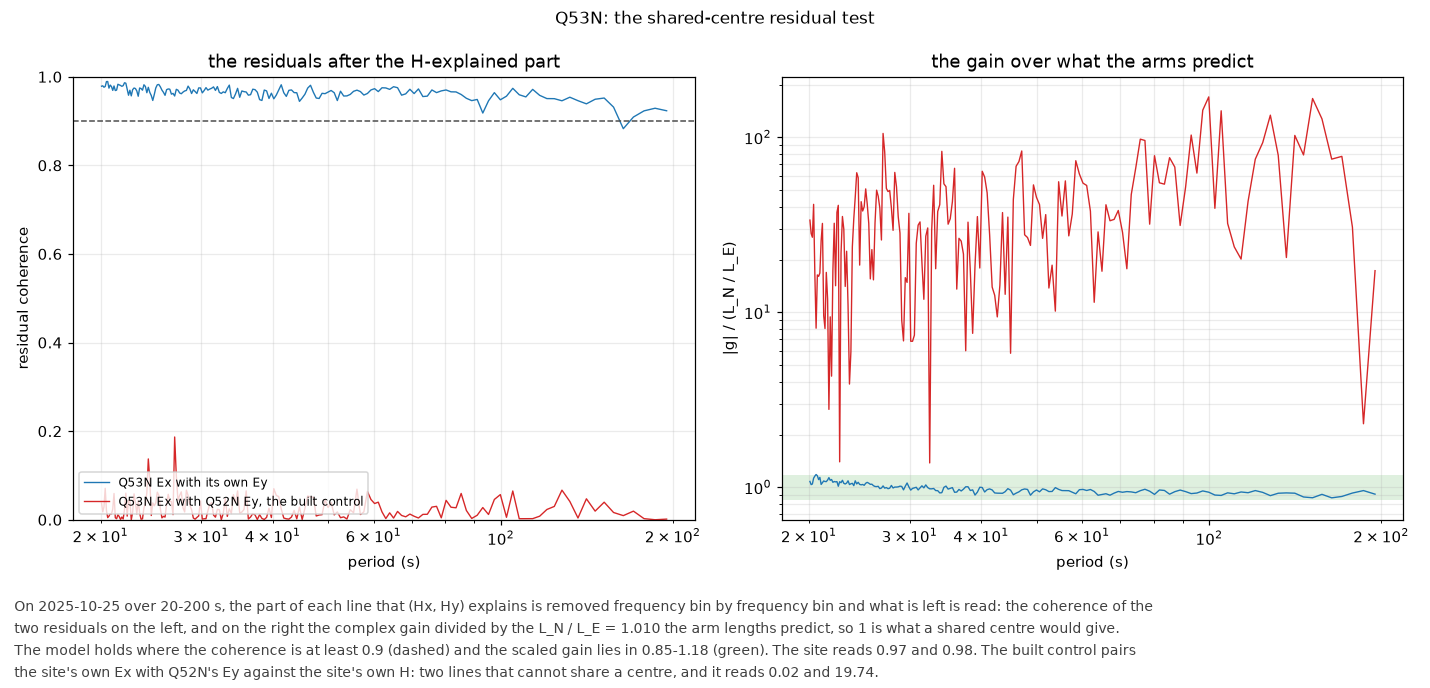

In [30]:
fig = FF.residual_panels(sv, SITE, CENTRE.get(SITE, {}), BUILT, OUT / "16_centre_residual.png",
                         days=CENTRE_DAYS, elines=ELINES, band_s=CE.BAND_S)
WRITTEN.append(OUT / "16_centre_residual.png")
display(Image(filename=str(OUT / "16_centre_residual.png")))


In [31]:
NE, DIAG = dict(written=False), None
me = CENTRE.get(SITE, {})
if me.get("model_holds"):
    NE = CE.ne_variant(sv, SITE, 1, force=REDO)
    print("the NE variant cache: %s (%s; Ex' equals (L_N Ex - L_E Ey)/d of the signed source at every one of "
          "the %s finite samples: %s)"
          % (NE.get("path"), ("rewritten: the cache on disk was built at other arm lengths or another frame"
                              if NE.get("refreshed") else
                              "written" if NE.get("written") else "already on disk and checked again"),
             NE.get("n_finite"), NE.get("exact")))
    # a pass on a cache that has just been rebuilt at a different frame is not a pass on this cache
    DIAG = form("diagonal", variant="ne", apply_e_signs=False, turn_ne=True, turn_angle_deg=THETA,
                redo=bool(REDO or NE.get("refreshed")),
                criterion="the turn-back keeps the element, determinant and Frobenius invariants of a "
                          "column-only turn",
                extra_lines=["diagonal=x' along the arm diagonal, (L_N Ex - L_E Ey)/d with L_N %.4g m, "
                             "L_E %.4g m and d %.4g m, the clean row where the model holds; y' orthogonal "
                             "to it, (L_E Ex + L_N Ey)/d, kept for the record"
                             % (ARMS["L_N"], ARMS["L_E"], CE.diagonal_length(ARMS["L_N"], ARMS["L_E"])),
                             "frame_deg=%+.4f = atan2(-L_E, L_N); equal arms would give -45" % THETA])
    t = DIAG.get("turn") or {}
    if t:
        print("   the turn-back over %d period(s): elements %.2e (tolerance %.0e), determinant %.2e scaled "
              "(tolerance %.0e), Frobenius %.2e (tolerance %.0e); the trace ratio is %.3f, which is why the "
              "trace is not one of the criteria"
              % (t["n"], t["max_element_rel"], CE.ELEMENT_RTOL, t["max_det_scaled"], CE.DET_SCALED_TOL,
                 t["max_frobenius_rel"], CE.FROBENIUS_RTOL, t["trace_ratio"]))
    print("   the remedy %s at %s: the clean diagonal by the observed sign is the %s and by H coherence the "
          "%s" % ("applies" if me.get("remedy_applicable") else "does NOT apply", SITE,
                  me.get("clean_obs"), me.get("clean_by_H")))
else:
    print("the model does not hold at %s (residual coherence %.2f, gain %.2f against the %.3f the arms "
          "predict, a ratio of %.2f): no variant cache is written"
          % (SITE, me.get("resid_coh", np.nan), me.get("resid_gain", np.nan), G_EXPECTED,
             me.get("gain_ratio", np.nan)))


the NE variant cache: E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\cache_1hz_ne\Q53N.npz (already on disk and checked again; Ex' equals (L_N Ex - L_E Ey)/d of the signed source at every one of the 5273400 finite samples: True)
   the turn-back over 48 period(s): elements 4.09e-07 (tolerance 1e-06), determinant 7.23e-08 scaled (tolerance 1e-05), Frobenius 3.29e-07 (tolerance 1e-06); the trace ratio is 0.649, which is why the trace is not one of the criteria
   the remedy does NOT apply at Q53N: the clean diagonal by the observed sign is the diff and by H coherence the sum


One day of the two signed lines above and the two arm diagonals below. What to look for is the two
lines moving together -- that common motion is the centre's voltage, arriving on each line divided by its own
arm length -- and the length-weighted difference beneath them, which is what the arm diagonal keeps after it
has cancelled.

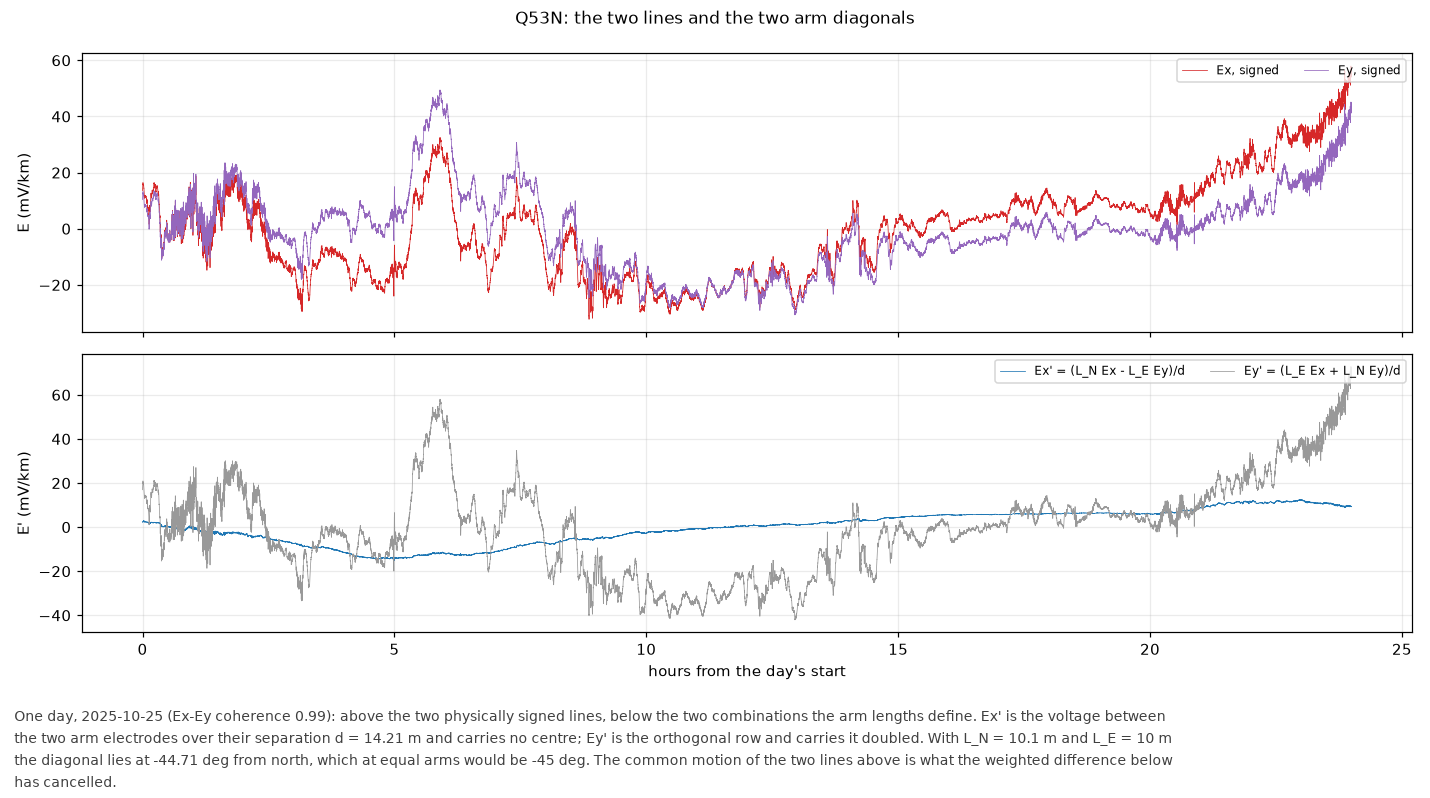

In [32]:
fig = FF.diagonal_day(sv, SITE, OUT / "17_diagonal_day.png", elines=ELINES)
WRITTEN.append(OUT / "17_diagonal_day.png")
display(Image(filename=str(OUT / "17_diagonal_day.png")))


The diagonal product against the baseline, where one was built. The x' row is the arm diagonal and
not the xy component, so the two curves are not the same quantity and are not expected to lie on each other:
what to look for is whether the x' row is smoother and carries a smaller bar than the row the shared centre
sits in.

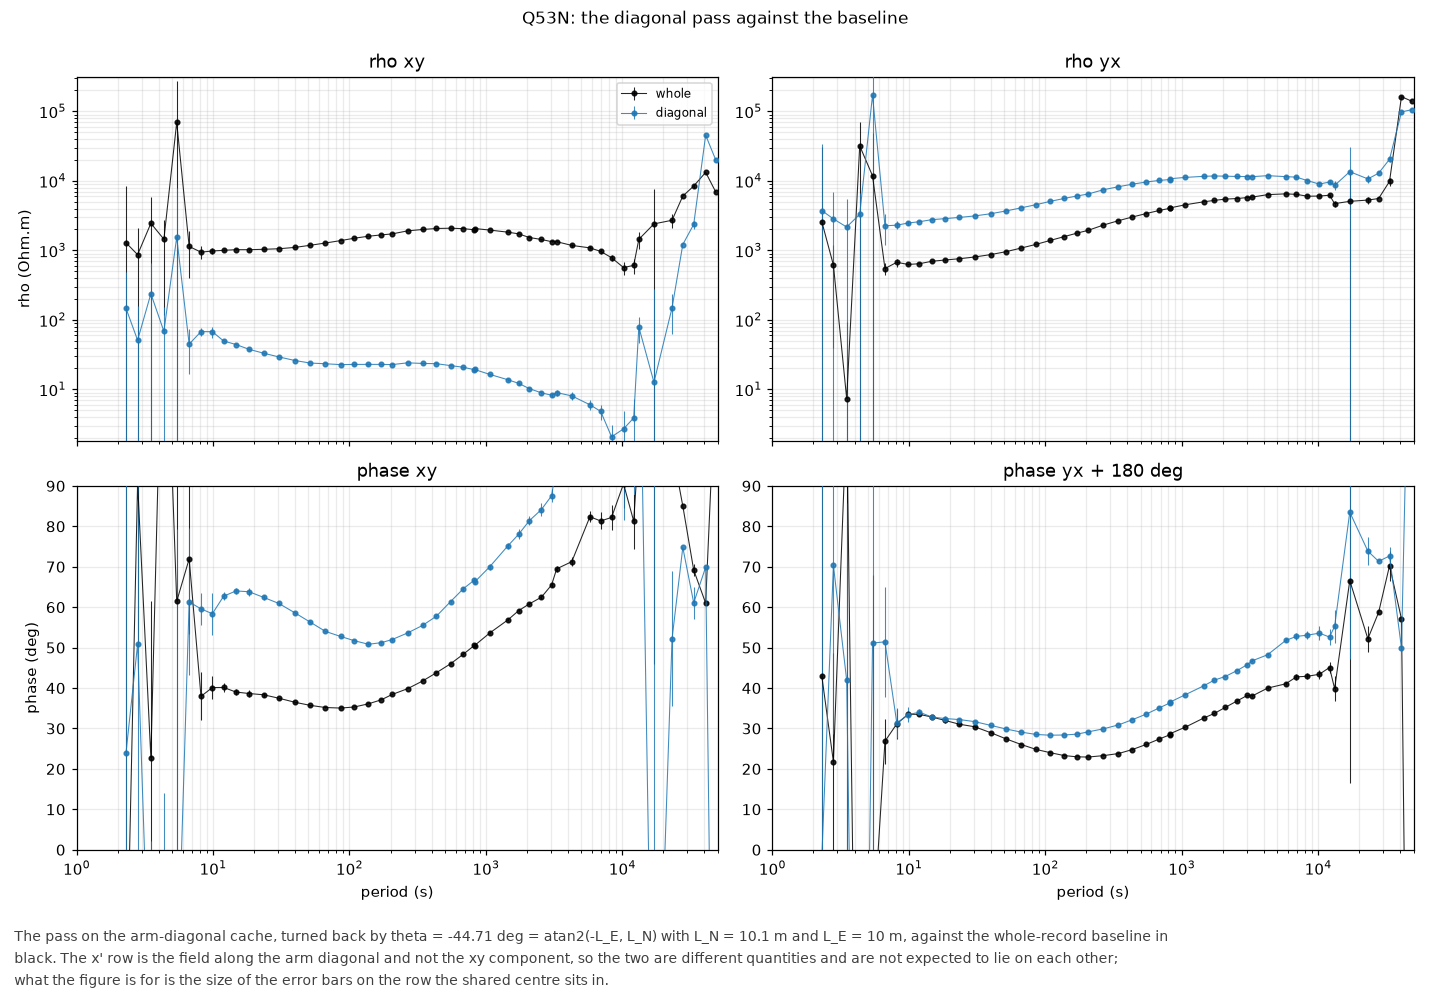

In [33]:
r = made_product("diagonal")
if r and BASE:
    fig = FF.form_panels([("whole", read(BASE), "k", "-"), ("diagonal", read(r["product"]), "C0", "-")],
                         SITE, OUT / "18_diagonal_product.png",
                         title="%s: the diagonal pass against the baseline" % SITE,
                         caption="The pass on the arm-diagonal cache, turned back by theta = %+.2f deg = "
                                 "atan2(-L_E, L_N) with L_N = %.4g m and L_E = %.4g m, against the "
                                 "whole-record baseline in black. The x' row is the field along the arm "
                                 "diagonal and not the xy component, so the two are different quantities "
                                 "and are not expected to lie on each other; what the figure is for is the "
                                 "size of the error bars on the row the shared centre sits in."
                                 % (THETA, ARMS["L_N"], ARMS["L_E"]), period_range=(1, 50000))
    WRITTEN.append(OUT / "18_diagonal_product.png")
    display(Image(filename=str(OUT / "18_diagonal_product.png")))
else:
    print("no diagonal product was built, so there is nothing to draw against the baseline")


In [34]:
fail = []
me = CENTRE.get(SITE, {})
ctrl_row = CENTRE.get(CTRL.get("site"), {})
if not BUILT.get("judged"):
    fail.append("the control could not be built (%s), so the test was not shown able to fail"
                % BUILT.get("reason"))
elif BUILT.get("model_holds"):
    fail.append("the built control %s holds the model (residual coherence %.2f, gain %.2f, a ratio of %.2f "
                "to the %.3f the arms predict): the test finds a shared centre between two electrodes that "
                "cannot have one"
                % (BUILT["site"], BUILT["resid_coh"], BUILT["resid_gain"],
                   BUILT.get("gain_ratio", np.nan), G_EXPECTED))
if me.get("sign_undecided"):
    fail.append("UNJUDGED on the sign prediction at %s: %s undecided in decisions.csv, never filled by "
                "convention" % (SITE, me["sign_undecided"]))
elif me.get("model_holds") and me.get("sign_agrees") is False:
    fail.append("the sign prediction %+d disagrees with the observed %+d at %s"
                % (me["s_pred"], me["s_obs"], SITE))
if NE.get("exact") is False:
    fail.append("the variant cache does not reproduce (L_N Ex - L_E Ey)/d of the signed source at every one "
                "of its %s finite samples" % NE.get("n_finite"))
if DIAG and (DIAG.get("turn") or {}) and not (DIAG.get("turn") or {}).get("ok"):
    t = DIAG["turn"]
    fail.append("the turn-back moves an invariant: elements %.2e, determinant %.2e, Frobenius %.2e"
                % (t["max_element_rel"], t["max_det_scaled"], t["max_frobenius_rel"]))
t = (DIAG or {}).get("turn") or {}
sign = lambda v: ("%+d" % v) if isinstance(v, (int, float)) and np.isfinite(v) else "undecided"
turn_text = (("the turn-back on the diagonal holds the three invariants: elements %.1e, determinant %.1e "
              "scaled, Frobenius %.1e, with the trace ratio %.3f as the counter-example"
              % (t.get("max_element_rel", np.nan), t.get("max_det_scaled", np.nan),
                 t.get("max_frobenius_rel", np.nan), t.get("trace_ratio", np.nan))) if t
             else "no diagonal was built, so the turn-back was not scored")
read_text = ("%s has arms of %.4g m north and %.4g m east, so the model predicts |g| = %.3f; it reads a "
             "residual coherence of %.2f with a gain of %.2f, a ratio of %.2f, so the model %s there, and "
             "its observed sign %s %s the %s its E signs predict"
             % (SITE, ARMS["L_N"], ARMS["L_E"], G_EXPECTED, me.get("resid_coh", np.nan),
                me.get("resid_gain", np.nan), me.get("gain_ratio", np.nan),
                "HOLDS" if me.get("model_holds") else "does NOT hold", sign(me.get("s_obs")),
                "agrees with" if me.get("sign_agrees") else "is not scored against",
                sign(me.get("s_pred"))))
found_text = ("the found control site %s %s the %.2f ceiling (daily maximum %.3f) and reads a residual "
              "coherence of %.2f"
              % (CTRL.get("site"), "clears" if CTRL.get("qualifies") else "does not clear",
                 CE.CONTROL_EX_EY_MAX, CTRL.get("max_coh_Ex_Ey", np.nan),
                 ctrl_row.get("resid_coh", np.nan))) if CTRL.get("site") else "no control site was found"
if fail:
    print("VERDICT: FAIL -- %s; %s; %s; %s" % ("; ".join(fail), read_text, turn_text, found_text))
else:
    print("VERDICT: PASS -- the built control %s does not hold the model (residual coherence %.2f, gain "
          "%.2f); %s; %s; as a reading, %s"
          % (BUILT.get("site"), BUILT.get("resid_coh", np.nan), BUILT.get("resid_gain", np.nan),
             read_text, turn_text, found_text))


VERDICT: PASS -- the built control Q53N Ex + Q52N Ey does not hold the model (residual coherence 0.02, gain 19.94); Q53N has arms of 10.1 m north and 10 m east, so the model predicts |g| = 1.010; it reads a residual coherence of 0.97 with a gain of 0.99, a ratio of 0.98, so the model HOLDS there, and its observed sign +1 agrees with the +1 its E signs predict; the turn-back on the diagonal holds the three invariants: elements 4.1e-07, determinant 7.2e-08 scaled, Frobenius 3.3e-07, with the trace ratio 0.649 as the counter-example; as a reading, the found control site Q85N does not clear the 0.35 ceiling (daily maximum 0.354) and reads a residual coherence of 0.25


## 7. The 10 Hz forms

A site recorded at 10 Hz carries a short end the 1 Hz cache cannot reach. This section passes the whole 10 Hz
record against the same reference kind the 1 Hz baseline used and draws the two rates on one page.

The reference is BASELINE_KIND at 10 Hz, which is the remote's own 10 Hz record on this site's grid, and
where no store has been built at that rate the form is refused with that reason and no pass is run. The
single station is not a kind of this package, so a missing store is not fallen back from: a product estimated
on the site's own H is biased by its own noise and its error bars do not show the bias.

A form the method's own floor refuses is a reading; a form that crashes is a failure. Before the form reaches
Aurora the workbook measures what its cache leaves against the reference it will be passed with -- the mask,
the reference's own coverage, and the record cut into runs at the 3,600 s floor -- and prints the kept days
and the run count beside the whole record's. A form whose kept duration is zero is not passed: its row reads
`refused` with those numbers and the figure carries that sentence where its curve would have been, rather
than a traceback out of the estimator.

**This check fails if any form of this section ended in an exception rather than a stated refusal.**

In [35]:
REFUSED, COVER = [], {}
if 10 not in RATES:
    print("RATES does not include 10: this section reads the 10 Hz cache and is not run")
elif not (FM.cache_dir(WORK, 10) / ("%s.npz" % SITE)).exists():
    print("no 10 Hz cache at %s: this instrument records at 1 Hz"
          % (FM.cache_dir(WORK, 10) / ("%s.npz" % SITE)))
else:
    kind10 = BASELINE_KIND
    NO_STORE_10 = not (WORK / "references" / "10hz" / ("%s_%s.npz" % (kind10, SITE))).exists()
    if NO_STORE_10:
        # the single station is not a kind of this package, so a missing store refuses the form rather
        # than falling back to one: a product estimated on the site's own H is biased by its own noise
        why = ("refused: there is no 10 Hz %s reference store for %s, and the single station is not a kind "
               "of this package" % (kind10, SITE))
        FORM_ROWS.append(FM.refused_row(sv, SITE, "whole10", OUT, kind10, 10, PARAMS, why,
                                        criterion="not passed: the reference this form needs is not on "
                                                  "disk"))
        REFUSED.append(("whole10", why))
        print("   whole10 is NOT passed -- %s" % why)
    else:
        # what the cache leaves against the reference it will be passed with, measured BEFORE the pass: the
        # mask, the reference's own coverage and the run floor, cut into the runs Aurora would be handed. A
        # cache that leaves nothing is refused here with its numbers, rather than crashing the estimator
        COVER["whole10"] = FM.coverage(sv, SITE, kind=kind10, rate=10)
        c = COVER["whole10"]
        print("what the 10 Hz cache leaves against the %s reference, before the pass: the mask, the "
              "reference's own coverage, and the record cut into runs at the %g s floor"
              % (KIND_WORD.get(kind10, kind10), TR_MIN_SEGMENT_S))
        print("   %-9s %6.2f d over %3d run(s) of the record's %.2f d; %.1f %% of the samples kept, "
              "%.1f %% of the record lost to the floor"
              % ("whole10", c["days"], c["n_runs"], c["record_days"], 100 * c["kept_frac"],
                 100 * c["floor_dropped_frac"]))
        if c["empty"]:
            why = FM.refusal_sentence(c, c, what="the mask")
            FORM_ROWS.append(FM.refused_row(sv, SITE, "whole10", OUT, kind10, 10, PARAMS, why, cov=c,
                                            criterion="not passed: the floor leaves no run to hand "
                                                      "Aurora"))
            REFUSED.append(("whole10", why))
            print("   whole10 is NOT passed -- %s" % why)
        else:
            form("whole10", kind=kind10, rate=10,
                 criterion="the 10 Hz record against the same reference kind as the 1 Hz baseline")
    print()
    print("what the form cost the pass")
    r = rows_by_form().get("whole10", {})
    print("   %-9s %s d kept over %s run(s)%s"
          % ("whole10", r.get("days"), r.get("n_runs"),
             ("  [%s]" % r["reason"]) if r.get("reason") else ""))


what the 10 Hz cache leaves against the remote site reference, before the pass: the mask, the reference's own coverage, and the record cut into runs at the 3600 s floor
   whole10    55.34 d over  87 run(s) of the record's 61.03 d; 91.1 % of the samples kept, 0.4 % of the record lost to the floor

what the form cost the pass
   whole10   55.592 d kept over 87 run(s)


The 10 Hz form against the 1 Hz whole-record baseline, which is the only place in the workbook
that says what the 10 Hz pass produced. What to look for is the dashed curve lying on the solid one where the
two rates overlap, the size of the error bars at the short end, and the step across the join line: the two
shaded bands are the ones a splice would score that step on, and the octave between them is the guard that
holds the logger's own instrument line and is scored by nothing.

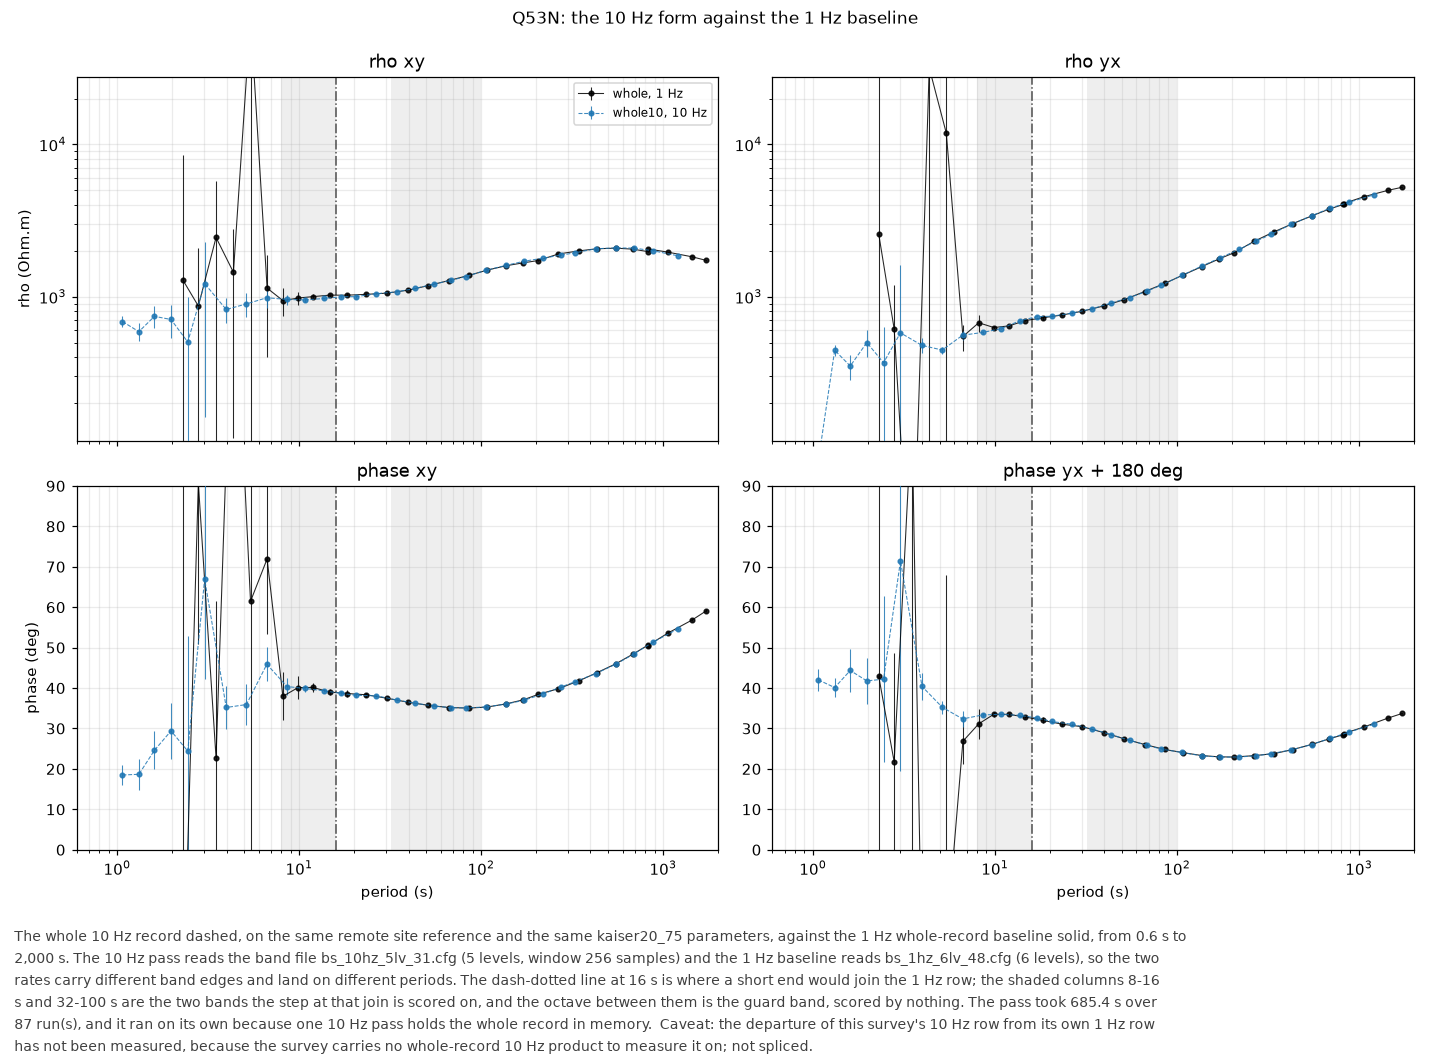

In [36]:
rows = rows_by_form()
curves = [("whole, 1 Hz", read(BASE), "k", "-")] if BASE else []
r = made_product("whole10")
if r:
    curves.append(("whole10, 10 Hz", read(r["product"]), "C0", "--"))
if len(curves) > 1:
    _bs = AR.bands_for(10)
    _k10 = rows.get("whole10", {}).get("kind", BASELINE_KIND)
    _cost = "%s s over %s run(s)" % (rows.get("whole10", {}).get("seconds"),
                                     rows.get("whole10", {}).get("n_runs"))
    # a form the floor refused carries its sentence where its curve would have been
    _gone = " ".join("%s is not drawn -- %s." % (n, w) for n, w in REFUSED)
    fig = FF.rate_panels(curves, SITE, OUT / "19_rates.png", join_s=SP.SPLICE_JOIN_S,
                         bands=(SP.STEP_BELOW, SP.STEP_ABOVE), period_range=(SP.SHORT_FLOOR_S, 2000),
                         title="%s: the 10 Hz form against the 1 Hz baseline" % SITE,
                         caption="The whole 10 Hz record dashed, on the same %s reference and the same %s "
                                 "parameters, against the 1 Hz whole-record baseline solid, from %g s to "
                                 "2,000 s. The 10 Hz pass reads the band file %s (%d levels, window %d "
                                 "samples) and the 1 Hz baseline reads %s (%d levels), so the two rates "
                                 "carry different band edges and land on different periods. The dash-dotted "
                                 "line at %g s is where a short end would join the 1 Hz row; the shaded "
                                 "columns %g-%g s and %g-%g s are the two bands the step at that join is "
                                 "scored on, and the octave between them is the guard band, scored by "
                                 "nothing. The pass took %s, and it ran on its own because one 10 Hz pass "
                                 "holds the whole record in memory. %s Caveat: %s."
                                 % (KIND_WORD.get(_k10, _k10), PARAMS, SP.SHORT_FLOOR_S,
                                    _bs.file.name, _bs.levels, _bs.window,
                                    AR.bands_for(1).file.name, AR.bands_for(1).levels,
                                    SP.SPLICE_JOIN_S, SP.STEP_BELOW[0], SP.STEP_BELOW[1],
                                    SP.STEP_ABOVE[0], SP.STEP_ABOVE[1], _cost, _gone, TEN_HZ_CAVEAT))
    WRITTEN.append(OUT / "19_rates.png")
    display(Image(filename=str(OUT / "19_rates.png")))
else:
    print("no 10 Hz form was made, so there is nothing to draw against the 1 Hz baseline")


In [37]:
# a form that ended in an exception is a FAIL with the form named; a form the floor refused, with its
# runs and its days measured before the pass, is a reading and is not one
fail = ["the form %s ended in an exception rather than a stated refusal: %s"
        % (r["form"], str(r.get("error"))[:160])
        for r in FORM_ROWS if r.get("rate_hz") == 10.0 and r.get("status") == "FAILED"]
refused_text = "; ".join("%s %s" % (n, w) for n, w in REFUSED)
made10 = [r["form"] for r in FORM_ROWS if r.get("rate_hz") == 10.0 and r.get("status") in ("made", "exists")]
if fail:
    print("VERDICT: FAIL -- %s%s" % ("; ".join(fail), ("; " + refused_text) if refused_text else ""))
elif not made10 and not REFUSED:
    print("VERDICT: UNJUDGED -- no form of this section was reached, so nothing was scored")
else:
    print("VERDICT: PASS -- no form of this section ended in an exception: %s"
          % ("; ".join("%s was made" % n for n in made10) if made10 else "none was made",))
    if refused_text:
        print("   as a reading, %s" % refused_text)


VERDICT: PASS -- no form of this section ended in an exception: whole10 was made


## 8. Replacement magnetics and the lender

At long period the horizontal magnetic field is homogeneous over the site spacing, so a neighbour's H
measures the same field; at short period it is not. A borrowed long end therefore goes under the site's own
short periods and the two are spliced where borrowing stops costing.

The rule picks the worse channel only, and only where it is clearly worse than the other: a site
decorrelated from its neighbours for any reason -- distance, a quiet spell, its own noise -- has both
channels below any threshold, so a rule reading "any channel below a threshold" replaces both and wrecks the
site. The coherence is the whole-record mean over 100-1000 s, deliberately not the chunk median used
elsewhere, and both series are despiked first, because a whole-record mean has no median to hide behind and
one logger spike sets the number. The candidate must itself be sound against a third site at 0.80: a donor
vouched for by the site it stands in for has been vouched for by nobody. A donor that is a member of the
reference the pass reads is refused, because a reference sharing a channel with the local H is comparing a
channel with itself.

Four forms. A is the site's own H, the baseline of section 1. B replaces one channel with the nearest sound
site's same channel and keeps the site's own other channel. C replaces it with the fleet stack's channel and
is shown and never delivered, because a stack is a reference and never a local H; its pass reads the
observatory, since every member of the stack is inside its own local H. D borrows the whole pair: the tensor
of the site's E on the field a neighbour measured, which is an inter-site impedance, shown and never
delivered. D and the lender form are one construction and one pass.

The frames. The lender's pair is served in its own mean-field frame and is turned by minus the site's angle
into the site's sensor frame before it stands in for a sensor-frame channel; the tensor is then turned back
on the right by M R(-t), with M's row taken from the identity where the channel is borrowed and from R(t)
where it is the site's own. With both channels borrowed that is the rotation R(-t); with neither it is the
identity; with one of each it is not a rotation at all.

**This check fails if a delivered form borrows both horizontal channels, if a replacement is not turned into
the site's frame (the read-back identity of the basis correction), or if the lender is a member of the
reference the pass reads.**

the remote site reference this pass reads is built from Q63, and those sites cannot lend
the site's frame angle is -0.2851 deg
site candidate      km  coverage third_site  own_Hx_coh  donor_Hx_coh  own_Hy_coh  donor_Hy_coh worst_channel  pair_score  donor_sound  rule_fires  covers                                                                                                                                    reason
Q53N      Q52N  88.836     0.998     Q76ALT       0.762         0.645       0.896         0.568            Hx       0.762        False       False    True own Hx 0.76 over 100-1000 s, not below 0.50 (0.85 of the other channel's 0.90); donor against its best third site Q76ALT 0.64, below 0.80
Q53N      Q64N 110.241     0.918       Q52N       0.001         0.002       0.001         0.003            Hx       0.001        False       False   False       own Hx 0.00 over 100-1000 s, below 0.50 (0.89 of the other channel's 0.00); donor against its best third site Q52N 0.00, below

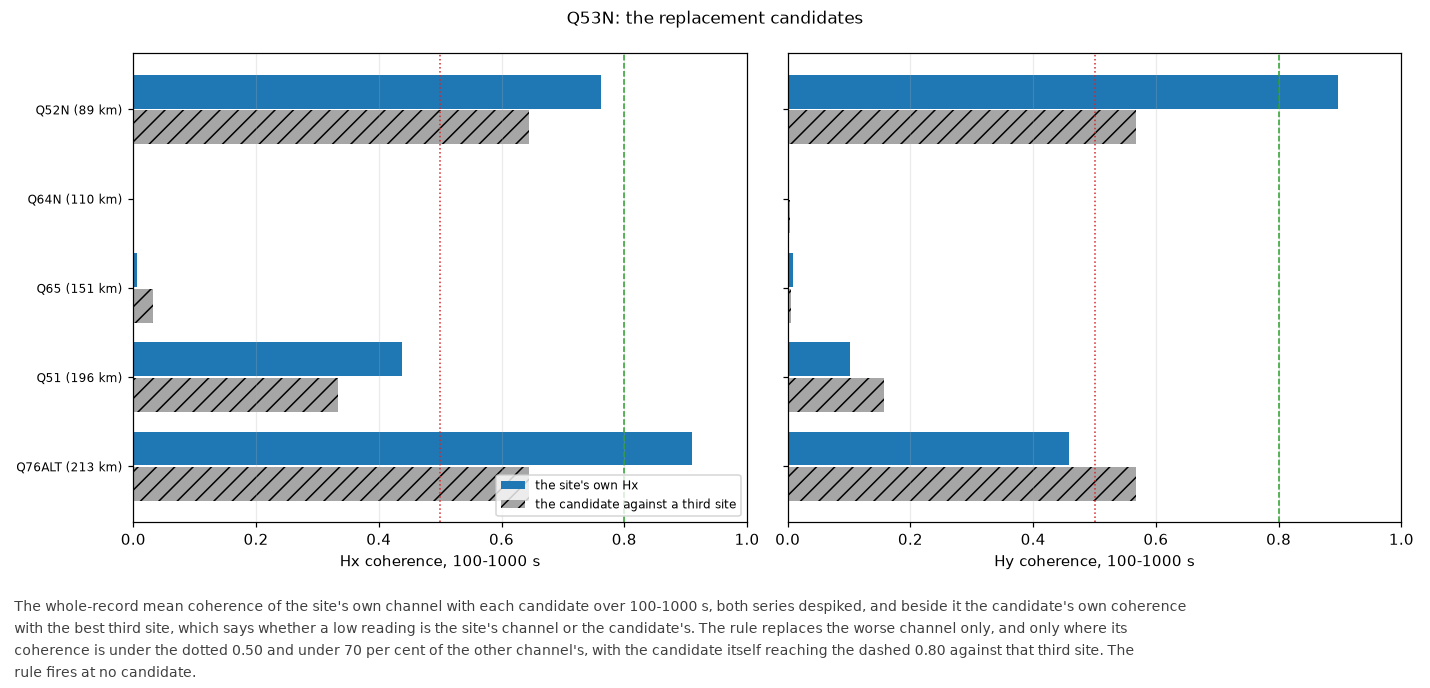

In [38]:
t = time.time()
_t0r, _hr, ANGLE, _nr = RP.rotated_pair(sv, SITE, 1)
ANGLE = FM.mean_angle(ANGLE)
try:
    _a, _b, _c, REF_INFO = REF.load_reference(BASELINE_KIND, SITE, 1, WORK)
except Exception as exc:
    REF_INFO = {}
    print("no %s reference sidecar: %s" % (BASELINE_KIND, str(exc)[:110]))
IN_REF = RP.reference_members(REF_INFO)
CANDS = RP.candidates(sv, SITE, donors=SITES, max_donors=5, exclude=IN_REF)
print("the %s reference this pass reads is built from %s, and those sites cannot lend"
      % (KIND_WORD.get(BASELINE_KIND, BASELINE_KIND), ", ".join(IN_REF) or "nothing"))
print("the site's frame angle is %+.4f deg" % ANGLE)
print(CANDS.round(3).to_string(index=False) if len(CANDS)
      else "no candidate covers %g days of the record" % RP.MIN_OVERLAP_DAYS)
print("(the candidates table took %.0f s)" % (time.time() - t))
fig = FF.candidate_bars(CANDS, SITE, OUT / "23_candidates.png", threshold=RP.SUB_THRESHOLD,
                        donor_gate=RP.DONOR_GATE)
WRITTEN.append(OUT / "23_candidates.png")
display(Image(filename=str(OUT / "23_candidates.png")))


In [39]:
CHAN, LEND = REPLACE_CHANNEL, LENDER
if len(CANDS):
    if CHAN is None:
        fired = CANDS[CANDS.rule_fires]
        CHAN = str((fired if len(fired) else CANDS).worst_channel.iloc[0])
    if LEND is None:
        ok = CANDS[CANDS.donor_sound] if CANDS.donor_sound.any() else CANDS
        LEND = str(ok.candidate.iloc[0])
NEEDED = bool(len(CANDS) and CANDS.rule_fires.any())
print("the substitution rule fires at %s: %s"
      % (SITE, "yes" if NEEDED else "no -- the site needs no replacement, and form B below is a "
         "demonstration on the channel the rule would pick"))
print("channel %s, lender %s%s" % (CHAN, LEND, "" if NEEDED else " (demonstration)"))


the substitution rule fires at Q53N: no -- the site needs no replacement, and form B below is a demonstration on the channel the rule would pick
channel Hx, lender Q52N (demonstration)


In [40]:
REPLACED = []
if LEND and CHAN:
    t0l, hl, _angl, _nl = RP.rotated_pair(sv, LEND, 1)
    lend_pair = RP.on_grid(hl, t0l, t0_rec, n_rec)
    _t0b, local_b, _ang_b, _ap, _un = FM.load_local(sv, SITE, 1)
    b = RP.replace_channel(local_b, lend_pair, CHAN, ANGLE)
    print("form B: %s" % b["note"])
    REPLACED.append(dict(name="replace_%s_%s" % (CHAN, LEND), spec=b, shown_only=False, lender=LEND,
                         kind=BASELINE_KIND,
                         why="scored per decade against the own-H baseline, the worst decade governing"))
    d = RP.replace_channel(local_b, lend_pair, CHAN, ANGLE, whole_pair=True)
    print("form D: %s" % d["note"])
    REPLACED.append(dict(name="lender_%s" % LEND, spec=d, shown_only=True, lender=LEND,
                         kind=BASELINE_KIND,
                         why="shown and never delivered: an inter-site impedance"))
    try:
        _st0, sh, smask, _si = REF.load_reference("stack", SITE, 1, WORK)
        stack_pair = {c: np.where(np.asarray(smask, bool)[:n_rec], np.asarray(sh[c], float)[:n_rec], np.nan)
                      for c in ("Hx", "Hy")}
        c_ = RP.replace_channel(local_b, stack_pair, CHAN, ANGLE)
        print("form C: %s, the channel taken from the fleet stack; its pass reads the observatory, because "
              "every member of the stack is inside its own local H" % c_["note"])
        REPLACED.append(dict(name="replace_%s_stack" % CHAN, spec=c_, shown_only=True, lender=None,
                             kind="obs",
                             why="shown and never delivered: a stack is a reference, never a local H"))
    except Exception as exc:
        print("form C: no fleet stack store for %s (%s)" % (SITE, str(exc)[:90]))
    del local_b, lend_pair
else:
    print("no candidate lender: no replacement form is built")


form B: Hx borrowed and turned into the site's sensor frame by R(+0.2851 deg); the site's own Hy kept in its mean-field frame; E and Hz own
form D: both horizontal channels borrowed and turned into the site's sensor frame by R(+0.2851 deg): the tensor of the site's E on the neighbour's field, an INTER-SITE IMPEDANCE, shown and never delivered


form C: Hx borrowed and turned into the site's sensor frame by R(+0.2851 deg); the site's own Hy kept in its mean-field frame; E and Hz own, the channel taken from the fleet stack; its pass reads the observatory, because every member of the stack is inside its own local H


In [41]:
for item in REPLACED:
    r = form(item["name"], kind=item["kind"], local_h=item["spec"]["arrays"],
             correction=item["spec"]["correction"], lender=item["lender"], criterion=item["why"],
             extra_lines=["h_replacement=%s" % item["spec"]["note"],
                          "h_basis_correction_is_a_rotation=%s" % item["spec"]["is_rotation"]])
    r["inter_site"] = bool(item["shown_only"] or item["spec"]["inter_site"])
    r["borrowed"] = "Hx+Hy" if all(item["spec"]["borrowed"]) else (CHAN or "")


In [42]:
rows = []
for item in REPLACED:
    r = made_product(item["name"])
    if r is None:
        rows.append(dict(form=item["name"],
                         error=str(rows_by_form().get(item["name"], {}).get("error"))[:110]))
        continue
    tf = read(r["product"])
    worst = ""
    if BASE:
        per = AG.per_decade(read(BASE), tf, bands=[tuple(b) for b in DECADES])
        p = per[np.isfinite(per.rho_ratio)]
        if len(p):
            k = int(np.nanargmax(np.abs(np.log10(p.rho_ratio.values))))
            worst = "%s %s %.2f, %+.1f deg" % (p.band.iloc[k], p.component.iloc[k], p.rho_ratio.iloc[k],
                                               p.phase_diff_deg.iloc[k])
    rows.append(dict(form=item["name"], kind=item["kind"], borrowed=r.get("borrowed"),
                     delivered=not r.get("inter_site"), bar_xy=DL.bar(tf, "xy", *BAR_BAND),
                     bar_yx=DL.bar(tf, "yx", *BAR_BAND), worst_decade_against_A=worst,
                     correction_reads_back=(r.get("turn") or {}).get("ok"),
                     correction_element=(r.get("turn") or {}).get("max_element_rel")))
print(pd.DataFrame(rows).round(4).to_string(index=False) if rows else "no replacement form was built")


            form   kind borrowed  delivered  bar_xy  bar_yx         worst_decade_against_A  correction_reads_back  correction_element
 replace_Hx_Q52N remote       Hx       True  0.0025  0.0019     10-100 s xy 0.76, -3.4 deg                   True                 0.0
     lender_Q52N remote    Hx+Hy      False  0.0067  0.0032      5-10 s xy 0.65, -46.5 deg                   True                 0.0
replace_Hx_stack    obs       Hx      False  0.0025  0.0040 1000-10000 s xy 0.64, +2.8 deg                   True                 0.0


Forms A to D on one set of panels: A the own-H baseline in black, B the single borrowed channel,
C the stack's channel and D the whole borrowed pair, the two shown-only forms drawn dashed. What to look for
is B following A while D sits off it: a single borrowed channel is a measurement of the same field, and a
whole borrowed pair is the inter-site impedance, which is a different quantity and is never delivered.

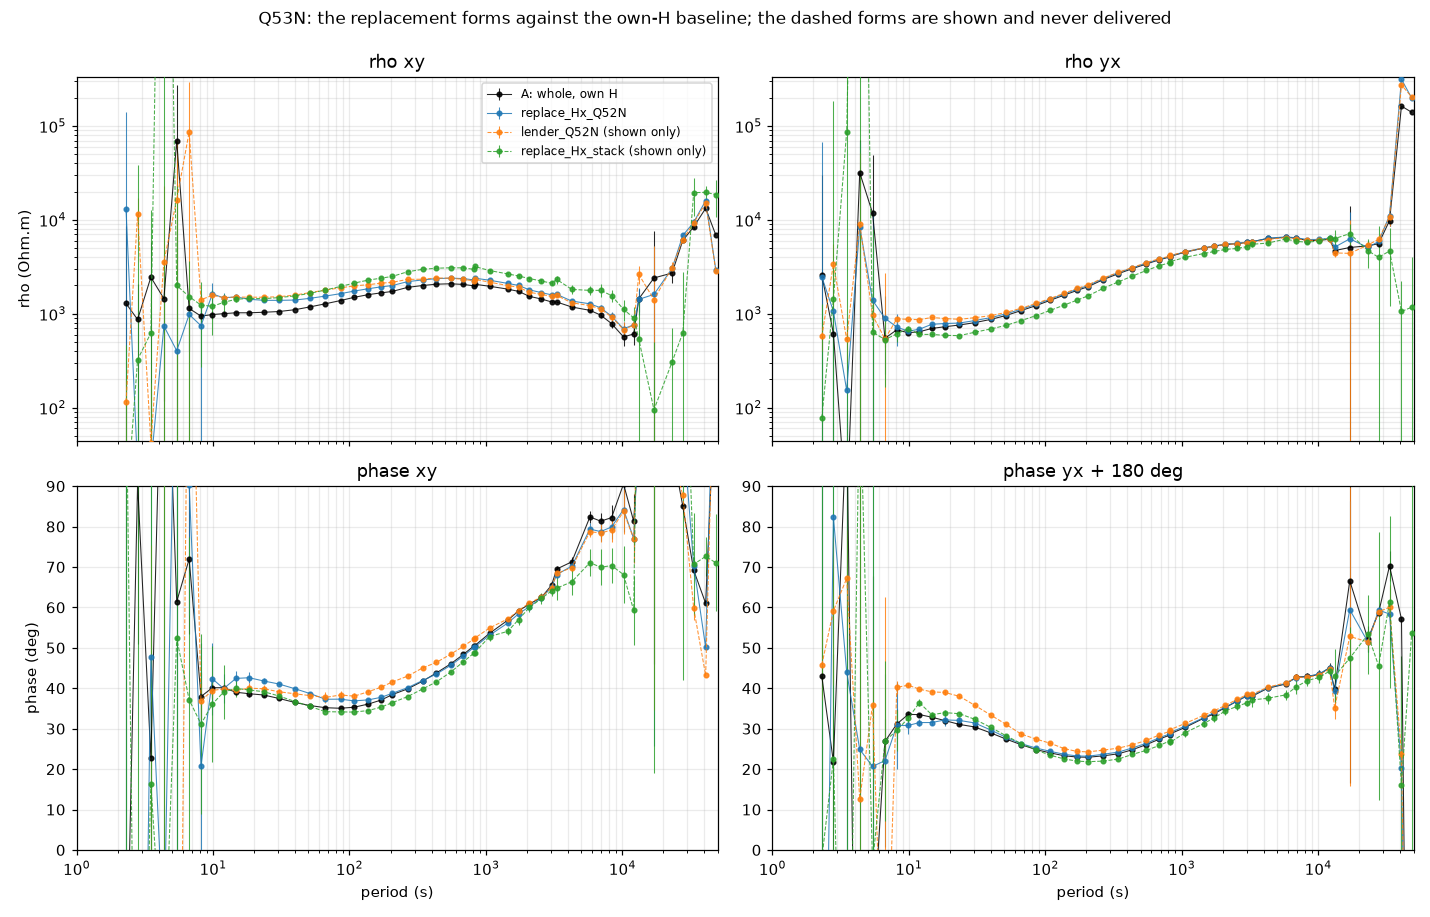

In [43]:
curves = [("A: whole, own H", read(BASE), "k", "-")] if BASE else []
for j, item in enumerate(REPLACED):
    r = made_product(item["name"])
    if r:
        curves.append(("%s%s" % (item["name"], " (shown only)" if item["shown_only"] else ""),
                       read(r["product"]), "C%d" % j, "--" if item["shown_only"] else "-"))
if len(curves) > 1:
    fig = FF.form_panels(curves, SITE, OUT / "22_forms_abcd.png",
                         title="%s: the replacement forms against the own-H baseline; the dashed forms are "
                               "shown and never delivered" % SITE, period_range=(1, 50000))
    WRITTEN.append(OUT / "22_forms_abcd.png")
    display(Image(filename=str(OUT / "22_forms_abcd.png")))
else:
    print("no replacement form was built, so there is nothing to draw against the baseline")


In [44]:
SPLICE = {}
b_name = "replace_%s_%s" % (CHAN, LEND) if (CHAN and LEND) else ""
r = made_product(b_name) if b_name else None
if BASE and r:
    a, b = read(BASE), read(r["product"])
    bg = AG.on_grid(a, b)
    for comp in ("xy", "yx"):
        ra, _ea, pa, _fa = PR.rho_phase(a.period, a.z, a.z_err, comp)
        rb, _eb, pb, _fb = PR.rho_phase(a.period, bg.z, bg.z_err, comp)
        SPLICE[comp] = RP.splice_period(a.period, rb, pb, ra, pa)
    print("the period from which the borrowed row stops costing, read against the own-H baseline:")
    for comp, s in SPLICE.items():
        print("   %s: t_c %s s over %d tested period(s), %.0f %% agreeing -- %s"
              % (comp, ("%.0f" % s["t_c"]) if np.isfinite(s["t_c"]) else "none", s["n_tested"],
                 100 * s["frac_agree"], s["rule"]))
    print("   below t_c the site's own short periods are kept and above it the borrowed row is delivered; a "
          "form with no t_c has no defensible splice and is not merged")
else:
    print("no single-channel replacement product to splice")


the period from which the borrowed row stops costing, read against the own-H baseline:
   xy: t_c none s over 25 tested period(s), 0 % agreeing -- within 5 % in rho and 5 deg in phase OR within 2 combined sigma, held to 3000 s
   yx: t_c 40 s over 25 tested period(s), 84 % agreeing -- within 5 % in rho and 5 deg in phase OR within 2 combined sigma, held to 3000 s
   below t_c the site's own short periods are kept and above it the borrowed row is delivered; a form with no t_c has no defensible splice and is not merged


In [45]:
fail = []
for item in REPLACED:
    r = rows_by_form().get(item["name"], {})
    if r.get("status") not in ("made", "exists"):
        if "lender" in str(r.get("error") or ""):
            fail.append("%s: %s" % (item["name"], r["error"]))
        continue
    if all(item["spec"]["borrowed"]) and not r.get("inter_site"):
        fail.append("%s borrows both horizontal channels and is not labelled an inter-site impedance"
                    % item["name"])
    t = r.get("turn") or {}
    if t and not t.get("ok"):
        fail.append("%s: the basis correction does not read back (elements %.2e, determinant %.2e)"
                    % (item["name"], t.get("max_element_rel", np.nan), t.get("max_det_scaled", np.nan)))
    if item["lender"] and item["lender"] in IN_REF:
        fail.append("the lender %s is a member of the %s reference %s reads"
                    % (item["lender"], item["kind"], item["name"]))
if not REPLACED:
    print("VERDICT: UNJUDGED -- no candidate lender was found, so no form was built and nothing was scored")
elif fail:
    print("VERDICT: FAIL -- %s" % "; ".join(fail))
else:
    print("VERDICT: PASS -- %d form(s) built; the lender %s is not a member of the %s reference (%s); every "
          "whole-pair form is labelled an inter-site impedance and is not delivered (%s); and every basis "
          "correction reads back to better than 1e-6 on the elements"
          % (len(REPLACED), LEND, BASELINE_KIND, ", ".join(IN_REF) or "no member",
             ", ".join(i["name"] for i in REPLACED if all(i["spec"]["borrowed"])) or "none built"))


VERDICT: PASS -- 3 form(s) built; the lender Q52N is not a member of the remote reference (Q63); every whole-pair form is labelled an inter-site impedance and is not delivered (lender_Q52N); and every basis correction reads back to better than 1e-6 on the elements


## 9. The tipper-only delivery

The tipper is an H-only quantity and survives two dead electric lines, so a site with no deliverable
impedance can still deliver its tipper. The impedance rows are written as the empty-data fill and two INFO
lines say what the file is, so a reader cannot take the blank rows for a measurement.

The tipper is refused where the vertical channel is not measuring the vertical field, and neither fault is
visible in the tipper itself: Hz a copy of a horizontal channel, which reads a coherence of 1.00 with Hx and
makes the tipper a re-statement of the horizontal record, or a leak, where Hz carries the site's own
horizontal field at 1000-4000 s while carrying nothing of a neighbour's vertical field. A real vertical field
is coherent with a neighbour's at those periods, because the source is regional.

This section is a reading and not a check: it applies where both lines are dead, or on demand.

In [46]:
TIP = DL.tipper_refusal(sv, SITE)
print("Hz with its own Hx %.3f (a copy at or above %.2f); with its own H %.3f (a leak at or above %.2f) "
      "while with %s's Hz %.3f (under %.2f)"
      % (TIP.get("coh_hz_hx", np.nan), DL.COPY_COH, TIP.get("coh_hz_own_h", np.nan), DL.LEAK_OWN_COH,
         TIP.get("neighbour"), TIP.get("coh_hz_neighbour_hz", np.nan), DL.LEAK_NEIGHBOUR_COH))
print("the refusal test: %s -- %s" % ("REFUSED" if TIP.get("refused") else "the tipper stands",
                                      TIP.get("reason")))
dead_lines = [c for c in COMPONENTS
              if len(ELINES) and (ELINES["%s_state" % LINE[c]] == "dead").mean() > 0.5]
if BASE and (len(dead_lines) == len(COMPONENTS) or TIP.get("refused")):
    out = OUT / FM.product_name(SITE, "tipper_only", BASELINE_KIND, 1, PARAMS)
    got = DL.tipper_only(BASE, out, KIND_WORD.get(BASELINE_KIND, BASELINE_KIND), TIP)
    print(got)
    if got.get("written"):
        FORM_ROWS.append(dict(site=SITE, form="tipper_only", kind=BASELINE_KIND, rate_hz=1.0, params=PARAMS,
                              product=str(out), controls="", seed=None, status="made",
                              criterion="an H-only delivery; the impedance rows carry no product of record",
                              error="", days=None, n_runs=None, seconds=None))
else:
    print("neither line is dead on most days (%s) and the tipper is not refused, so the tipper-only "
          "delivery does not apply here: the tipper ships inside the impedance products"
          % (", ".join(dead_lines) or "no line dead"))


Hz with its own Hx 0.528 (a copy at or above 0.99); with its own H 0.566 (a leak at or above 0.95) while with Q52N's Hz nan (under 0.10)
the refusal test: the tipper stands -- neither fault fires
neither line is dead on most days (no line dead) and the tipper is not refused, so the tipper-only delivery does not apply here: the tipper ships inside the impedance products


## 10. The recipe

The sections above each change one thing and score it. This one composes them: a frame for the product and,
per impedance row, which hours that row is estimated on and at which sample rate. One row can come from the
whole record at 1 Hz and the other from a short window at 10 Hz, and the two are assembled into one tensor.

The cell below is the one to edit. `frame` is the frame both rows are passed in, so nothing is turned after
the assembly: `native` is the site's own sensor frame after the mean-field rotation, `diagonal` is section
6's arm diagonal. `hours` of a row is one of

| hours | what it selects |
|---|---|
| `whole` | the record |
| `f05`, `f10`, `f25` | workbook 03's hour selections (`process.selection`), scored on this frame's cache at this row's rate over 1-30 s, each carrying its `r25` control |
| `window:coherent` | the longest contiguous stretch in which both recorded lines read above `WINDOW_COH` with the magnetic field each couples to -- Ex with Hy, Ey with Hx -- over 20-200 s, per whole UTC hour |
| `window:<start UTC>/<hours>` | a stretch named in the cell, as an ISO UTC start and a count of hours |

The window is read on the two recorded lines -- Ex and Ey from the site's own 1 Hz cache as laid -- and never
on the frame's variant of them, whatever frame the rows are passed in: the window exists to find where both
electrodes were measuring, which is a fact about the electrodes and not about the frame their voltages are
later combined in. It is read at 1 Hz whatever a row's rate, because 200 s is measured on the long record.
Every window and every selection carries a control at the same cost: a stretch of the same length placed at
random elsewhere in the record under the seed, or the `r25` draw of the same number of hours.

A row at 10 Hz needs the 10 Hz cache of the site, the frame's variant of that cache, and the reference store
of BASELINE_KIND at 10 Hz, which is the remote's own 10 Hz record on this site's grid. Where one of the three
is not on disk the row is refused with the reason and no pass is run, by the rule of section 7: the single
station is not a kind of this package, so a missing store is not fallen back from.

The assembly. The x row supplies Zx'x' and Zx'y' and the y row Zy'x' and Zy'y'. The x row's product is the
base, so its period grid, its station block and its position carry through, and the y row is matched onto
that grid where the two grids are one and interpolated in log period onto it where they are not. A period the
y row's own grid does not reach carries the EDI empty-data value 1e32, which `products.read_tf` masks per
component, so the assembled file reads back with that row empty above the y row's longest period rather than
carrying a number nothing measured. A y row at 10 Hz reaches below the x row's shortest period, and those
periods are not carried either: one file holds one grid, and the grid is the x row's. The tipper is the named
row's. The header carries one `recipe=` line per row with the frame, the hours, the rate, the window and the
control's seed.

Where a row asks for what a section above has already built -- the whole record at 1 Hz in the native frame
is the baseline, and in the diagonal frame it is section 6's `diagonal` form -- that product is taken and no
second pass of the same specification is run.

What this composes at AusLAMP Queensland Phase 2's Q58N, whose two lines share a noisy centre electrode: the
x' row and the tipper from the arm diagonal over the whole record at 1 Hz, and the y' row from both recorded
lines over the 14 h the window rule finds, at 10 Hz against the same remote. That is the composition the
campaign reached by hand for this site, and check 1 below scores the rule written here against the window it
used, recorded in `survey.yaml`. At the shipped Q53N the recipe is frame native with both rows the whole
record at 1 Hz, which is the baseline itself and buys nothing: the section is there to be edited.

In [47]:
# ---- the recipe: one composition of the sections above, one row at a time ----
RECIPE = dict(frame="native", x=dict(hours="whole", rate=1), y=dict(hours="whole", rate=1), tipper="x")
# frame     native | diagonal (section 6's arm diagonal); both rows are passed in it
# x, y      the x' and y' rows (x and y where the frame is native). hours is
#           whole | f05 | f10 | f25 | window:coherent | window:<start UTC>/<hours>; rate is 1 or 10
# tipper    which row's pass the tipper is taken from: x | y
WINDOW_COH = 0.5   # <- both recorded lines above this at 20-200 s, per whole UTC hour, is inside a window


The frame, the variant cache each rate needs, the window the rule finds, and what each row
resolves to. The five longest coherent stretches are printed beside the one chosen, so the margin between the
longest and the next is visible: a rule that picks a 14 h stretch over an 11 h one is a different claim from
one that picks 14 h over 3 h.

In [48]:
FRAME = RC.frame_spec(sv, SITE, RECIPE["frame"])
RATES_USED = sorted({int(RECIPE[k].get("rate", 1)) for k in ("x", "y")})
print("frame        %s -- %s" % (FRAME["frame"], FRAME["note"]))
print("rows         x': %s at %g Hz; y': %s at %g Hz; the tipper from the %s row"
      % (RECIPE["x"]["hours"], RECIPE["x"]["rate"], RECIPE["y"]["hours"], RECIPE["y"]["rate"],
         RECIPE["tipper"]))
NE_CACHE = {}
for _r in RATES_USED:
    if FRAME["variant"] == "ne" and (FM.cache_dir(WORK, _r) / ("%s.npz" % SITE)).exists():
        _t = time.time()
        NE_CACHE[_r] = CE.ne_variant(sv, SITE, _r, force=REDO)
        print("   the %d Hz arm-diagonal cache in %.0f s: %s (%s; exact on %s finite sample(s): %s)"
              % (_r, time.time() - _t, NE_CACHE[_r].get("path"),
                 "rewritten at these arm lengths" if NE_CACHE[_r].get("refreshed") else
                 "written" if NE_CACHE[_r].get("written") else "already on disk and checked again",
                 NE_CACHE[_r].get("n_finite"), NE_CACHE[_r].get("exact")))
t = time.time()
COH_HOURS = RC.hour_coherence(sv, SITE, RC.WINDOW_RATE)
COHERENT = RC.coherent_window(COH_HOURS, WINDOW_COH)
print()
print("the window rule over %d whole UTC hour(s) of the %g Hz record in %.0f s"
      % (len(COH_HOURS), RC.WINDOW_RATE, time.time() - t))
print("   %s" % COHERENT["reason"])
for _h, _a, _b in COHERENT["runs"][:5]:
    print("   %4d h  %s .. %s UTC" % (_h, pd.Timestamp(_a, unit="s"), pd.Timestamp(_b, unit="s")))


frame        native -- the site's own sensor frame after the mean-field rotation
rows         x': whole at 1 Hz; y': whole at 1 Hz; the tipper from the x row



the window rule over 1464 whole UTC hour(s) of the 1 Hz record in 3 s
   the longest contiguous stretch with both recorded lines above 0.50 over 20-200 s: 10 h, 2025-10-13 09:00 to 2025-10-13 19:00 UTC, of 331 hour(s) above on 1464 scored
     10 h  2025-10-13 09:00:00 .. 2025-10-13 19:00:00 UTC
     10 h  2025-10-18 15:00:00 .. 2025-10-19 01:00:00 UTC
     10 h  2025-10-19 09:00:00 .. 2025-10-19 19:00:00 UTC
     10 h  2025-11-10 09:00:00 .. 2025-11-10 19:00:00 UTC
      7 h  2025-09-30 13:00:00 .. 2025-09-30 20:00:00 UTC


In [49]:
ROWS = {}
for key in ("x", "y"):
    spec = RECIPE[key]
    hours, rate = str(spec.get("hours", "whole")), int(spec.get("rate", 1))
    row = dict(row=key, hours=hours, rate=rate, seed=SEED + (0 if key == "x" else 1), window=None,
               control_window=None, keep=None, control_keep=None, control=None, selection=None,
               spans=[], control_spans=[], keep_name="the record", control_keep_name="", reuse="",
               product="", refused=RC.missing_inputs(sv, SITE, rate, FRAME["variant"], BASELINE_KIND))
    if not row["refused"] and hours.startswith("window"):
        w = COHERENT if hours == "window:coherent" else RC.named_window(hours)
        days = ((w["t_end"] - w["t_start"]) / 86400.0) if w.get("t_start") else 0.0
        if not w.get("t_start"):
            row["refused"] = "refused: %s" % w["reason"]
        elif days < FM.min_window_days(sv):
            row["refused"] = ("refused: the window is %.2f d, under the %g d floor in survey.yaml"
                              % (days, FM.min_window_days(sv)))
        else:
            c = RC.control_window(t0_rec, n_rec, w, row["seed"])
            row.update(window=w, control_window=c, control="recipe_%s_control" % key,
                       spans=[(w["t_start"], w["t_end"])], control_spans=[(c["t_start"], c["t_end"])],
                       keep_name="%s, %.2f h" % (hours, (w["t_end"] - w["t_start"]) / 3600.0),
                       control_keep_name="a stretch of the same length elsewhere in the record, seed %d"
                                         % row["seed"])
    elif not row["refused"] and hours in RC.SELECTION_KEYS:
        sel = RC.selection_hours(sv, SITE, hours, rate=rate, variant=FRAME["variant"], seed=SEED,
                                 elines=ELINES)
        row.update(selection=sel, keep=sel[hours]["keep"], control_keep=sel[RC.CONTROL_KEY]["keep"],
                   control="recipe_%s_control" % key,
                   spans=[tuple(x) for x in sel[hours]["hours"]],
                   control_spans=[tuple(x) for x in sel[RC.CONTROL_KEY]["hours"]],
                   keep_name="the best %.0f %% of %d scored hour(s) by %g-%g s coherence"
                             % (100 * sel[hours]["fraction"], sel["scored"], sel["band_s"][0],
                                sel["band_s"][1]),
                   control_keep_name="%d hour(s) drawn at random from the same pool, seed %d"
                                     % (sel[RC.CONTROL_KEY]["n_hours"], SEED))
    elif not row["refused"] and hours != "whole":
        row["refused"] = ("refused: hours=%s is none of whole, %s, window:coherent or window:<start>/<hours>"
                          % (hours, ", ".join(RC.SELECTION_KEYS)))
    if hours == "whole":
        row["spans"] = [(t0_rec, t0_rec + int(n_rec))]
        reuse = {"native": "whole", "diagonal": "diagonal"}[FRAME["frame"]]
        got = made_product(reuse) if rate == 1 else None
        if got:
            row.update(reuse=reuse, product=str(got["product"]))
    ROWS[key] = row
cols = ["row", "hours", "rate", "seed", "window_start", "window_end", "days", "control_start", "control",
        "reuse", "refused"]
print(pd.DataFrame([dict(
    row="%s (%s)" % (r["row"], RC.ROW_LABEL[r["row"]]), hours=r["hours"], rate=r["rate"], seed=r["seed"],
    window_start=(pd.Timestamp(r["window"]["t_start"], unit="s") if r["window"] else ""),
    window_end=(pd.Timestamp(r["window"]["t_end"], unit="s") if r["window"] else ""),
    days=round(sum(b - a for a, b in r["spans"]) / 86400.0, 3),
    control_start=(pd.Timestamp(r["control_window"]["t_start"], unit="s") if r["control_window"] else ""),
    control=(r["control"] or ""), reuse=(r["reuse"] or ""), refused=r["refused"][:70])
    for r in ROWS.values()])[cols].to_string(index=False))
for r in ROWS.values():
    print("   %s: %s" % (r["row"], r["keep_name"]))


   row hours  rate     seed window_start window_end   days control_start control reuse refused
x (x') whole     1 20260916                         61.035                       whole        
y (y') whole     1 20260917                         61.035                       whole        
   x: the record
   y: the record


The two hourly coherence series the window rule reads, with each row's stretch drawn above them
and its control beneath it. What to look for is the chosen stretch sitting where both series are above the
line at the same time -- one line alone above it is not a window, because the second row needs both
electrodes -- and the control landing somewhere the two series are neither obviously better nor worse: the
two cost the same, so the difference between their products is what the stretch bought.

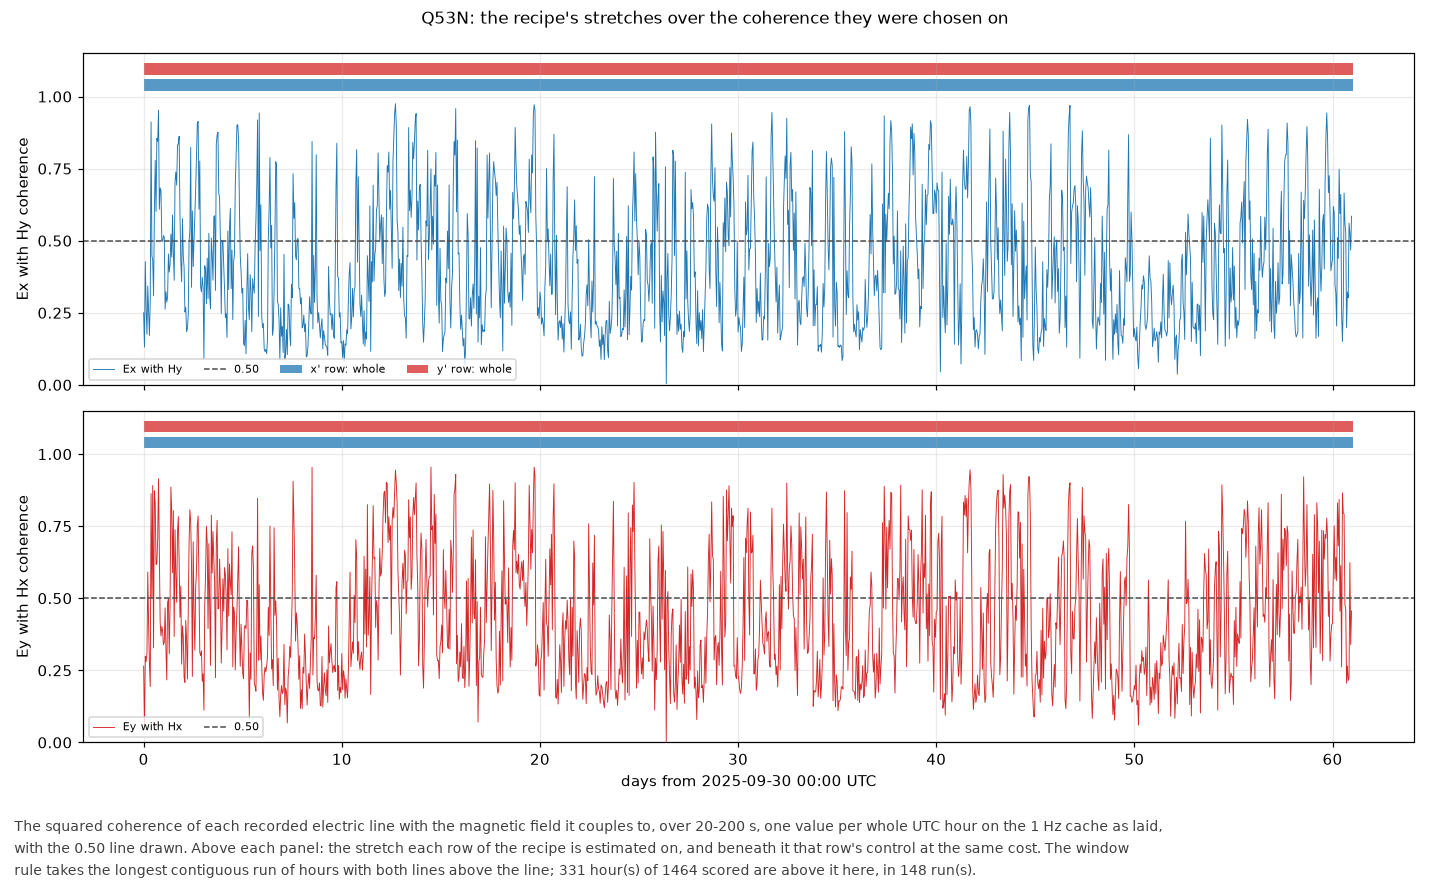

In [50]:
spans = []
for key in ("x", "y"):
    r = ROWS[key]
    spans.append(("%s row: %s" % (RC.ROW_LABEL[key], r["hours"]), FF.SPAN_COLOUR[RC.ROW_COMPONENT[key]],
                  None, r["spans"][:400]))
    if r["control_spans"]:
        spans.append(("%s control, seed %d" % (RC.ROW_LABEL[key], r["seed"]), "0.4", "//",
                      r["control_spans"][:400]))
fig = FF.recipe_spans(COH_HOURS, spans, SITE, OUT / "25_recipe_windows.png", coh_min=WINDOW_COH,
                      title="%s: the recipe's stretches over the coherence they were chosen on" % SITE,
                      caption="The squared coherence of each recorded electric line with the magnetic field "
                              "it couples to, over %g-%g s, one value per whole UTC hour on the %g Hz cache "
                              "as laid, with the %.2f line drawn. Above each panel: the stretch each row of "
                              "the recipe is estimated on, and beneath it that row's control at the same "
                              "cost. The window rule takes the longest contiguous run of hours with both "
                              "lines above the line; %d hour(s) of %d scored are above it here, in %d run(s)."
                              % (RC.WINDOW_BAND_S[0], RC.WINDOW_BAND_S[1], RC.WINDOW_RATE, WINDOW_COH,
                                 COHERENT["n_hours_above"], COHERENT["n_hours_scored"], COHERENT["n_runs"]))
WRITTEN.append(OUT / "25_recipe_windows.png")
display(Image(filename=str(OUT / "25_recipe_windows.png")))


One pass per row and one per control, each measured against the reference before it is run: the
mask, the reference's own coverage and the record cut into runs at the 3,600 s floor. A row whose cache
leaves nothing is refused there with those numbers rather than crashing the estimator, and a row whose inputs
are not on disk was refused above. The assembled product is then written from the two rows.

In [51]:
for key in ("x", "y"):
    row = ROWS[key]
    name = "recipe_%s" % key
    crit = ("the %s row: %s at %g Hz in the %s frame"
            % (RC.ROW_LABEL[key], row["hours"], row["rate"], FRAME["frame"]))
    if row["refused"]:
        FORM_ROWS.append(FM.refused_row(sv, SITE, name, OUT, BASELINE_KIND, row["rate"], PARAMS,
                                        row["refused"],
                                        controls=([row["control"]] if row["control"] else []),
                                        criterion="not passed: " + crit))
        print("   %-20s is NOT passed -- %s" % (name, row["refused"]))
        continue
    if row["reuse"]:
        FORM_ROWS.append(dict(site=SITE, form=name, kind=BASELINE_KIND, rate_hz=float(row["rate"]),
                              params=PARAMS, product=row["product"], controls="", seed=None,
                              status="exists", days=None, n_runs=None, seconds=None, error="",
                              criterion=crit + "; the %s form's product, which is the same specification, "
                                               "and no second pass of it is run" % row["reuse"]))
        print("   %-20s takes the %s form's product: %s"
              % (name, row["reuse"], Path(row["product"]).name))
        continue
    jobs = [(name, row["window"], row["keep"], row["keep_name"], crit,
             [row["control"]] if row["control"] else [])]
    if row["control"]:
        jobs.append((row["control"], row["control_window"], row["control_keep"], row["control_keep_name"],
                     "the control of the %s row at the same cost" % RC.ROW_LABEL[key], []))
    for job_name, window, keep, keep_name, criterion, controls in jobs:
        extra = RC.window_mask(t0_rec, n_rec, window) if window else keep
        cov = FM.coverage(sv, SITE, kind=BASELINE_KIND, rate=row["rate"], variant=FRAME["variant"],
                          apply_e_signs=FRAME["apply_e_signs"], keep_extra=extra, keep_name=keep_name)
        print("   %-20s %6.2f d over %3d run(s) of the record's %.2f d, measured before the pass"
              % (job_name, cov["days"], cov["n_runs"], cov["record_days"]))
        if cov["empty"]:
            why = ("refused: %s leaves %d run(s) of %g s against the %s reference, of a record of %.2f d"
                   % (keep_name, cov["n_runs"], cov["min_segment_s"],
                      KIND_WORD.get(BASELINE_KIND, BASELINE_KIND), cov["record_days"]))
            FORM_ROWS.append(FM.refused_row(sv, SITE, job_name, OUT, BASELINE_KIND, row["rate"], PARAMS,
                                            why, cov=cov, controls=controls,
                                            criterion="not passed: the floor leaves no run to hand Aurora"))
            print("      NOT passed -- %s" % why)
            continue
        form(job_name, kind=BASELINE_KIND, rate=row["rate"], variant=FRAME["variant"],
             apply_e_signs=FRAME["apply_e_signs"], turn_ne=FRAME["turn_ne"],
             turn_angle_deg=FRAME["turn_angle_deg"],
             window=((window["t_start"], window["t_end"]) if window else None),
             keep_extra=(None if window else keep), keep_name=keep_name, seed=row["seed"],
             controls=controls, criterion=criterion,
             redo=bool(REDO or (NE_CACHE.get(row["rate"]) or {}).get("refreshed")),
             extra_lines=RC.recipe_lines(RECIPE, ROWS))


   recipe_x             takes the whole form's product: Q53N_whole_remote_1hz_kaiser20_75.edi
   recipe_y             takes the whole form's product: Q53N_whole_remote_1hz_kaiser20_75.edi


In [52]:
ASSEMBLED, ROW_READINGS = None, []
for key in ("x", "y"):
    r = made_product("recipe_%s" % key)
    if r is None:
        continue
    comp = RC.ROW_COMPONENT[key]
    ctrl_name = ROWS[key]["control"]
    ctrl = made_product(ctrl_name) if ctrl_name else None
    bar_row = DL.bar(read(r["product"]), comp, *BAR_BAND)
    bar_ctrl = DL.bar(read(ctrl["product"]), comp, *BAR_BAND) if ctrl else np.nan
    # each row on its own element and never on the product's bar, which is the better of the two rows and
    # would answer for the row a window was not chosen for
    ROW_READINGS.append(dict(row=RC.ROW_LABEL[key], form="recipe_%s" % key, element="Z%s" % comp,
                             hours=ROWS[key]["hours"], rate_hz=ROWS[key]["rate"], days=r.get("days"),
                             bar=bar_row, control=(ctrl_name or "none"), control_bar=bar_ctrl,
                             promoted=(DL.beats(bar_row, bar_ctrl, BAR_MARGIN)
                                       if np.isfinite(bar_ctrl) else None)))
rx, ry = made_product("recipe_x"), made_product("recipe_y")
if rx and ry:
    for key, r in (("x", rx), ("y", ry)):
        ROWS[key]["product"] = str(r["product"])
    out = OUT / FM.product_name(SITE, "recipe", BASELINE_KIND, ROWS["x"]["rate"], PARAMS)
    ASSEMBLED = RC.assemble(rx["product"], ry["product"], out, tipper=RECIPE["tipper"],
                            lines=RC.recipe_lines(RECIPE, ROWS))
    scored = [d for d in ROW_READINGS if d["promoted"] is not None]
    me = CENTRE.get(SITE, {})
    model_ok = True if FRAME["frame"] == "native" else bool(me.get("model_holds"))
    why = []
    # a recipe whose rows are all the whole record carries no control at all, so it carries no evidence of
    # its own and is read like every other form with no control: the vacuous "all of nothing was beaten" is
    # not a promotion
    if not scored:
        why.append("no row carries a control, because every row is the whole record, so the assembled "
                   "product carries no evidence of its own")
    elif not all(d["promoted"] for d in scored):
        why.append("the %s row does not beat its control on the %g-%g s bar of %s by %.0f %%"
                   % (", ".join(d["row"] for d in scored if not d["promoted"]), BAR_BAND[0], BAR_BAND[1],
                      ", ".join(d["element"] for d in scored if not d["promoted"]), 100 * BAR_MARGIN))
    if not model_ok:
        why.append("the shared-centre model does not hold at %s (residual coherence %.2f, gain ratio "
                   "%.2f), and the diagonal frame rests on it"
                   % (SITE, me.get("resid_coh", np.nan), me.get("gain_ratio", np.nan)))
    bars = "; ".join("%s %.4f against %.4f" % (d["row"], d["bar"], d["control_bar"]) for d in scored)
    frame_held = ("the shared-centre model holds at %s, which the diagonal frame rests on" % SITE
                  if FRAME["frame"] == "diagonal" else "the frame is the site's own")
    verdict = ("NOT a candidate: %s" % "; ".join(why)) if why else \
              ("a candidate: every row carrying a control beats it on the %g-%g s bar of its own element by "
               "at least %.0f %% (%s), and %s"
               % (BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN, bars, frame_held))
    FORM_ROWS.append(dict(site=SITE, form="recipe", kind=BASELINE_KIND,
                          rate_hz=float(ROWS["x"]["rate"]), params=PARAMS, product=str(out), controls="",
                          seed=None, status="made", days=None, n_runs=None, seconds=None, error="",
                          criterion="the %s frame: Zx'x' and Zx'y' from the x row, Zy'x' and Zy'y' from the "
                                    "y row, the tipper from the %s row"
                                    % (FRAME["frame"], RECIPE["tipper"]),
                          candidate_rule=dict(candidate=bool(not why), verdict=verdict)))
    WRITTEN.append(out)
    print("   the y row covers %d of %d period(s), %.4g to %.4g s; above that the row carries the %g fill"
          % (ASSEMBLED["n_y_periods"], ASSEMBLED["n_periods"], ASSEMBLED["y_min_s"], ASSEMBLED["y_max_s"],
             ASSEMBLED["fill"]))
    for ln in RC.recipe_lines(RECIPE, ROWS):
        print("   %s" % ln)
    print("   the assembled product is %s" % verdict)
else:
    print("no assembled product: the %s row was not made"
          % ", ".join(k for k in ("x", "y") if not made_product("recipe_%s" % k)))


   assembled Q53N_recipe_remote_1hz_kaiser20_75.edi: the two grids are one to 0.0e+00 relative; the y row covers 48 of 48 period(s)
   the y row covers 48 of 48 period(s), 2.303 to 4.847e+04 s; above that the row carries the 1e+32 fill
   recipe_frame=native
   recipe_x=hours=whole, rate=1 Hz, frame=native, window=none: the whole record, control=none, seed=20260916
   recipe_y=hours=whole, rate=1 Hz, frame=native, window=none: the whole record, control=none, seed=20260917
   recipe_tipper=from the x row's pass
   the assembled product is NOT a candidate: no row carries a control, because every row is the whole record, so the assembled product carries no evidence of its own


The assembled product against the whole-record baseline and against each row's control. What to
look for is the x' panels lying on the curve the row they came from drew, the y' panels stopping at the
dash-dotted line -- the longest period that row reaches, above which the file carries the empty value -- and
each control sitting off the row it controls by more than its error bars, which is what says the stretch was
worth choosing.

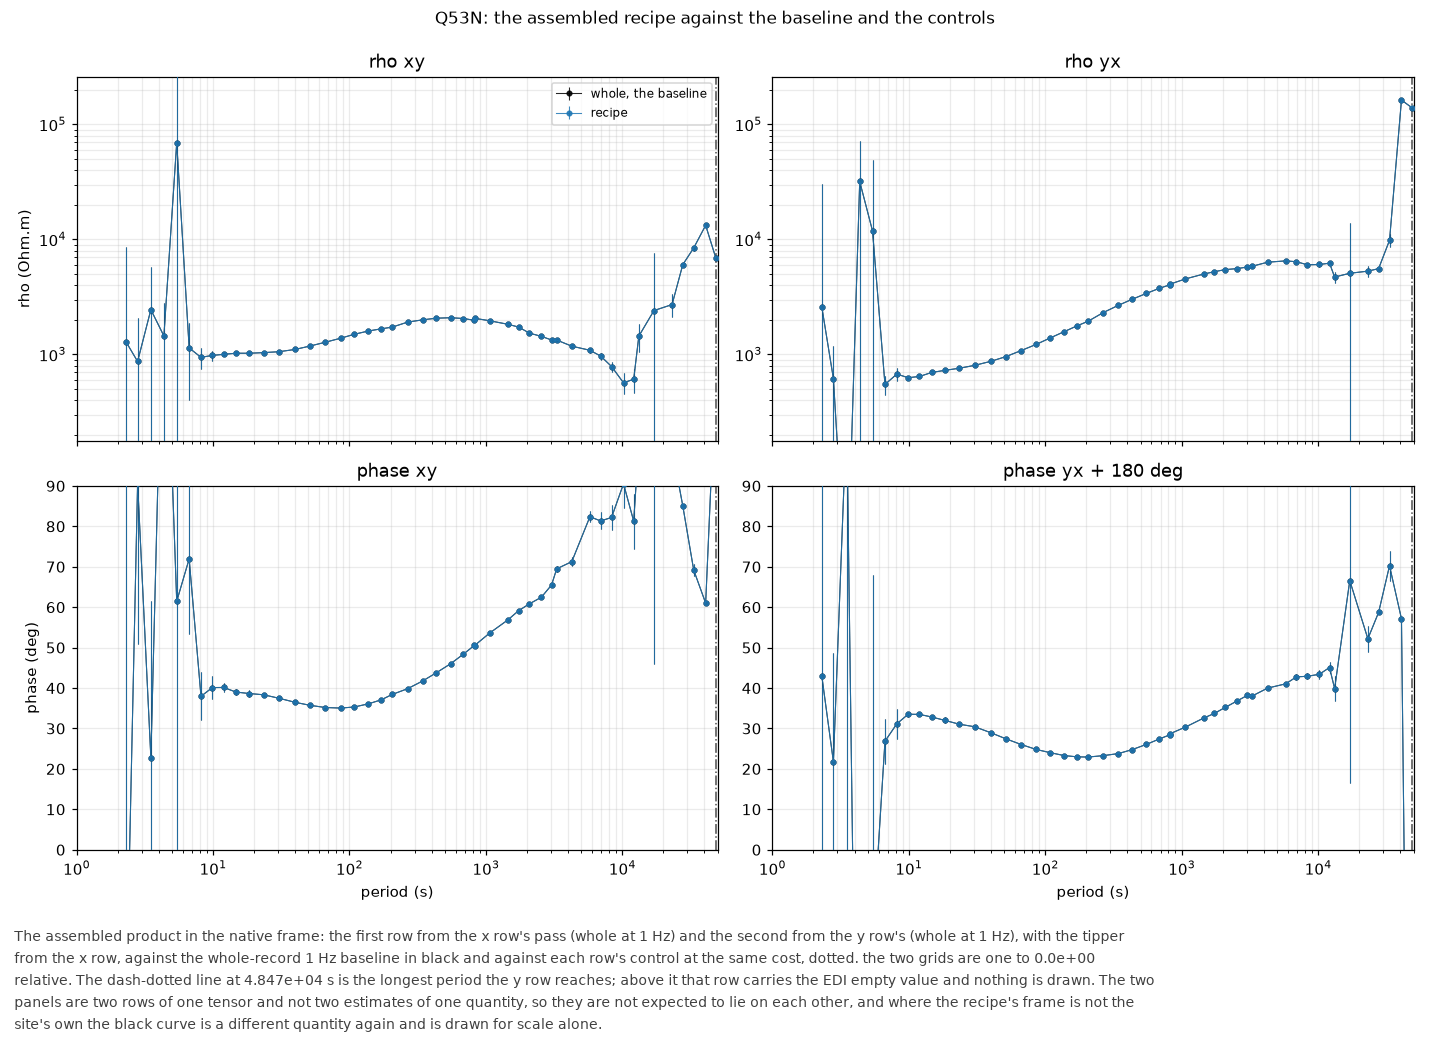

In [53]:
curves = [("whole, the baseline", read(BASE), "k", "-")] if BASE else []
if ASSEMBLED:
    curves.append(("recipe", read(ASSEMBLED["path"]), "C0", "-"))
for j, key in enumerate(("x", "y")):
    r = made_product("recipe_%s_control" % key)
    if r:
        curves.append(("%s control" % RC.ROW_LABEL[key], read(r["product"]), "C%d" % (j + 1), ":"))
if ASSEMBLED and len(curves) > 1:
    fig = FF.recipe_product(curves, SITE, OUT / "26_recipe_product.png",
                            join_s=ASSEMBLED["y_max_s"],
                            title="%s: the assembled recipe against the baseline and the controls" % SITE,
                            caption="The assembled product in the %s frame: the first row from the x row's "
                                    "pass (%s at %g Hz) and the second from the y row's (%s at %g Hz), with "
                                    "the tipper from the %s row, against the whole-record 1 Hz baseline in "
                                    "black and against each row's control at the same cost, dotted. %s. The "
                                    "dash-dotted line at %.4g s is the longest period the y row reaches; "
                                    "above it that row carries the EDI empty value and nothing is drawn. The "
                                    "two panels are two rows of one tensor and not two estimates of one "
                                    "quantity, so they are not expected to lie on each other, and where the "
                                    "recipe's frame is not the site's own the black curve is a different "
                                    "quantity again and is drawn for scale alone."
                                    % (FRAME["frame"], ROWS["x"]["hours"], ROWS["x"]["rate"],
                                       ROWS["y"]["hours"], ROWS["y"]["rate"], RECIPE["tipper"],
                                       ASSEMBLED["how"], ASSEMBLED["y_max_s"]))
    WRITTEN.append(OUT / "26_recipe_product.png")
    display(Image(filename=str(OUT / "26_recipe_product.png")))
else:
    print("no assembled product, so there is nothing to draw against the baseline")


**Where `survey.yaml` `checks.recipe_window` records a window for this site, this check fails if
the rule's window does not land within `tolerance_h` of it at each end.** The rule the package writes has to
reproduce the choice the campaign made by hand, and the only site where that comparison exists is Q58N of
AusLAMP Queensland Phase 2, whose recorded window is 2026-03-22 12:00 to 2026-03-23 02:00 UTC. Where no window
is on record the cell prints the one the rule found as a reading and writes no verdict.

In [54]:
want_all = (sv.cfg.get("checks") or {}).get("recipe_window") or {}
tol_h = float(want_all.get("tolerance_h", 1))
want = want_all.get(SITE) or {}
found = (("the rule found %d h, %s to %s UTC"
          % (COHERENT["hours"], pd.Timestamp(COHERENT["t_start"], unit="s"),
             pd.Timestamp(COHERENT["t_end"], unit="s"))) if COHERENT["t_start"]
         else ("the rule found no stretch: %s" % COHERENT["reason"]))
if not want:
    # a reading and no verdict: survey.yaml records no window for this site, so the criterion has nothing
    # to be scored against and a verdict line here would be a judgement on nothing
    print("%s. survey.yaml checks.recipe_window records no window for %s, so this check is not scored here "
          "and the window above is a reading. The sites it is scored at are %s"
          % (found, SITE, ", ".join(sorted(k for k in want_all if k != "tolerance_h")) or "none"))
elif not COHERENT["t_start"]:
    print("VERDICT: FAIL -- %s, where the record carries %s to %s UTC (%s)"
          % (found, want["t_start"], want["t_end"], str(want.get("source"))[:110]))
else:
    a = int(pd.Timestamp(want["t_start"]).timestamp())
    b = int(pd.Timestamp(want["t_end"]).timestamp())
    da, db = abs(COHERENT["t_start"] - a) / 3600.0, abs(COHERENT["t_end"] - b) / 3600.0
    if max(da, db) > tol_h:
        print("VERDICT: FAIL -- %s, which misses the recorded %s to %s UTC by %.2f h at the start and "
              "%.2f h at the end, beyond the %g h the check allows (%s)"
              % (found, want["t_start"], want["t_end"], da, db, tol_h, str(want.get("source"))[:110]))
    else:
        print("VERDICT: PASS -- %s, within %.2f h and %.2f h of the recorded %s to %s UTC, both inside the "
              "%g h the check allows; the next longest stretch the rule found is %s (%s)"
              % (found, da, db, want["t_start"], want["t_end"], tol_h,
                 ("%d h" % COHERENT["runs"][1][0]) if len(COHERENT["runs"]) > 1 else "none",
                 str(want.get("source"))[:110]))


the rule found 10 h, 2025-10-13 09:00:00 to 2025-10-13 19:00:00 UTC. survey.yaml checks.recipe_window records no window for Q53N, so this check is not scored here and the window above is a reading. The sites it is scored at are none


**This check fails if any row's pass ended in an exception rather than a stated refusal.** A row
refused before its pass, with its runs and its days measured first, is a reading and not a failure; a row
that ended in a traceback is a failure with the row named.

Each row against its own control is a reading and not a limb of the criterion, as in sections 3, 4 and 5: a
row that does not beat its control by BAR_MARGIN bought efficiency and not a different answer, and reads
`not promoted`. The comparison is per row and at the same cost -- the x' row against the x' row's control on
Zx'y', the y' row against the y' row's on Zy'x' -- because the assembled product's bar is the better of its
two rows and would answer for the row a window was not chosen for. Both bars are printed either way, and the
same readings decide whether the assembled product is a candidate in section 11's table.

In [55]:
fail, note = [], []
for key in ("x", "y"):
    for name in ("recipe_%s" % key, ROWS[key]["control"]):
        if not name:
            continue
        r = rows_by_form().get(name, {})
        if r.get("status") == "FAILED":
            fail.append("%s ended in an exception rather than a stated refusal: %s"
                        % (name, str(r.get("error"))[:150]))
        elif r.get("status") == "refused":
            note.append("%s was refused before the pass: %s" % (name, str(r.get("reason"))[:110]))
        elif made_product(name) is None:
            note.append("%s carries no product on disk" % name)
print(pd.DataFrame(ROW_READINGS).round(4).to_string(index=False) if ROW_READINGS
      else "no recipe row was made")
for d in ROW_READINGS:
    if d["promoted"] is None:
        print("   %s reads %.4f on the %g-%g s bar of %s and carries no control, so it is read and not "
              "promoted" % (d["row"], d["bar"], BAR_BAND[0], BAR_BAND[1], d["element"]))
    else:
        print("   %s reads %.4f on the %g-%g s bar of %s against its control's %.4f -- %s"
              % (d["row"], d["bar"], BAR_BAND[0], BAR_BAND[1], d["element"], d["control_bar"],
                 "promoted" if d["promoted"] else
                 "not promoted: efficiency, not a different answer"))
if ASSEMBLED and BASE and all(ROWS[k]["reuse"] == "whole" for k in ("x", "y")):
    # both rows of this recipe ARE the baseline, so the assembly has to give the baseline back, element for
    # element. Where a row is anything else the two files are different quantities and the ratio says nothing
    same = RC.row_comparison(read(BASE), read(ASSEMBLED["path"]), 1.0, 100000.0)
    print()
    print("both rows of this recipe are the whole-record baseline, so the assembly must return it: the "
          "assembled product against the baseline, every element over the whole band")
    print(same.round(4).to_string(index=False))
print()
scored = [d for d in ROW_READINGS if d["promoted"] is not None]
readings = ("; as readings, %s"
            % "; ".join("%s %.4f against its control's %.4f, %s"
                        % (d["row"], d["bar"], d["control_bar"],
                           "promoted" if d["promoted"] else "not promoted")
                        for d in scored)) if scored else \
           "; no row carries a control, because every row is the whole record"
if fail:
    print("VERDICT: FAIL -- %s%s%s" % ("; ".join(fail), ("; " + "; ".join(note)) if note else "", readings))
elif not ROW_READINGS:
    print("VERDICT: UNJUDGED -- no recipe row was passed, so no pass could be scored%s"
          % (": " + "; ".join(note) if note else ""))
else:
    print("VERDICT: PASS -- %d row(s) were passed and none ended in an exception (%s)%s%s"
          % (len(ROW_READINGS),
             "; ".join("%s %s at %g Hz" % (d["row"], d["hours"], d["rate_hz"]) for d in ROW_READINGS),
             ("; " + "; ".join(note)) if note else "", readings))


row     form element hours  rate_hz days    bar control  control_bar promoted
 x' recipe_x     Zxy whole        1 None 0.0014    none          NaN     None
 y' recipe_y     Zyx whole        1 None 0.0010    none          NaN     None
   x' reads 0.0014 on the 10-1000 s bar of Zxy and carries no control, so it is read and not promoted
   y' reads 0.0010 on the 10-1000 s bar of Zyx and carries no control, so it is read and not promoted

both rows of this recipe are the whole-record baseline, so the assembly must return it: the assembled product against the baseline, every element over the whole band
element row  n  rho_ratio  phase_diff_deg
    Zxx   x 48        1.0            -0.0
    Zxy   x 48        1.0             0.0
    Zyx   y 48        1.0             0.0
    Zyy   y 48        1.0             0.0

VERDICT: PASS -- 2 row(s) were passed and none ended in an exception (x' whole at 1 Hz; y' whole at 1 Hz); no row carries a control, because every row is the whole record


The comparison, last and never truth. The campaign's own product of this composition, where
`survey.yaml` `checks.recipe_comparison` names one for this site, read row by row in the same frame over the
band it names. It is a shape check on two paths to the same product and carries no verdict: the two were
estimated from the same raw record and agree or differ for reasons neither file can settle.

In [56]:
cmp_row = ((sv.cfg.get("checks") or {}).get("recipe_comparison") or {}).get(SITE) or {}
cmp_path = Path(str(cmp_row.get("path", "")))
if not cmp_row:
    print("survey.yaml checks.recipe_comparison names no product for %s: there is nothing to compare "
          "against, which is the case at every site but the one the campaign salvaged by hand" % SITE)
elif not ASSEMBLED:
    print("no assembled product, so the comparison with %s is not made" % cmp_path.name)
elif not cmp_path.exists():
    print("%s is named in survey.yaml but is not on disk, so the comparison is not made" % cmp_path)
else:
    lo, hi = tuple(cmp_row.get("band_s", (5, 100)))
    tab = RC.row_comparison(read(ASSEMBLED["path"]), read(str(cmp_path)), lo, hi)
    print("%s against %s, %g-%g s, the campaign's product over ours" % (Path(ASSEMBLED["path"]).name,
                                                                        cmp_path.name, lo, hi))
    print(tab.round(4).to_string(index=False))
    print()
    print("the frame of the comparison is %s and ours is %s; %s"
          % (cmp_row.get("frame"), FRAME["frame"], str(cmp_row.get("note"))[:400]))


survey.yaml checks.recipe_comparison names no product for Q53N: there is nothing to compare against, which is the case at every site but the one the campaign salvaged by hand


## 11. The forms table

Every form with the products it is read against, the criterion in words, the verdict and the reading. This is
the file workbook 06 reads. A form is a candidate only where it beats every control it carries on the
10-1000 s bar by BAR_MARGIN. A form with no control is read and never promoted on this table alone, and a form
that borrows both horizontal channels is never a candidate. Section 10's assembled `recipe` row is read the
same way through the rows it was assembled from, because its controls belong to them: it is a candidate where
at least one of those rows carries a control, where every row that carries one beat it by BAR_MARGIN on its
own element, and, in the diagonal frame, where section 6's shared-centre model holds at this site; its
`verdict` cell states which of the three decided it. A recipe whose rows are all the whole record carries no
control at all and is read and not promoted, like any other form with none.

The decisions.csv cells this workbook proposes are printed below and are not written unless WRITE_DECISIONS
is True. Decisions are the analyst's.

In [57]:
TABLE = DL.forms_table(FORM_ROWS, OUT / "forms.csv", baseline_path=BASE, bar_band=tuple(BAR_BAND),
                       agree_band=tuple(AGREE_BAND), margin=BAR_MARGIN)
WRITTEN.append(OUT / "forms.csv")
cols = ["form", "kind", "rate_hz", "status", "controls", "bar_10_1000", "control_bar", "rho_ratio_xy",
        "phase_diff_xy", "rho_ratio_yx", "phase_diff_yx", "verdict", "candidate"]
print(TABLE[cols].round(4).to_string(index=False))
print()
print("%d form(s), %d made, %d candidate(s) for workbook 06: %s"
      % (len(TABLE), int((TABLE.status == "made").sum()), int(TABLE.candidate.sum()),
         " ".join(TABLE[TABLE.candidate].form) or "none"))
FM.write_run_provenance(sv, SITE, OUT, RUN, OUT.name.split("_", 1)[-1], 1, PARAMS, BASELINE_KIND, FORM_ROWS)
print("provenance.json rewritten with %d form entries" % len(FORM_ROWS))


              form   kind  rate_hz status                          controls  bar_10_1000                                     control_bar  rho_ratio_xy  phase_diff_xy  rho_ratio_yx  phase_diff_yx                                                                                                                                   verdict  candidate
             whole remote      1.0 exists                              none       0.0010                                                           NaN            NaN           NaN            NaN                                                                                              read, no control: not promoted on this table      False
        daymask_xy remote      1.0 exists                daymask_xy_control       0.0010                       daymask_xy_control 0.0010        1.0001         0.0011        0.9989         0.0016                                             does NOT beat its control(s) on the 10-1000 s bar by 20 %: efficiency, no

The same table as a figure: one bar per form on the 10-1000 s bar, its control marked as a red
diamond beside it, a candidate in green. What to look for is a green bar well to the left of its diamond --
that gap is the 20 per cent margin -- and how many forms sit on top of the baseline, which is the reading
that the record was already being used for what it is worth.

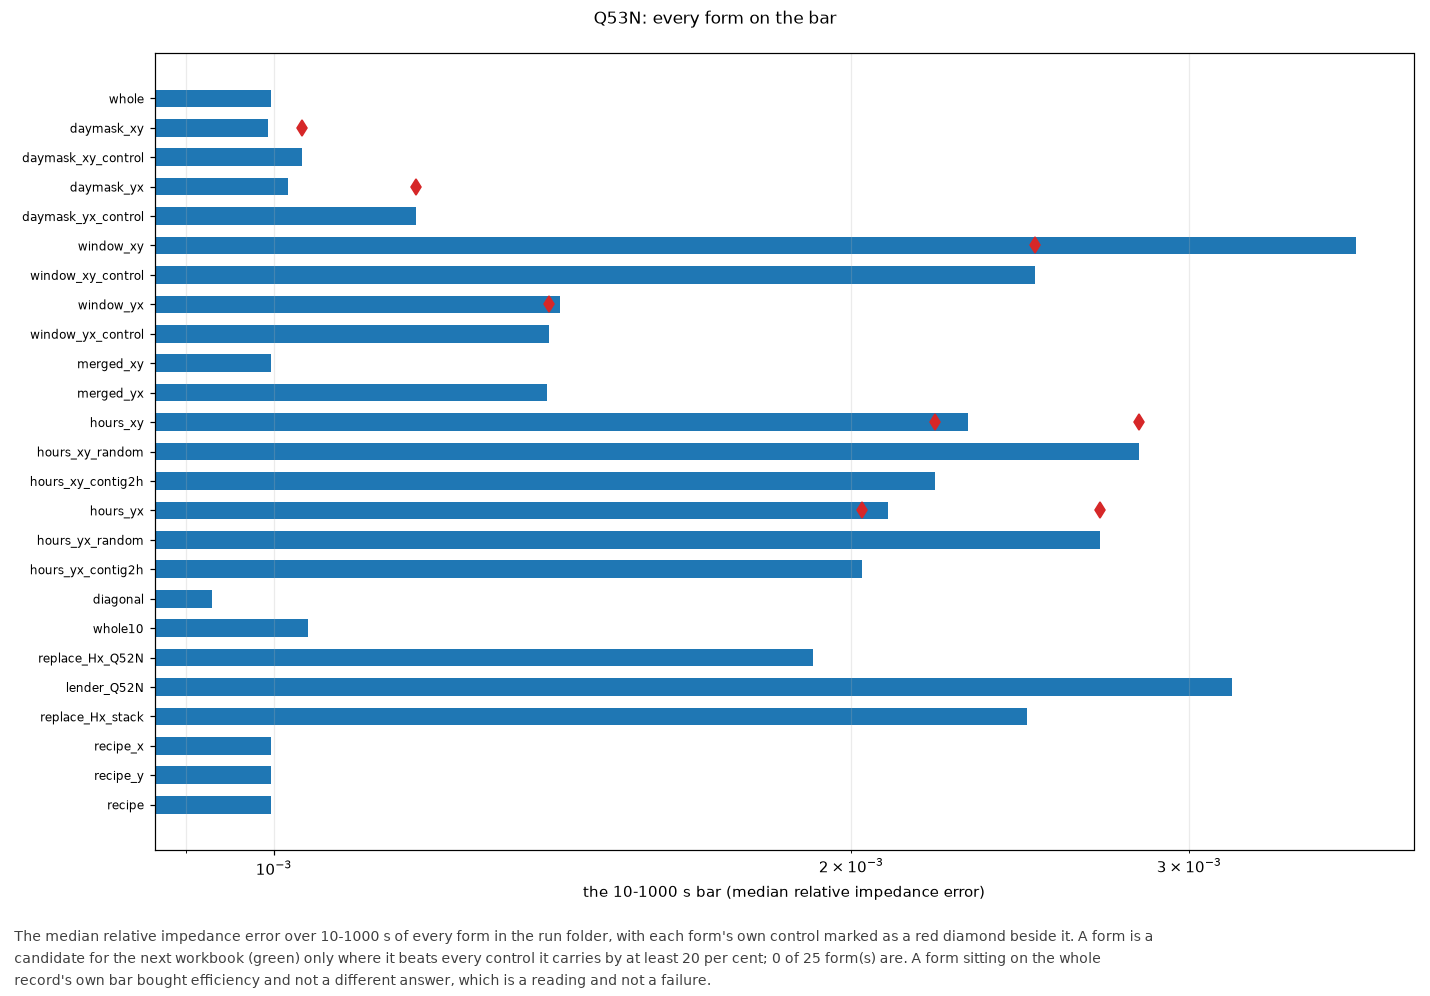

In [58]:
fig = FF.forms_bars(TABLE, SITE, OUT / "24_forms_bars.png", band=tuple(BAR_BAND), margin=BAR_MARGIN)
WRITTEN.append(OUT / "24_forms_bars.png")
display(Image(filename=str(OUT / "24_forms_bars.png")))


In [59]:
evidence = []
for c in COMPONENTS:
    bars = ";".join("%s %.4f" % (r.form, r.bar_10_1000) for r in TABLE.itertuples()
                    if str(r.form).startswith("window_%s" % c) and np.isfinite(r.bar_10_1000))
    evidence.append(dict(component=c, fraction=HOURS_FRACTION, record_days=round(n_rec / 86400.0, 2),
                         in_use=False,
                         evidence="control: an equal-length random block, seed %d; %g-%g s bar %s"
                                  % (WINDOWS[c]["seed"], BAR_BAND[0], BAR_BAND[1], bars or "not scored")))
WIN_TABLE = MK.windows_table(SITE, OUT.name, WINDOWS, evidence)
WIN_TABLE.to_csv(SITE_DIR / "windows.csv", index=False)
WRITTEN.append(SITE_DIR / "windows.csv")
print(WIN_TABLE.to_string(index=False))
print()
proposed = MK.write_windows(SV.blank_decisions([SITE]), SITE, WINDOWS)
flags = []
me = CENTRE.get(SITE, {})
if me.get("model_holds"):
    flags.append("shared centre: residual coherence %.2f, gain %.2f, s %+d; the remedy %s"
                 % (me["resid_coh"], me["resid_gain"], me["s_obs"],
                    "applies" if me["remedy_applicable"] else
                    "does NOT apply (the clean diagonal by H is the %s and the observed one is the %s)"
                    % (me["clean_by_H"], me["clean_obs"])))
if NEEDED:
    flags.append("magnetic replacement: %s from %s" % (CHAN, LEND))
proposed.loc[proposed.site == SITE, "flags"] = "; ".join(flags) or "decide"
print("the decisions.csv cells this workbook proposes for %s" % SITE)
print(proposed[["site", "windows", "flags"]].to_string(index=False))
if WRITE_DECISIONS:
    path = SV.SURVEYS / SURVEY / "decisions.csv"
    cur = sv.decisions.copy()
    for col in ("windows", "flags"):
        cur.loc[cur.site == SITE, col] = proposed[col].iloc[0]
    print(SV.write_table(path, cur, SV.DECISIONS_COLUMNS))
else:
    print("NOT written: WRITE_DECISIONS is False, and decisions are the analyst's")


site                run channel arm component    t_start      t_end  days  fraction  n_live_days  record_days  in_use                                                                                                                                                                                                                                                                                                                    rule
Q53N site_20260917_0400      Ex            xy 2025-10-23 2025-11-04  12.0      0.25           12        61.03   False the longest run of sound+weak days of Ex: 12 day(s), 2025-10-23 to 2025-11-04; no run of sound days reaches the 0.50 d floor, so the weak days are admitted and the window is a proposal, not a finding | control: an equal-length random block, seed 20260916; 10-1000 s bar window_xy 0.0037;window_xy_control 0.0025
Q53N site_20260917_0400      Ey            yx 2025-10-15 2025-11-17  33.0      0.25           33        61.03   False the longest run of sou

## 12. What was written

In [60]:
rows = []
for p in list(WRITTEN) + sorted(OUT.glob("*")):
    p = Path(p)
    if p.exists() and p.is_file():
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print("%d file(s), %.1f MB, in %.1f minutes" % (len(files), files.kb.sum() / 1024, (time.time() - T0) / 60))
print(files.to_string(index=False))
print()
cost = pd.DataFrame([dict(form=r.get("form"), rate_hz=r.get("rate_hz"), status=r.get("status"),
                          days=r.get("days"), runs=r.get("n_runs"), seconds=r.get("seconds"),
                          error=str(r.get("error") or "")[:60]) for r in FORM_ROWS])
print("the forms and what each cost")
print(cost.to_string(index=False))


66 file(s), 5.3 MB, in 2.2 minutes
                                                                                                                                file    kb
                            E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\site_20260917_0400\06_daily_magnetics.png  75.0
                                      E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\site_20260917_0400\07_fleet.png 126.6
                                      E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\site_20260917_0400\08_clock.png 101.1
                                E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\site_20260917_0400\09_quality_map.png 136.4
                                  E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\site_20260917_0400\10_day_masks.png 233.7
                           E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q53N\site_20260917_0400\11_daymask_products.pn